# QRT Data Challenge — Final Research and Production Notebook

This notebook predicts whether an allocation's future target return is positive. Each row represents one allocation at one timestamp; `binary_target = 1` denotes a positive future return. The challenge metric is classification accuracy.

The selected pipeline is a CatBoost binary classifier with purged validation and a nested-calibrated threshold of **0.492**. Its public leaderboard score is **0.5097**. A positive prediction is a directional forecast, not a complete trading strategy.


## 2. Imports, paths, seeds, and runtime configuration

### What we do
Define dependencies, file locations, reproducibility settings, and shared registries.

### How
All experiment results flow through one cache and one central log.

### Why
A deterministic and explicit runtime reduces accidental state differences.

### Link to the project objective
These settings support every stage used to forecast positive future returns.

> Heavy sections are disabled by default. Set an individual `RUN_*` flag to `True` only when that stage must be rerun.


In [1]:
from pathlib import Path
import copy
import itertools
import json
import random
import time
import warnings
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

try:
    import lightgbm as lgb
except ImportError:
    lgb = None

try:
    from xgboost import XGBRegressor, XGBClassifier
except ImportError:
    XGBRegressor = None
    XGBClassifier = None

try:
    from catboost import CatBoostRegressor, CatBoostClassifier
except ImportError:
    CatBoostRegressor = None
    CatBoostClassifier = None


PROJECT_DIR = Path("/Users/meddeb/Documents/qrt_challenge")
DATA_PATHS = {
    "x_train": PROJECT_DIR / "X_train_9xQjqvZ.csv",
    "y_train": PROJECT_DIR / "y_train_Ppwhaz8.csv",
    "x_test": PROJECT_DIR / "X_test_1zTtEnD.csv",
    "sample_submission": PROJECT_DIR / "sample_submission_SpGVFuH.csv",
}
RANDOM_STATE = 42
N_JOBS = -1
EPS = 1e-12


def set_seed(seed=RANDOM_STATE):
    """Seed Python and NumPy for reproducible tabular experiments."""
    random.seed(seed)
    np.random.seed(seed)


EXPERIMENT_LOG_COLUMNS = [
    "experiment_id", "date", "hypothesis", "feature_config", "feature_blocks",
    "encoding", "preprocessing", "model", "task", "score_kind",
    "validation_system", "n_features", "mean_accuracy", "std_accuracy",
    "worst_fold_accuracy", "global_oof_accuracy", "runtime_seconds",
    "decision_threshold", "status", "notes",
]
EXPERIMENT_RESULTS_CACHE = {}
EXPERIMENT_LOG = pd.DataFrame(columns=EXPERIMENT_LOG_COLUMNS)


def store_experiment_result(experiment_id, result, config):
    """Single write path for the result cache and experiment log, with upsert by experiment_id."""
    global EXPERIMENT_LOG
    if not experiment_id:
        raise ValueError("experiment_id cannot be empty")
    stored = dict(result)
    stored["experiment_id"] = experiment_id
    stored["experiment_config"] = copy.deepcopy(config)
    task = config.get("task") or stored.get("task")
    if task is None and "MODEL_CONFIGS" in globals():
        task = MODEL_CONFIGS.get(config.get("model"), {}).get("task")
    score_kind = stored.get("score_kind") or (
        "probability" if task == "classification" else "continuous"
    )
    stored["task"] = task
    stored["score_kind"] = score_kind
    EXPERIMENT_RESULTS_CACHE[experiment_id] = stored
    row = {
        "experiment_id": experiment_id,
        "date": datetime.now(timezone.utc).isoformat(timespec="seconds"),
        "hypothesis": config.get("hypothesis"),
        "feature_config": stored.get("feature_config", config.get("feature_config")),
        "feature_blocks": stored.get("feature_blocks", []),
        "encoding": stored.get("encoding_config", config.get("encoding_config")),
        "preprocessing": stored.get("preprocessing_config", config.get("preprocessing_config")),
        "model": config.get("model", stored.get("model_name")),
        "task": task,
        "score_kind": score_kind,
        "validation_system": config.get("validation_system"),
        "n_features": stored.get("n_features"),
        "mean_accuracy": stored.get("mean_accuracy"),
        "std_accuracy": stored.get("std_accuracy"),
        "worst_fold_accuracy": stored.get("worst_fold_accuracy"),
        "global_oof_accuracy": stored.get("global_accuracy"),
        "runtime_seconds": stored.get("runtime_seconds"),
        "decision_threshold": stored.get("decision_threshold", stored.get("threshold")),
        "status": stored.get("status", config.get("status", "completed")),
        "notes": config.get("notes", ""),
    }
    EXPERIMENT_LOG = EXPERIMENT_LOG.loc[
        ~EXPERIMENT_LOG["experiment_id"].eq(experiment_id)
    ].copy()
    EXPERIMENT_LOG = pd.concat(
        [EXPERIMENT_LOG, pd.DataFrame([row], columns=EXPERIMENT_LOG_COLUMNS)],
        ignore_index=True,
    )
    return stored


set_seed(RANDOM_STATE)
warnings.filterwarnings("once")


## 3. Data loading and schema validation

### What we do
Load train, target, test, and sample-submission files and validate their schemas.

### How
One-to-one `ROW_ID` checks precede the target merge and binary-target definition.

### Why
Explicit schema checks prevent silent row duplication or target misalignment.

### Link to the project objective
Correctly aligned rows are required before learning the sign of future returns.


In [2]:
X_train_raw = pd.read_csv(DATA_PATHS["x_train"])
y_train_raw = pd.read_csv(DATA_PATHS["y_train"])
X_test_raw = pd.read_csv(DATA_PATHS["x_test"])
sample_submission = pd.read_csv(DATA_PATHS["sample_submission"])

assert X_train_raw["ROW_ID"].is_unique
assert y_train_raw["ROW_ID"].is_unique
assert X_test_raw["ROW_ID"].is_unique
assert sample_submission["ROW_ID"].is_unique
assert set(X_train_raw["ROW_ID"]) == set(y_train_raw["ROW_ID"])
assert "target" not in X_train_raw.columns
assert "prediction" in sample_submission.columns
assert len(X_test_raw) == len(sample_submission)
assert set(X_train_raw.columns) == set(X_test_raw.columns)

train_raw = X_train_raw.merge(
    y_train_raw,
    on="ROW_ID",
    how="inner",
    validate="one_to_one",
)
assert len(train_raw) == len(X_train_raw)
train_raw["binary_target"] = (train_raw["target"] > 0).astype("int8")


## 4. Dataset exploration and target definition

### What we do
Summarize the panel structure, missingness, target balance, and category coverage.

### How
Compact tables describe timestamps, allocations, groups, and train/test compatibility.

### Why
The diagnostics identify data-quality and distribution risks before modeling.

### Link to the project objective
They clarify the population on which positive-return forecasts are learned.


,ROW_ID,TS,ALLOCATION,RET_20,RET_19,RET_18,RET_17,RET_16,RET_15,RET_14,...,SIGNED_VOLUME_6,SIGNED_VOLUME_5,SIGNED_VOLUME_4,SIGNED_VOLUME_3,SIGNED_VOLUME_2,SIGNED_VOLUME_1,MEDIAN_DAILY_TURNOVER,GROUP,target,binary_target
0,0,DATE_0001,ALLOCATION_01,-0.018192,-0.000306,-0.006881,-0.002393,0.000507,-0.001270,-0.002539,...,0.714129,-0.323847,0.525097,0.363601,-0.219328,NaN,0.096905,1,0.009210,1
1,1,DATE_0001,ALLOCATION_02,-0.006394,-0.001059,0.001565,0.000033,0.002829,0.001725,0.000875,...,-0.896826,-0.636931,-1.074450,-0.748884,-0.718912,NaN,0.009974,4,0.000405,1
2,2,DATE_0001,ALLOCATION_03,-0.016587,-0.004517,-0.005306,0.004314,0.006471,-0.005868,-0.005030,...,1.588321,0.790039,1.394445,0.493521,0.268094,NaN,0.044186,1,0.005967,1
3,3,DATE_0001,ALLOCATION_04,-0.005344,0.002790,0.006937,-0.004246,-0.005051,-0.000330,-0.000117,...,-0.631710,-0.663300,-1.615905,-0.959046,-0.478789,NaN,0.001150,2,-0.000542,0
4,4,DATE_0001,ALLOCATION_05,-0.010506,-0.005491,0.007752,-0.012299,0.002191,0.003282,0.000495,...,1.524626,1.565541,1.563963,1.063209,0.921333,NaN,NaN,4,-0.002579,0


,dtype
ROW_ID,int64
TS,object
ALLOCATION,object
RET_20,float64
RET_19,float64
RET_18,float64
RET_17,float64
RET_16,float64
RET_15,float64
RET_14,float64


,missing_count
SIGNED_VOLUME_1,387506
SIGNED_VOLUME_20,8498
MEDIAN_DAILY_TURNOVER,3638
SIGNED_VOLUME_19,3002
SIGNED_VOLUME_18,859
RET_20,58
SIGNED_VOLUME_17,58
RET_19,50
SIGNED_VOLUME_16,50
RET_18,42


TS            2522
ALLOCATION     278
GROUP            4
Name: n_unique, dtype: int64

count    2522.000000
mean      208.990087
std        81.903327
min        65.000000
25%       140.000000
50%       276.000000
75%       276.000000
max       276.000000
Name: rows_per_TS, dtype: float64

...

,ALLOCATION
0,ALLOCATION_01
1,ALLOCATION_02
2,ALLOCATION_03
3,ALLOCATION_04
4,ALLOCATION_05
...,...
273,ALLOCATION_95
274,ALLOCATION_96
275,ALLOCATION_97
276,ALLOCATION_98


,ALLOCATION


,GROUP


,GROUP
0,1
1,2
2,3
3,4


,GROUP


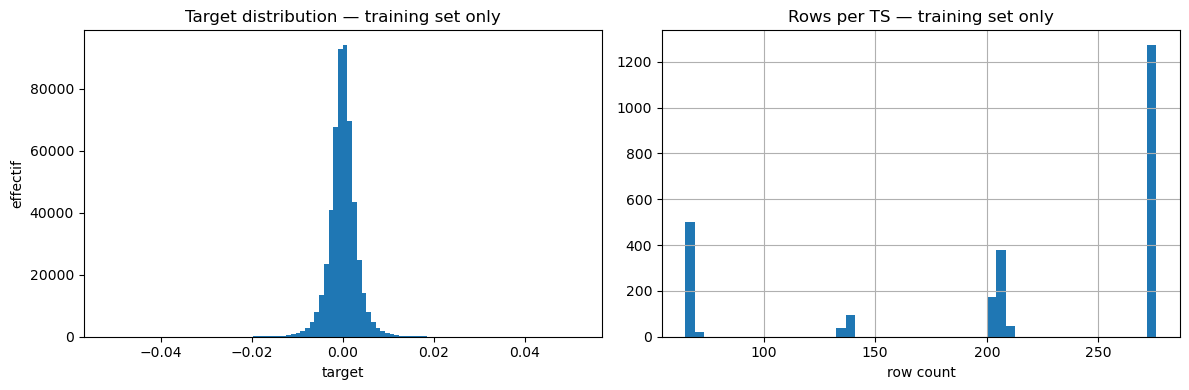

In [3]:
def basic_panel_audit(train_df, test_df=None):
    """Returns structural diagnostics and does not expect a target in the test set."""
    required = {"ROW_ID", "TS", "ALLOCATION", "GROUP"}
    missing = required.difference(train_df.columns)
    if missing:
        raise ValueError(f"Required training columns are missing: {sorted(missing)}")
    if test_df is not None:
        assert "target" not in test_df.columns
        assert "binary_target" not in test_df.columns

    summary = {
        "train_shape": train_df.shape,
        "train_duplicate_rows": int(train_df.duplicated().sum()),
        "train_unique_ts": int(train_df["TS"].nunique(dropna=False)),
        "train_unique_allocations": int(train_df["ALLOCATION"].nunique(dropna=False)),
        "train_unique_groups": int(train_df["GROUP"].nunique(dropna=False)),
    }
    if test_df is not None:
        summary.update({
            "test_shape": test_df.shape,
            "test_duplicate_rows": int(test_df.duplicated().sum()),
            "test_unique_ts": int(test_df["TS"].nunique(dropna=False)),
            "test_unique_allocations": int(test_df["ALLOCATION"].nunique(dropna=False)),
            "test_unique_groups": int(test_df["GROUP"].nunique(dropna=False)),
            "same_explanatory_columns": set(train_df.columns).difference(
                {"target", "binary_target"}
            ) == set(test_df.columns),
        })
    return pd.Series(summary, name="value").to_frame()


def category_compatibility(train_df, test_df, column):
    """Compares train and test category sets only."""
    train_values = set(train_df[column].dropna().unique())
    test_values = set(test_df[column].dropna().unique())
    return {
        "train_only": pd.DataFrame({column: sorted(train_values - test_values, key=str)}),
        "common": pd.DataFrame({column: sorted(train_values & test_values, key=str)}),
        "test_only": pd.DataFrame({column: sorted(test_values - train_values, key=str)}),
    }


panel_audit = basic_panel_audit(train_raw, X_test_raw)
panel_audit


display(train_raw.head())
display(train_raw.dtypes.rename("dtype").to_frame())
display(
    train_raw.isna().sum().sort_values(ascending=False).rename("missing_count").to_frame()
)
display(train_raw[["TS", "ALLOCATION", "GROUP"]].nunique(dropna=False).rename("n_unique"))
display(train_raw.groupby("TS", dropna=False).size().describe().rename("rows_per_TS"))
display(
    train_raw.groupby("ALLOCATION", dropna=False).size().describe().rename("rows_per_allocation")
)
display(train_raw.groupby("GROUP", dropna=False).size().rename("rows_per_group").to_frame())
display(train_raw["binary_target"].value_counts(normalize=True).sort_index().rename("proportion"))
display(train_raw["target"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_raw["target"].dropna(), bins=100)
axes[0].set_title("Target distribution — training set only")
axes[0].set_xlabel("target")
axes[0].set_ylabel("effectif")
train_raw.groupby("TS", dropna=False).size().hist(bins=50, ax=axes[1])
axes[1].set_title("Rows per TS — training set only")
axes[1].set_xlabel("row count")
plt.tight_layout()


allocation_compatibility = category_compatibility(train_raw, X_test_raw, "ALLOCATION")
group_compatibility = category_compatibility(train_raw, X_test_raw, "GROUP")

allocations_train_only = allocation_compatibility["train_only"]
allocations_common = allocation_compatibility["common"]
allocations_test_only = allocation_compatibility["test_only"]
groups_train_only = group_compatibility["train_only"]
groups_common = group_compatibility["common"]
groups_test_only = group_compatibility["test_only"]

compatibility_counts = pd.DataFrame({
    "train_only": [len(allocations_train_only), len(groups_train_only)],
    "common": [len(allocations_common), len(groups_common)],
    "test_only": [len(allocations_test_only), len(groups_test_only)],
}, index=["ALLOCATION", "GROUP"])
display(compatibility_counts)
display(allocations_train_only, allocations_common, allocations_test_only)
display(groups_train_only, groups_common, groups_test_only)


## 5. Validation strategies

### What we do
Define benchmark, temporal, embargoed, and purged timestamp-level splits.

### How
Folds are built on complete timestamps and checked for row and timestamp leakage.

### Why
Financial panels require separation between nearby training and validation periods.

### Link to the project objective
Reliable folds make accuracy estimates more relevant to future-return classification.


In [4]:
RET_COLUMNS = [f"RET_{i}" for i in range(1, 21)]
VOLUME_COLUMNS = [f"SIGNED_VOLUME_{i}" for i in range(1, 21)]

assert set(RET_COLUMNS).issubset(train_raw.columns)
assert set(VOLUME_COLUMNS).issubset(train_raw.columns)


def ordered_ts_values(values):
    """Orders timestamps by numeric suffix and then lexicographically."""
    series = pd.Series(pd.unique(values)).dropna()
    frame = pd.DataFrame({"TS": series.astype(str)})
    frame["numeric_suffix"] = pd.to_numeric(
        frame["TS"].str.extract(r"(\d+)$", expand=False), errors="coerce"
    )
    frame["has_numeric_suffix"] = frame["numeric_suffix"].notna().astype(int)
    frame = frame.sort_values(
        ["has_numeric_suffix", "numeric_suffix", "TS"],
        ascending=[False, True, True],
        kind="stable",
    )
    return frame["TS"].to_numpy()


def estimate_sequence_overlap(df, allocation_col="ALLOCATION", ts_col="TS"):
    """Describes overlap between adjacent snapshots without assuming a confirmed chronology."""
    assert "target" not in df.columns or df is train_raw
    required = {allocation_col, ts_col, *RET_COLUMNS}
    if missing := required.difference(df.columns):
        raise ValueError(f"Missing columns: {sorted(missing)}")

    ts_order = {ts: rank for rank, ts in enumerate(ordered_ts_values(df[ts_col]))}
    work = df[[allocation_col, ts_col, *RET_COLUMNS]].copy()
    work["_ts_rank"] = work[ts_col].astype(str).map(ts_order)
    rows = []
    for allocation, group in work.groupby(allocation_col, dropna=False, sort=False):
        group = group.sort_values("_ts_rank")
        if len(group) < 2:
            continue
        previous = group.iloc[:-1]
        following = group.iloc[1:]
        left = previous[[f"RET_{i}" for i in range(1, 20)]].to_numpy(float)
        right = following[[f"RET_{i}" for i in range(2, 21)]].to_numpy(float)
        valid = np.isfinite(left) & np.isfinite(right)
        pair_counts = valid.sum(axis=1)
        absolute_errors = np.where(valid, np.abs(left - right), np.nan)
        close_fraction = np.where(valid, np.isclose(left, right, rtol=1e-5, atol=1e-8), np.nan)
        for row_idx in range(len(previous)):
            if pair_counts[row_idx] == 0:
                continue
            rows.append({
                "allocation": allocation,
                "mean_absolute_overlap_error": float(np.nanmean(absolute_errors[row_idx])),
                "exactish_overlap_fraction": float(np.nanmean(close_fraction[row_idx])),
                "compared_lags": int(pair_counts[row_idx]),
            })
    details = pd.DataFrame(rows)
    if details.empty:
        return {"details": details, "summary": pd.DataFrame()}
    return {
        "details": details,
        "summary": details[["mean_absolute_overlap_error", "exactish_overlap_fraction", "compared_lags"]].describe(),
    }


def _row_indices_for_ts(df, ts_values):
    return np.flatnonzero(df["TS"].astype(str).isin(set(map(str, ts_values))).to_numpy())


def make_benchmark_ts_folds(df, n_splits=5, random_state=42):
    """Builds shuffled K-fold splits over unique timestamps and maps them back to rows."""
    unique_ts = pd.unique(df["TS"].astype(str))
    splitter = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    folds = []
    for fold_id, (train_pos, valid_pos) in enumerate(splitter.split(unique_ts)):
        train_ts = unique_ts[train_pos]
        valid_ts = unique_ts[valid_pos]
        folds.append({
            "fold": fold_id,
            "train_idx": _row_indices_for_ts(df, train_ts),
            "valid_idx": _row_indices_for_ts(df, valid_ts),
            "train_ts": train_ts,
            "valid_ts": valid_ts,
            "embargo_ts_values": np.array([], dtype=object),
            "is_temporal": False,
        })
    return folds


def make_expanding_ts_folds(
    df,
    n_splits=4,
    min_train_fraction=0.5,
    validation_fraction=0.1,
):
    """Builds past-training and future-validation windows at timestamp level."""
    ordered_ts = ordered_ts_values(df["TS"])
    n_ts = len(ordered_ts)
    min_train = max(1, int(np.ceil(n_ts * min_train_fraction)))
    valid_size = max(1, int(np.floor(n_ts * validation_fraction)))
    latest_start = n_ts - valid_size
    if min_train >= latest_start:
        raise ValueError("Not enough timestamps for the requested fractions")
    starts = np.unique(np.linspace(min_train, latest_start, n_splits, dtype=int))
    if len(starts) != n_splits:
        raise ValueError("n_splits is too large for the number of timestamps")
    folds = []
    for fold_id, valid_start in enumerate(starts):
        train_ts = ordered_ts[:valid_start]
        valid_ts = ordered_ts[valid_start:min(valid_start + valid_size, n_ts)]
        folds.append({
            "fold": fold_id,
            "train_idx": _row_indices_for_ts(df, train_ts),
            "valid_idx": _row_indices_for_ts(df, valid_ts),
            "train_ts": train_ts,
            "valid_ts": valid_ts,
            "embargo_ts_values": np.array([], dtype=object),
            "is_temporal": True,
        })
    return folds


def make_purged_expanding_ts_folds(
    df,
    n_splits=4,
    min_train_fraction=0.5,
    validation_fraction=0.1,
    embargo_ts=20,
):
    """Adds a timestamp embargo between past training and future validation."""
    if embargo_ts < 0:
        raise ValueError("embargo_ts must be positive")
    ordered_ts = ordered_ts_values(df["TS"])
    n_ts = len(ordered_ts)
    min_train = max(1, int(np.ceil(n_ts * min_train_fraction)))
    valid_size = max(1, int(np.floor(n_ts * validation_fraction)))
    first_valid_start = min_train + embargo_ts
    latest_start = n_ts - valid_size
    if first_valid_start > latest_start:
        raise ValueError("Not enough timestamps for this embargo")
    starts = np.unique(np.linspace(first_valid_start, latest_start, n_splits, dtype=int))
    if len(starts) != n_splits:
        raise ValueError("n_splits is too large for the number of timestamps")
    folds = []
    for fold_id, valid_start in enumerate(starts):
        train_end = valid_start - embargo_ts
        train_ts = ordered_ts[:train_end]
        embargo_values = ordered_ts[train_end:valid_start]
        valid_ts = ordered_ts[valid_start:min(valid_start + valid_size, n_ts)]
        folds.append({
            "fold": fold_id,
            "train_idx": _row_indices_for_ts(df, train_ts),
            "valid_idx": _row_indices_for_ts(df, valid_ts),
            "train_ts": train_ts,
            "valid_ts": valid_ts,
            "embargo_ts_values": embargo_values,
            "is_temporal": True,
        })
    return folds


def validate_fold_integrity(df, folds):
    """
    Checks index validity and uniqueness, train/validation separation, complete timestamp assignment, requested temporal order, and embargo separation.
    """
    n_rows = len(df)

    ts_series = df["TS"].astype(str)
    ordered = ordered_ts_values(ts_series)
    rank = {str(ts): idx for idx, ts in enumerate(ordered)}

    # Computed once instead of rescanning the DataFrame for each timestamp
    total_counts_by_ts = ts_series.value_counts()

    reports = []

    for fold_id, fold in enumerate(folds):
        train_idx = np.asarray(fold["train_idx"], dtype=int)
        valid_idx = np.asarray(fold["valid_idx"], dtype=int)

        assert train_idx.ndim == 1
        assert valid_idx.ndim == 1

        assert len(np.unique(train_idx)) == len(train_idx)
        assert len(np.unique(valid_idx)) == len(valid_idx)

        assert np.intersect1d(
            train_idx,
            valid_idx,
            assume_unique=True,
        ).size == 0

        assert ((train_idx >= 0) & (train_idx < n_rows)).all()
        assert ((valid_idx >= 0) & (valid_idx < n_rows)).all()

        train_ts_series = ts_series.iloc[train_idx]
        valid_ts_series = ts_series.iloc[valid_idx]

        train_ts = set(train_ts_series.unique())
        valid_ts = set(valid_ts_series.unique())

        assert train_ts.isdisjoint(valid_ts)

        # Checks in one operation that every selected timestamp is complete
        train_fold_counts = train_ts_series.value_counts()
        valid_fold_counts = valid_ts_series.value_counts()

        expected_train_counts = total_counts_by_ts.loc[
            train_fold_counts.index
        ]
        expected_valid_counts = total_counts_by_ts.loc[
            valid_fold_counts.index
        ]

        assert train_fold_counts.equals(expected_train_counts)
        assert valid_fold_counts.equals(expected_valid_counts)

        embargo_values = set(
            map(str, fold.get("embargo_ts_values", []))
        )

        if fold.get("is_temporal", False):
            assert train_ts
            assert valid_ts

            assert max(rank[ts] for ts in train_ts) < min(
                rank[ts] for ts in valid_ts
            )

            assert train_ts.isdisjoint(embargo_values)
            assert valid_ts.isdisjoint(embargo_values)

        reports.append({
            "fold": fold_id,
            "n_train_rows": len(train_idx),
            "n_valid_rows": len(valid_idx),
            "n_train_ts": len(train_ts),
            "n_valid_ts": len(valid_ts),
            "n_embargo_ts": len(embargo_values),
            "integrity": True,
        })

    return pd.DataFrame(reports)


benchmark_kfold_5 = make_benchmark_ts_folds(
    train_raw, n_splits=5, random_state=42
)
official_benchmark_kfold_8 = make_benchmark_ts_folds(
    train_raw, n_splits=8, random_state=0
)
expanding_folds = make_expanding_ts_folds(train_raw)
purged_folds = make_purged_expanding_ts_folds(train_raw)

VALIDATION_SYSTEMS = {
    "benchmark_kfold_5": benchmark_kfold_5,
    "official_benchmark_kfold_8": official_benchmark_kfold_8,
    "expanding": expanding_folds,
    "purged": purged_folds,
}

validation_integrity = pd.concat(
    [
        validate_fold_integrity(train_raw, folds).assign(validation_system=name)
        for name, folds in VALIDATION_SYSTEMS.items()
    ],
    ignore_index=True,
)
display(validation_integrity)


,fold,n_train_rows,n_valid_rows,n_train_ts,n_valid_ts,n_embargo_ts,integrity,validation_system
0,0,423749,103324,2017,505,0,True,benchmark_kfold_5
1,1,420785,106288,2017,505,0,True,benchmark_kfold_5
2,2,417833,109240,2018,504,0,True,benchmark_kfold_5
3,3,423934,103139,2018,504,0,True,benchmark_kfold_5
4,4,421991,105082,2018,504,0,True,benchmark_kfold_5
5,0,461075,65998,2206,316,0,True,official_benchmark_kfold_8
6,1,460724,66349,2206,316,0,True,official_benchmark_kfold_8
7,2,462101,64972,2207,315,0,True,official_benchmark_kfold_8
8,3,462508,64565,2207,315,0,True,official_benchmark_kfold_8
9,4,459660,67413,2207,315,0,True,official_benchmark_kfold_8


## 6. Naive baselines

### What we do
Evaluate majority, momentum, and contrarian rules on the validation folds.

### How
Each rule is scored only on held-out rows with the same accuracy metric as the challenge.

### Why
Simple references show whether learned models add value beyond recent returns.

### Link to the project objective
They establish a minimum standard for positive-return predictions.


In [5]:
def accuracy_from_signal(signal, y_true, threshold=0.0):
    """Converts a continuous signal into a class and computes accuracy."""
    signal_array = np.asarray(signal, dtype=float)
    truth = np.asarray(y_true, dtype=int)
    if len(signal_array) != len(truth):
        raise ValueError("signal and y_true must have the same length")
    return accuracy_score(truth, (signal_array > threshold).astype("int8"))

def evaluate_naive_baselines(df, folds):
    """Evaluates baselines on validation rows only."""
    records = []
    for fold_id, fold in enumerate(folds):
        train_idx = np.asarray(fold["train_idx"], dtype=int)
        valid_idx = np.asarray(fold["valid_idx"], dtype=int)
        y_train_fold = df.iloc[train_idx]["binary_target"].to_numpy()
        y_valid = df.iloc[valid_idx]["binary_target"].to_numpy()
        valid = df.iloc[valid_idx]
        majority = int(np.mean(y_train_fold) >= 0.5)
        signals = {"majority": np.full(len(valid), 1.0 if majority else -1.0)}
        signals["RET_1"] = valid["RET_1"].to_numpy()
        for horizon in (3, 5, 10, 20):
            base = valid[[f"RET_{i}" for i in range(1, horizon + 1)]].mean(axis=1).to_numpy()
            signals[f"mean_RET_{horizon}"] = base
            signals[f"contrarian_mean_RET_{horizon}"] = -base
        signals["contrarian_RET_1"] = -signals["RET_1"]
        for name, signal in signals.items():
            records.append({
                "fold": fold_id,
                "baseline": name,
                "accuracy": accuracy_from_signal(signal, y_valid),
                "n_valid": len(valid_idx),
            })
    return pd.DataFrame(records)


BASELINE_RESULTS = evaluate_naive_baselines(train_raw, benchmark_kfold_5)
baseline_summary = (
    BASELINE_RESULTS.groupby("baseline", as_index=False)
    .agg(
        mean_accuracy=("accuracy", "mean"),
        std_accuracy=("accuracy", "std"),
        worst_fold_accuracy=("accuracy", "min"),
        best_fold_accuracy=("accuracy", "max"),
        total_valid_observations=("n_valid", "sum"),
    )
    .sort_values("mean_accuracy", ascending=False)
)
display(BASELINE_RESULTS)
display(baseline_summary)


,fold,baseline,accuracy,n_valid
0,0,majority,0.506426,103324
1,0,RET_1,0.521573,103324
2,0,mean_RET_3,0.510453,103324
3,0,contrarian_mean_RET_3,0.489547,103324
4,0,mean_RET_5,0.506552,103324
5,0,contrarian_mean_RET_5,0.493448,103324
6,0,mean_RET_10,0.512059,103324
7,0,contrarian_mean_RET_10,0.487941,103324
8,0,mean_RET_20,0.508023,103324
9,0,contrarian_mean_RET_20,0.491977,103324


,baseline,mean_accuracy,std_accuracy,worst_fold_accuracy,best_fold_accuracy,total_valid_observations
0,RET_1,0.518949,0.003016,0.516157,0.522763,527073
7,mean_RET_10,0.509681,0.003195,0.506573,0.513670,527073
9,mean_RET_3,0.509388,0.001598,0.507570,0.510904,527073
8,mean_RET_20,0.508300,0.004783,0.501575,0.514645,527073
6,majority,0.507214,0.006185,0.499953,0.516371,527073
10,mean_RET_5,0.505581,0.003216,0.502031,0.510528,527073
5,contrarian_mean_RET_5,0.494419,0.003216,0.489472,0.497969,527073
3,contrarian_mean_RET_20,0.491700,0.004783,0.485355,0.498425,527073
4,contrarian_mean_RET_3,0.490612,0.001598,0.489096,0.492430,527073
2,contrarian_mean_RET_10,0.490319,0.003195,0.486330,0.493427,527073


## 7. Official benchmark reproduction

### What we do
Reproduce the official LightGBM and Ridge benchmark pipelines.

### How
The implementation keeps their original features, folds, parameters, and OOF outputs.

### Why
A faithful benchmark anchors all later comparisons.

### Link to the project objective
It measures the baseline ability to classify the sign of future returns.


In [6]:
def build_benchmark_features(df):
    """Reproduces the benchmark predictors exactly, without targets."""
    forbidden = {"target", "binary_target"}.intersection(df.columns)
    if forbidden:
        raise ValueError(f"Retirer the targets before feature engineering: {sorted(forbidden)}")
    required = {*RET_COLUMNS, *VOLUME_COLUMNS, "MEDIAN_DAILY_TURNOVER", "TS"}
    if missing := required.difference(df.columns):
        raise ValueError(f"Missing columns: {sorted(missing)}")
    work = df.copy()
    for horizon in (3, 5, 10, 15, 20):
        ret_cols = RET_COLUMNS[:horizon]
        average_col = f"AVERAGE_PERF_{horizon}"
        cross_col = f"ALLOCATIONS_AVERAGE_PERF_{horizon}"
        work[average_col] = work[ret_cols].mean(axis=1)
        work[cross_col] = work.groupby("TS", dropna=False)[average_col].transform("mean")
    work["STD_PERF_20"] = work[RET_COLUMNS].std(axis=1)
    work["ALLOCATIONS_STD_PERF_20"] = work.groupby("TS", dropna=False)["STD_PERF_20"].transform("mean")
    feature_cols = (
        RET_COLUMNS
        + VOLUME_COLUMNS
        + ["MEDIAN_DAILY_TURNOVER"]
        + [f"AVERAGE_PERF_{h}" for h in (3, 5, 10, 15, 20)]
        + [f"ALLOCATIONS_AVERAGE_PERF_{h}" for h in (3, 5, 10, 15, 20)]
        + ["STD_PERF_20", "ALLOCATIONS_STD_PERF_20"]
    )
    result = work[feature_cols].replace([np.inf, -np.inf], np.nan)
    return result


def run_lightgbm_regression_cv(X, y_continuous, folds, params=None, num_boost_round=500):
    """Runs benchmark cross-validation and retains OOF predictions and importances."""
    if lgb is None:
        raise ImportError("LightGBM is not installed")
    default_params = {
        "objective": "mse",
        "metric": "mse",
        "num_threads": 50,
        "seed": RANDOM_STATE,
        "verbosity": -1,
        "learning_rate": 1e-2,
        "max_depth": 3,
    }
    model_params = {**default_params, **(params or {})}
    y = np.asarray(y_continuous, dtype=float).reshape(-1)
    oof_continuous = np.full(len(X), np.nan, dtype=float)
    fold_ids = np.full(len(X), -1, dtype=int)
    scores, models, importances = [], [], []
    for fold_id, fold in enumerate(folds):
        train_idx = np.asarray(fold["train_idx"], dtype=int)
        valid_idx = np.asarray(fold["valid_idx"], dtype=int)
        train_data = lgb.Dataset(X.iloc[train_idx], label=y[train_idx])
        model = lgb.train(model_params, train_data, num_boost_round=num_boost_round)
        prediction = model.predict(X.iloc[valid_idx])
        oof_continuous[valid_idx] = prediction
        fold_ids[valid_idx] = fold_id
        score = accuracy_score((y[valid_idx] > 0).astype(int), (prediction > 0).astype(int))
        scores.append(score)
        models.append(model)
        importances.append(pd.Series(
            model.feature_importance(importance_type="gain"), index=X.columns, name=fold_id
        ))
    covered = np.isfinite(oof_continuous)
    return {
        "model_name": "lightgbm_regression_benchmark",
        "oof_continuous": oof_continuous,
        "oof_binary": np.where(covered, (oof_continuous > 0).astype(int), -1),
        "fold_ids": fold_ids,
        "fold_scores": scores,
        "mean_accuracy": float(np.mean(scores)),
        "std_accuracy": float(np.std(scores)),
        "worst_fold_accuracy": float(np.min(scores)),
        "global_accuracy": accuracy_score((y[covered] > 0).astype(int), (oof_continuous[covered] > 0).astype(int)),
        "fitted_models": models,
        "feature_importances": pd.DataFrame(importances),
        "params": model_params,
    }


def run_ridge_regression_cv(X, y_continuous, folds, alpha=1.0):
    """Reproduces benchmark Ridge in timestamp folds with NaN filled by zero and no scaling."""
    y = np.asarray(y_continuous, dtype=float).reshape(-1)
    oof_continuous = np.full(len(X), np.nan, dtype=float)
    fold_ids = np.full(len(X), -1, dtype=int)
    scores, models, importances = [], [], []
    for fold_id, fold in enumerate(folds):
        train_idx = np.asarray(fold["train_idx"], dtype=int)
        valid_idx = np.asarray(fold["valid_idx"], dtype=int)
        model = Ridge(alpha=alpha)
        train_values = X.iloc[train_idx].fillna(0.0).to_numpy()
        valid_values = X.iloc[valid_idx].fillna(0.0).to_numpy()
        model.fit(train_values, y[train_idx])
        prediction = model.predict(valid_values)
        oof_continuous[valid_idx] = prediction
        fold_ids[valid_idx] = fold_id
        scores.append(accuracy_score((y[valid_idx] > 0).astype(int), (prediction > 0).astype(int)))
        models.append(model)
        importances.append(pd.Series(model.coef_, index=X.columns, name=fold_id))
    covered = np.isfinite(oof_continuous)
    return {
        "model_name": "ridge_regression_benchmark",
        "oof_continuous": oof_continuous,
        "oof_binary": np.where(covered, (oof_continuous > 0).astype(int), -1),
        "fold_ids": fold_ids,
        "fold_scores": scores,
        "mean_accuracy": float(np.mean(scores)),
        "std_accuracy": float(np.std(scores)),
        "worst_fold_accuracy": float(np.min(scores)),
        "global_accuracy": accuracy_score((y[covered] > 0).astype(int), (oof_continuous[covered] > 0).astype(int)),
        "fitted_models": models,
        "feature_importances": pd.DataFrame(importances),
        "params": {"alpha": alpha},
    }


RUN_OFFICIAL_BENCHMARK = True

if RUN_OFFICIAL_BENCHMARK:
    official_benchmark_features = build_benchmark_features(
        train_raw.drop(columns=["target", "binary_target"])
    )
    official_lgb_result = run_lightgbm_regression_cv(
        official_benchmark_features,
        train_raw["target"],
        official_benchmark_kfold_8,
        params={"seed": 42},
        num_boost_round=500,
    )
    official_ridge_result = run_ridge_regression_cv(
        official_benchmark_features,
        train_raw["target"],
        official_benchmark_kfold_8,
        alpha=1.0,
    )
    store_experiment_result(
        "OFFICIAL_LGB_8",
        official_lgb_result,
        {
            "hypothesis": "Exact reproduction of the official LightGBM benchmark",
            "feature_config": "benchmark_only",
            "encoding_config": "none",
            "preprocessing_config": "official_native",
            "model": "lightgbm_regression_benchmark",
            "task": "regression",
            "validation_system": "official_benchmark_kfold_8",
            "notes": "8 folds TS, random_state=0, seed=42, 500 boosting rounds",
        },
    )
    store_experiment_result(
        "OFFICIAL_RIDGE_8",
        official_ridge_result,
        {
            "hypothesis": "Official benchmark Ridge control",
            "feature_config": "benchmark_only",
            "encoding_config": "none",
            "preprocessing_config": "official_nan_to_zero",
            "model": "ridge_regression_benchmark",
            "task": "regression",
            "validation_system": "official_benchmark_kfold_8",
            "notes": "Ridge alpha=1.0, NaN filled with zero, no scaling",
        },
    )
else:
    print("Official benchmark skipped. Set RUN_OFFICIAL_BENCHMARK=True to run it.")


/var/folders/6d/qpp__vm90_924t2g2m176mg80000gn/T/ipykernel_36140/3821361996.py:110: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  EXPERIMENT_LOG = pd.concat(


## 8. Benchmark diagnostics

### What we do
Analyze where the official benchmark agrees with or corrects simple momentum.

### How
OOF errors are grouped by allocation, time, turnover, volume, and return regimes.

### Why
Diagnostics motivate feature hypotheses without using test labels.

### Link to the project objective
They identify contexts that may improve positive-return classification.


,Model,Mean Accuracy,Best Fold,Worst Fold,Std,Global OOF Accuracy
0,Majority,50.7194%,51.5314%,50.0031%,0.4269%,50.7184%
1,RET_1 baseline,51.8924%,52.2678%,51.4452%,0.2766%,51.8924%
2,Ridge,51.9682%,52.4743%,51.3978%,0.3469%,51.9660%
3,LightGBM,52.2194%,52.4815%,51.9531%,0.2012%,52.2195%


,RET1 correct ?,LightGBM correct ?,Agreement case
0,True,True,Both correct
1,True,True,Both correct
2,False,False,Both incorrect
3,False,False,Both incorrect
4,False,False,Both incorrect
5,False,True,RET1 faux mais LightGBM correct
6,True,True,Both correct
7,False,True,RET1 faux mais LightGBM correct
8,True,False,RET1 correct mais LightGBM faux
9,True,False,RET1 correct mais LightGBM faux


,Case,Count,Proportion
0,Both correct,"228,267",43.308%
1,Both incorrect,"206,594",39.196%
2,RET1 faux mais LightGBM correct,"46,968",8.911%
3,RET1 correct mais LightGBM faux,"45,244",8.584%


,ROW_ID,TS,ALLOCATION,GROUP,target,binary_target,RET_1,SIGNED_VOLUME_1,MEDIAN_DAILY_TURNOVER,ALLOCATIONS_AVERAGE_PERF_3,...,ALLOCATIONS_AVERAGE_PERF_10,ALLOCATIONS_AVERAGE_PERF_20,STD_PERF_20,prediction LightGBM,prediction Ridge,LightGBM class,Ridge class,RET1 class,RET1 correct,LightGBM correct
0,0,DATE_0001,ALLOCATION_01,1,0.009210,1,0.003944,NaN,0.096905,-0.000396,...,-0.000484,-0.000393,0.005911,0.000102,0.000185,1,1,1,True,True
1,1,DATE_0001,ALLOCATION_02,4,0.000405,1,0.002323,NaN,0.009974,-0.000396,...,-0.000484,-0.000393,0.002591,0.000112,0.000346,1,1,1,True,True
2,2,DATE_0001,ALLOCATION_03,1,0.005967,1,-0.000238,NaN,0.044186,-0.000396,...,-0.000484,-0.000393,0.005840,-0.000107,-0.000055,0,0,0,False,False
3,3,DATE_0001,ALLOCATION_04,2,-0.000542,0,0.001863,NaN,0.001150,-0.000396,...,-0.000484,-0.000393,0.004174,0.000052,0.000363,1,1,1,False,False
4,4,DATE_0001,ALLOCATION_05,4,-0.002579,0,0.001219,NaN,NaN,-0.000396,...,-0.000484,-0.000393,0.005615,0.000105,0.000397,1,1,1,False,False


,Subset,Count,Percentage
0,RET1 faux,"253,562",48.108%
1,LightGBM faux,"251,838",47.780%
2,RET1 faux MAIS LightGBM correct,"46,968",8.911%
3,RET1 correct MAIS LightGBM faux,"45,244",8.584%


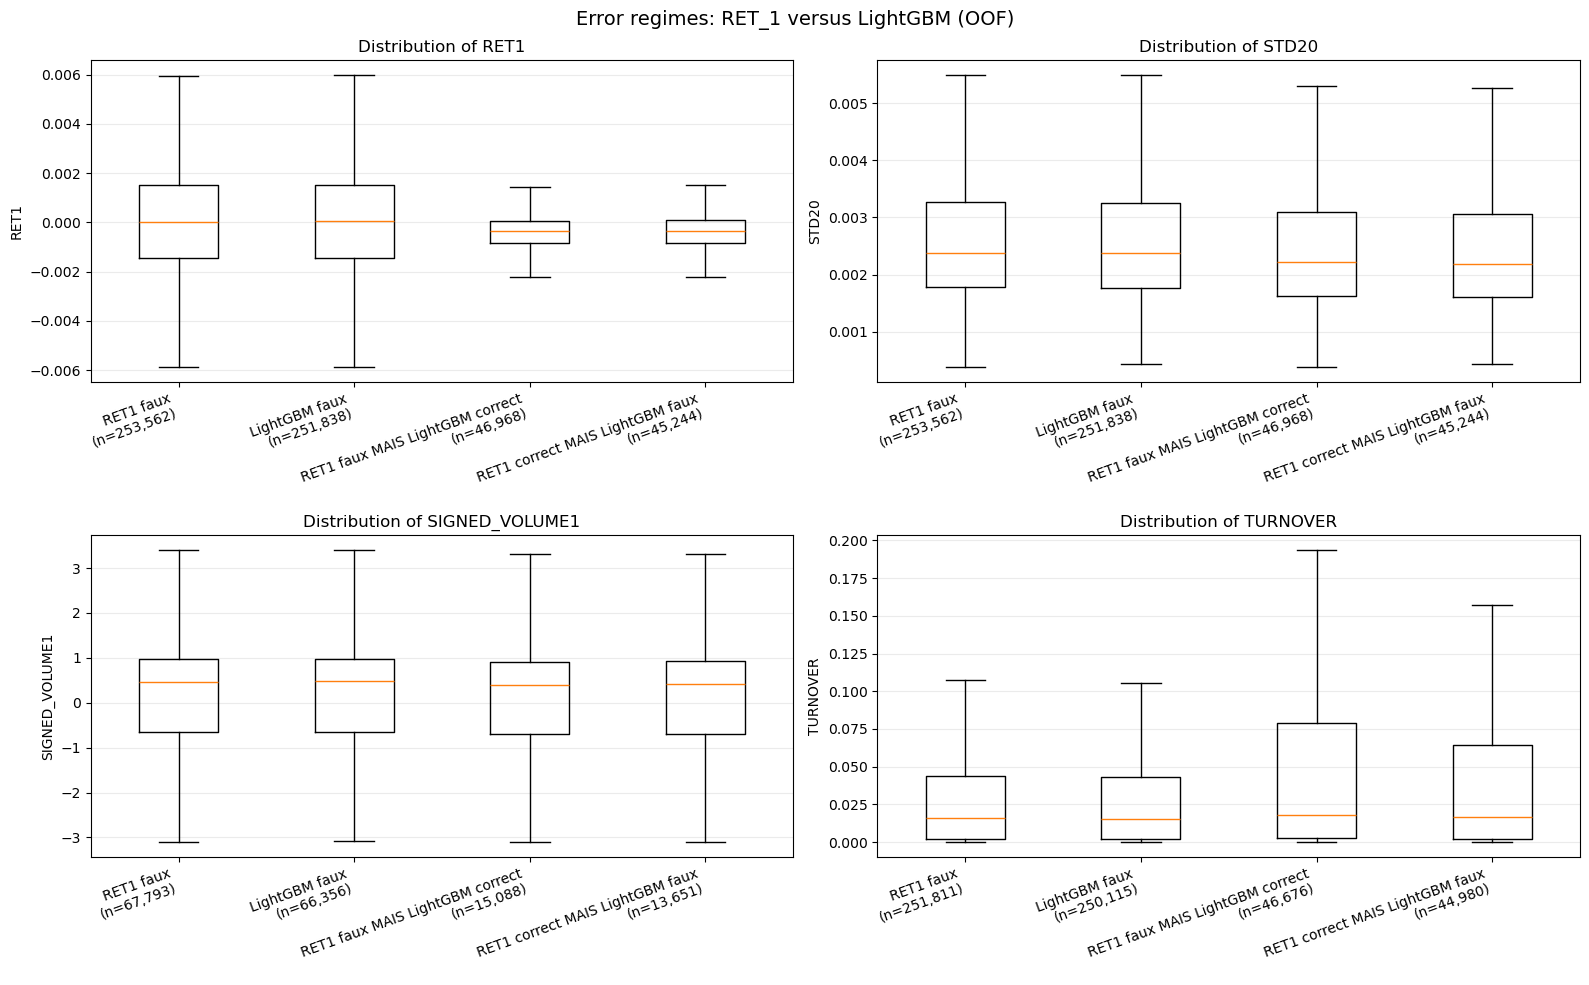

,ALLOCATION,n_observations,accuracy
0,ALLOCATION_14,19,63.158%
1,ALLOCATION_46,19,63.158%
2,ALLOCATION_152,2439,61.173%
3,ALLOCATION_31,1864,58.637%
4,ALLOCATION_168,1931,57.742%
5,ALLOCATION_187,1931,57.535%
6,ALLOCATION_22,1864,56.867%
7,ALLOCATION_163,1431,56.394%
8,ALLOCATION_118,2439,56.376%
9,ALLOCATION_07,1864,56.009%


,ALLOCATION,n_observations,accuracy
0,ALLOCATION_18,1931,48.369%
1,ALLOCATION_262,1431,48.777%
2,ALLOCATION_144,1864,48.820%
3,ALLOCATION_180,1931,48.990%
4,ALLOCATION_55,1431,49.266%
5,ALLOCATION_105,1864,49.303%
6,ALLOCATION_73,1864,49.410%
7,ALLOCATION_221,2439,49.446%
8,ALLOCATION_178,1431,49.546%
9,ALLOCATION_143,2174,49.678%


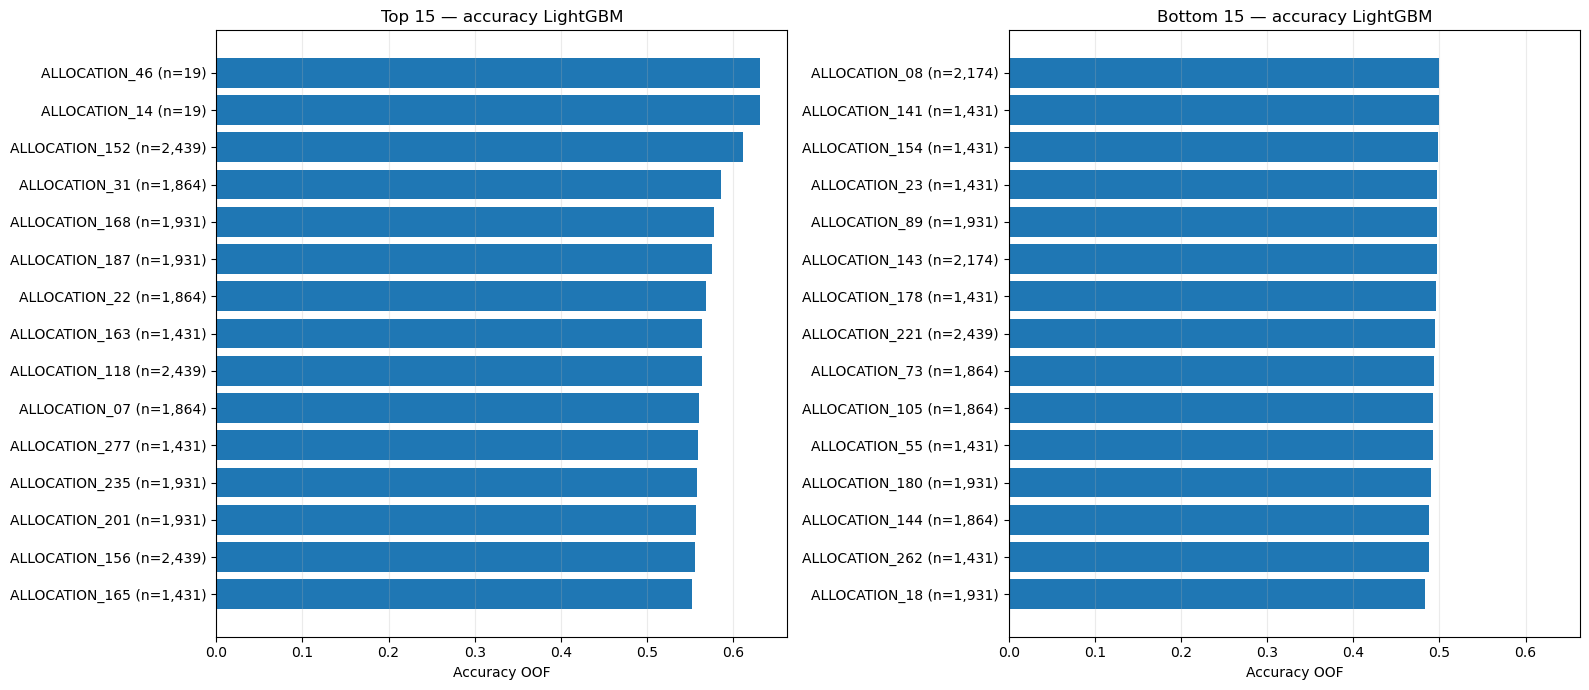

,GROUP,n_observations,accuracy
0,1,100170,52.662%
1,2,134928,52.368%
3,4,123062,52.228%
2,3,168913,51.832%


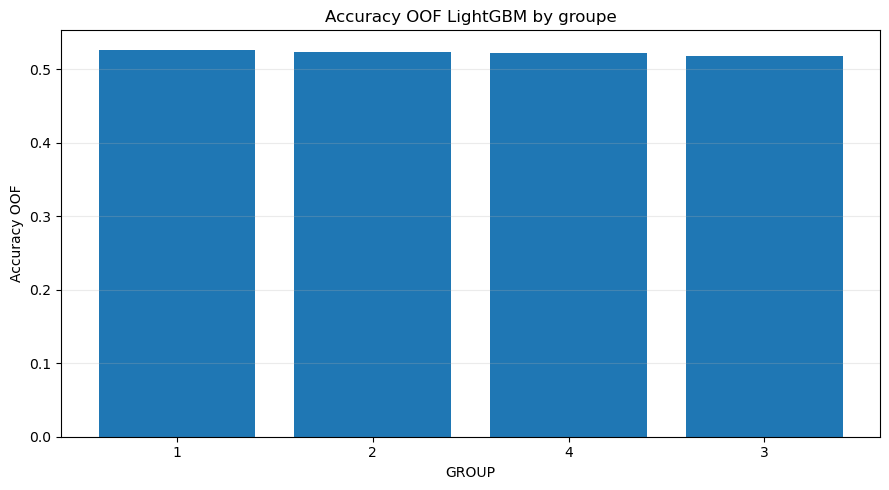

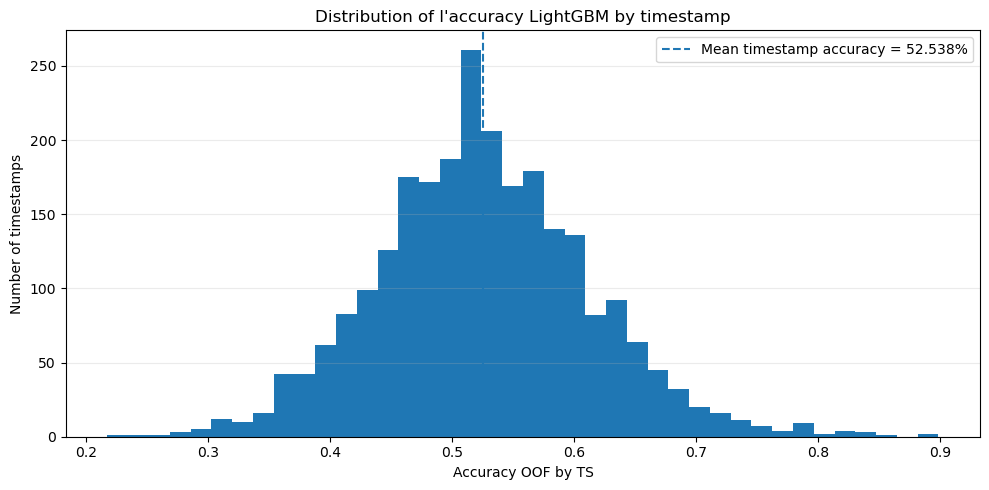

,TS,n_observations,accuracy
0,DATE_0267,69,21.739%
1,DATE_2280,70,24.286%
2,DATE_0905,69,26.087%
3,DATE_1581,69,27.536%
4,DATE_2244,65,27.692%
5,DATE_2299,65,27.692%
6,DATE_0385,69,28.986%
7,DATE_2484,276,28.986%
8,DATE_1144,65,29.231%
9,DATE_1418,65,29.231%


,correlation_with_LightGBM_correct,absolute_correlation
MEDIAN_DAILY_TURNOVER,+0.01410,0.01410
AVERAGE_PERF_20,+0.01139,0.01139
ALLOCATIONS_AVERAGE_PERF_15,+0.01127,0.01127
AVERAGE_PERF_15,+0.01117,0.01117
ALLOCATIONS_AVERAGE_PERF_10,+0.01055,0.01055
ALLOCATIONS_AVERAGE_PERF_20,+0.01031,0.01031
AVERAGE_PERF_10,+0.01004,0.01004
RET_1,+0.00857,0.00857
STD_PERF_20,+0.00848,0.00848
ALLOCATIONS_AVERAGE_PERF_5,+0.00649,0.00649


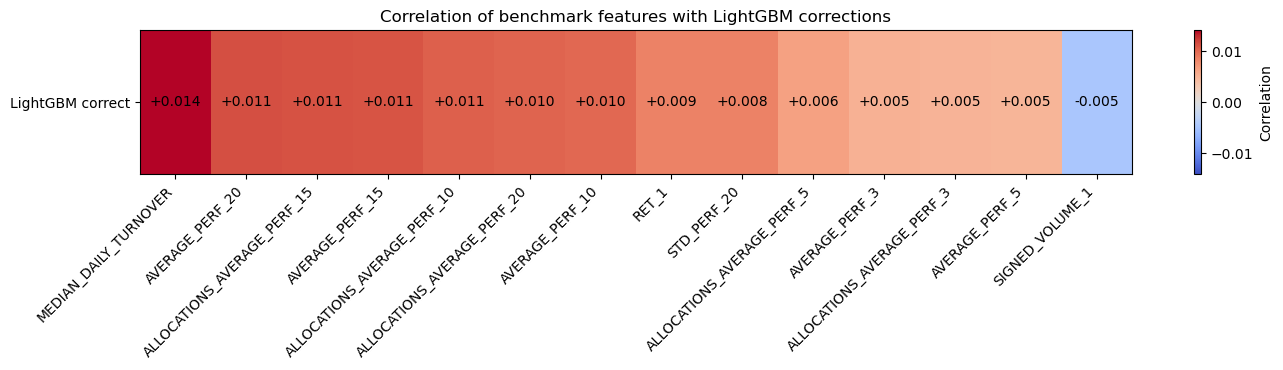

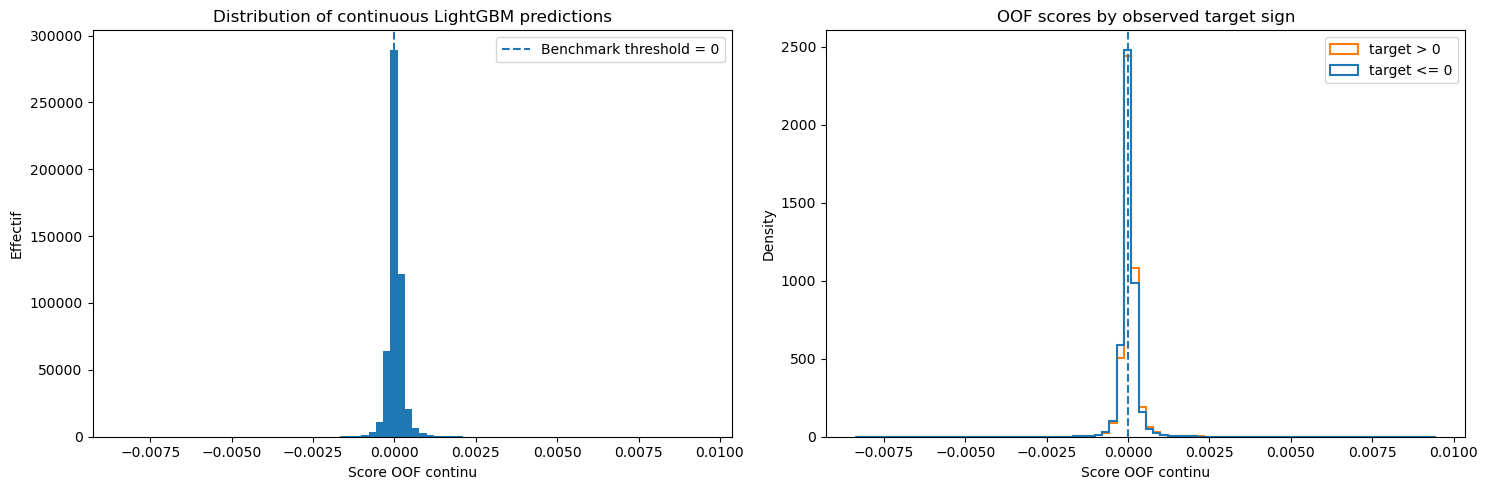

,Population,Count,Mean,Std,Q01,Q05,Q25,Q50,Q75,Q95,Q99
0,All observations,"527,073",+0.000035,+0.000289,-0.000632,-0.000287,-0.000066,+0.000028,+0.000117,+0.000375,+0.000886
1,target <= 0,"259,750",+0.000023,+0.000290,-0.000671,-0.000301,-0.000074,+0.000021,+0.000109,+0.000351,+0.000832
2,target > 0,"267,323",+0.000047,+0.000288,-0.000598,-0.000271,-0.000057,+0.000035,+0.000124,+0.000398,+0.000930


### Rapport automatique — constats OOF

- **RET_1 remains informative**: accuracy OOF 51.892%; RET_1 and LightGBM are simultaneously correct on 43.308% of the rows.
- **Net LightGBM gain**: accuracy OOF 52.220%, or +0.327% relative to RET_1.
- **When LightGBM improves RET_1**: it corrects 8.911% of the rows against 8.584% degraded; the largest standardized difference between these two regimes concerns `MEDIAN_DAILY_TURNOVER` (+0.072).
- **Cross-sectional context**: the largest absolute association among the moyennes of allocation is `ALLOCATIONS_AVERAGE_PERF_15` (+0.0113); this observation is descriptive, not causal.
- **Volume**: correlation of `SIGNED_VOLUME_1` with the correction of the model -0.0047.
- **Turnover**: correlation of `MEDIAN_DAILY_TURNOVER` with the correction of the model +0.0141.
- **Least accurate allocation**: `ALLOCATION_18` with 48.369% on 1,931 observations.
- **Least accurate group**: `3.0` with 51.832% on 168,913 observations.

### Feature hypotheses to assess by ablation

- test relative or ranked versions of `ALLOCATIONS_AVERAGE_PERF_15` (correlation descriptive with the correction: +0.0113).
- test return-volume interactions, the observed association of `SIGNED_VOLUME_1` equal to -0.0047.
- test turnover regimes or ranks, the observed association is +0.0141.

These hypotheses must still improve several folds and at least two validation systems before being retained.

In [7]:
RUN_BENCHMARK_DIAGNOSTICS = True

if not RUN_BENCHMARK_DIAGNOSTICS:
    print("Benchmark diagnostics skipped.")
else:
    required_ids = {"OFFICIAL_LGB_8", "OFFICIAL_RIDGE_8"}
    missing_ids = required_ids.difference(EXPERIMENT_RESULTS_CACHE)
    if missing_ids:
        raise RuntimeError(f"Run Section E first; missing: {sorted(missing_ids)}")
    official_lgb_result = EXPERIMENT_RESULTS_CACHE["OFFICIAL_LGB_8"]
    official_ridge_result = EXPERIMENT_RESULTS_CACHE["OFFICIAL_RIDGE_8"]
    official_benchmark_features = build_benchmark_features(train_raw.drop(columns=["target", "binary_target"]))
    # -----------------------------------------------------------------------------
    # Strict preconditions: this cell computes neither features nor predictions.
    # It only checks that Section 7 has already produced the required OOF objects.
    # -----------------------------------------------------------------------------
    REQUIRED_BENCHMARK_ANALYSIS_OBJECTS = (
        "official_lgb_result",
        "official_ridge_result",
        "official_benchmark_features",
        "official_benchmark_kfold_8",
    )
    missing_analysis_objects = [
        name for name in REQUIRED_BENCHMARK_ANALYSIS_OBJECTS if name not in globals()
    ]
    if missing_analysis_objects:
        raise RuntimeError(
            "Section 7.5 requires OOF results already computed in Section 7. "
            "Missing objects: " + ", ".join(missing_analysis_objects)
        )

    # The tables and vectors below are copies: the benchmark results
    # remain unchanged and no model state is read or modified.
    analysis_lgb_score = np.asarray(
        official_lgb_result["oof_continuous"], dtype=float
    ).copy()
    analysis_lgb_binary = np.asarray(
        official_lgb_result["oof_binary"], dtype=int
    ).copy()
    analysis_ridge_score = np.asarray(
        official_ridge_result["oof_continuous"], dtype=float
    ).copy()
    analysis_ridge_binary = np.asarray(
        official_ridge_result["oof_binary"], dtype=int
    ).copy()
    analysis_fold_ids = np.asarray(
        official_lgb_result["fold_ids"], dtype=int
    ).copy()

    assert len(train_raw) == len(official_benchmark_features)
    assert official_benchmark_features.index.equals(train_raw.index)
    assert all(
        len(values) == len(train_raw)
        for values in (
            analysis_lgb_score,
            analysis_lgb_binary,
            analysis_ridge_score,
            analysis_ridge_binary,
            analysis_fold_ids,
        )
    )
    assert "target" not in official_benchmark_features.columns
    assert "binary_target" not in official_benchmark_features.columns
    assert not any(name.startswith("X_test") for name in REQUIRED_BENCHMARK_ANALYSIS_OBJECTS)

    analysis_oof_mask = (
        np.isfinite(analysis_lgb_score)
        & np.isfinite(analysis_ridge_score)
        & (analysis_lgb_binary >= 0)
        & (analysis_ridge_binary >= 0)
        & (analysis_fold_ids >= 0)
    )
    if not analysis_oof_mask.any():
        raise RuntimeError("No usable common OOF prediction was found.")

    def build_naive_oof_predictions(df, folds):
        """Reconstructs the two naive signals on existing validation rows only."""
        y_binary = df["binary_target"].to_numpy(dtype=int)
        majority_oof = np.full(len(df), -1, dtype=int)
        ret1_oof = np.full(len(df), -1, dtype=int)
        fold_ids = np.full(len(df), -1, dtype=int)
        majority_fold_scores = []
        ret1_fold_scores = []

        for fold_id, fold in enumerate(folds):
            train_idx = np.asarray(fold["train_idx"], dtype=int)
            valid_idx = np.asarray(fold["valid_idx"], dtype=int)

            # Same rule as Section 5: class 1 when the training mean is at least 0.5.
            majority_class = int(y_binary[train_idx].mean() >= 0.5)
            majority_prediction = np.full(len(valid_idx), majority_class, dtype=int)

            # Same rule as Section 5: positive signal when RET_1 > 0.
            ret1_prediction = (
                df.iloc[valid_idx]["RET_1"].to_numpy(dtype=float) > 0.0
            ).astype(int)

            majority_oof[valid_idx] = majority_prediction
            ret1_oof[valid_idx] = ret1_prediction
            fold_ids[valid_idx] = fold_id
            majority_fold_scores.append(
                accuracy_score(y_binary[valid_idx], majority_prediction)
            )
            ret1_fold_scores.append(
                accuracy_score(y_binary[valid_idx], ret1_prediction)
            )

        return {
            "majority_oof": majority_oof,
            "ret1_oof": ret1_oof,
            "fold_ids": fold_ids,
            "majority_fold_scores": majority_fold_scores,
            "ret1_fold_scores": ret1_fold_scores,
        }


    def performance_summary_row(name, fold_scores, y_true, oof_prediction):
        """Formats one consistent comparison-table row."""
        fold_scores = np.asarray(fold_scores, dtype=float)
        oof_prediction = np.asarray(oof_prediction, dtype=int)
        covered = oof_prediction >= 0
        return {
            "Model": name,
            "Mean Accuracy": float(fold_scores.mean()),
            "Best Fold": float(fold_scores.max()),
            "Worst Fold": float(fold_scores.min()),
            "Std": float(fold_scores.std(ddof=0)),
            "Global OOF Accuracy": float(
                accuracy_score(np.asarray(y_true)[covered], oof_prediction[covered])
            ),
        }


    analysis_naive_oof = build_naive_oof_predictions(
        train_raw, official_benchmark_kfold_8
    )
    analysis_y_binary = train_raw["binary_target"].to_numpy(dtype=int)

    benchmark_performance_summary = pd.DataFrame([
        performance_summary_row(
            "Majority",
            analysis_naive_oof["majority_fold_scores"],
            analysis_y_binary,
            analysis_naive_oof["majority_oof"],
        ),
        performance_summary_row(
            "RET_1 baseline",
            analysis_naive_oof["ret1_fold_scores"],
            analysis_y_binary,
            analysis_naive_oof["ret1_oof"],
        ),
        performance_summary_row(
            "Ridge",
            official_ridge_result["fold_scores"],
            analysis_y_binary,
            analysis_ridge_binary,
        ),
        performance_summary_row(
            "LightGBM",
            official_lgb_result["fold_scores"],
            analysis_y_binary,
            analysis_lgb_binary,
        ),
    ])
    display(
        benchmark_performance_summary.style
        .format({column: "{:.4%}" for column in benchmark_performance_summary.columns[1:]})
        .set_caption("OOF comparison on benchmark folds")
    )

    analysis_ret1_binary = analysis_naive_oof["ret1_oof"].copy()
    agreement_mask = analysis_oof_mask & (analysis_ret1_binary >= 0)

    prediction_agreement = pd.DataFrame({
        "RET1 correct ?": (
            analysis_ret1_binary[agreement_mask] == analysis_y_binary[agreement_mask]
        ),
        "LightGBM correct ?": (
            analysis_lgb_binary[agreement_mask] == analysis_y_binary[agreement_mask]
        ),
    }, index=train_raw.index[agreement_mask])

    prediction_agreement["Agreement case"] = np.select(
        [
            prediction_agreement["RET1 correct ?"] & prediction_agreement["LightGBM correct ?"],
            ~prediction_agreement["RET1 correct ?"] & ~prediction_agreement["LightGBM correct ?"],
            ~prediction_agreement["RET1 correct ?"] & prediction_agreement["LightGBM correct ?"],
            prediction_agreement["RET1 correct ?"] & ~prediction_agreement["LightGBM correct ?"],
        ],
        [
            "Both correct",
            "Both incorrect",
            "RET1 faux mais LightGBM correct",
            "RET1 correct mais LightGBM faux",
        ],
        default="Unclassified",
    )

    agreement_order = [
        "Both correct",
        "Both incorrect",
        "RET1 faux mais LightGBM correct",
        "RET1 correct mais LightGBM faux",
    ]
    agreement_counts = (
        prediction_agreement["Agreement case"]
        .value_counts()
        .reindex(agreement_order, fill_value=0)
    )
    prediction_agreement_summary = pd.DataFrame({
        "Case": agreement_counts.index,
        "Count": agreement_counts.to_numpy(),
        "Proportion": agreement_counts.to_numpy() / agreement_counts.sum(),
    })

    display(prediction_agreement.head(10))
    display(
        prediction_agreement_summary.style
        .format({"Count": "{:,.0f}", "Proportion": "{:.3%}"})
        .set_caption("Agreement and disagreement between RET_1 and LightGBM")
    )

    BENCHMARK_ANALYSIS_FEATURES = [
        "ALLOCATIONS_AVERAGE_PERF_3",
        "ALLOCATIONS_AVERAGE_PERF_5",
        "ALLOCATIONS_AVERAGE_PERF_10",
        "ALLOCATIONS_AVERAGE_PERF_20",
        "STD_PERF_20",
    ]
    missing_benchmark_analysis_features = [
        feature for feature in BENCHMARK_ANALYSIS_FEATURES
        if feature not in official_benchmark_features.columns
    ]
    if missing_benchmark_analysis_features:
        raise RuntimeError(
            "Features benchmark missing: "
            + ", ".join(missing_benchmark_analysis_features)
        )

    benchmark_error_analysis = train_raw.loc[analysis_oof_mask, [
        "ROW_ID",
        "TS",
        "ALLOCATION",
        "GROUP",
        "target",
        "binary_target",
        "RET_1",
        "SIGNED_VOLUME_1",
        "MEDIAN_DAILY_TURNOVER",
    ]].copy()
    for feature in BENCHMARK_ANALYSIS_FEATURES:
        benchmark_error_analysis[feature] = official_benchmark_features.loc[
            analysis_oof_mask, feature
        ].to_numpy(copy=True)

    benchmark_error_analysis["prediction LightGBM"] = analysis_lgb_score[analysis_oof_mask]
    benchmark_error_analysis["prediction Ridge"] = analysis_ridge_score[analysis_oof_mask]
    benchmark_error_analysis["LightGBM class"] = analysis_lgb_binary[analysis_oof_mask]
    benchmark_error_analysis["Ridge class"] = analysis_ridge_binary[analysis_oof_mask]
    benchmark_error_analysis["RET1 class"] = analysis_ret1_binary[analysis_oof_mask]
    benchmark_error_analysis["RET1 correct"] = (
        benchmark_error_analysis["RET1 class"]
        == benchmark_error_analysis["binary_target"]
    )
    benchmark_error_analysis["LightGBM correct"] = (
        benchmark_error_analysis["LightGBM class"]
        == benchmark_error_analysis["binary_target"]
    )

    benchmark_error_subsets = {
        "RET1 faux": benchmark_error_analysis.loc[
            ~benchmark_error_analysis["RET1 correct"]
        ].copy(),
        "LightGBM faux": benchmark_error_analysis.loc[
            ~benchmark_error_analysis["LightGBM correct"]
        ].copy(),
        "RET1 faux MAIS LightGBM correct": benchmark_error_analysis.loc[
            ~benchmark_error_analysis["RET1 correct"]
            & benchmark_error_analysis["LightGBM correct"]
        ].copy(),
        "RET1 correct MAIS LightGBM faux": benchmark_error_analysis.loc[
            benchmark_error_analysis["RET1 correct"]
            & ~benchmark_error_analysis["LightGBM correct"]
        ].copy(),
    }

    benchmark_error_subset_summary = pd.DataFrame([
        {
            "Subset": name,
            "Count": len(subset),
            "Percentage": len(subset) / len(benchmark_error_analysis),
        }
        for name, subset in benchmark_error_subsets.items()
    ])
    display(benchmark_error_analysis.head())
    display(
        benchmark_error_subset_summary.style
        .format({"Count": "{:,.0f}", "Percentage": "{:.3%}"})
        .set_caption("Taille of the sous-sets of errors OOF")
    )

    def plot_error_subset_distributions(subsets, variable_map):
        """Compares four subsets with consistent matplotlib boxplots."""
        subset_names = list(subsets)
        figure, axes = plt.subplots(2, 2, figsize=(16, 10))
        axes = axes.ravel()

        for axis, (display_name, column) in zip(axes, variable_map.items()):
            plot_values = []
            plot_labels = []
            for subset_name in subset_names:
                values = pd.to_numeric(
                    subsets[subset_name][column], errors="coerce"
                ).to_numpy(dtype=float)
                values = values[np.isfinite(values)]
                if values.size:
                    plot_values.append(values)
                    plot_labels.append(f"{subset_name}\n(n={len(values):,})")

            if plot_values:
                axis.boxplot(plot_values, showfliers=False)
                axis.set_xticks(range(1, len(plot_labels) + 1))
                axis.set_xticklabels(plot_labels, rotation=20, ha="right")
            axis.set_title(f"Distribution of {display_name}")
            axis.set_ylabel(display_name)
            axis.grid(axis="y", alpha=0.25)

        figure.suptitle(
            "Error regimes: RET_1 versus LightGBM (OOF)", fontsize=14
        )
        figure.tight_layout()
        return figure, axes


    ERROR_DISTRIBUTION_VARIABLES = {
        "RET1": "RET_1",
        "STD20": "STD_PERF_20",
        "SIGNED_VOLUME1": "SIGNED_VOLUME_1",
        "TURNOVER": "MEDIAN_DAILY_TURNOVER",
    }
    error_distribution_figure, error_distribution_axes = (
        plot_error_subset_distributions(
            benchmark_error_subsets,
            ERROR_DISTRIBUTION_VARIABLES,
        )
    )
    plt.show()

    def accuracy_by_category_from_oof(analysis_df, category_column):
        """Aggregates count and OOF accuracy for a training category."""
        return (
            analysis_df.groupby(category_column, dropna=False)["LightGBM correct"]
            .agg(n_observations="size", accuracy="mean")
            .reset_index()
        )


    def plot_ranked_category_accuracy(top_table, bottom_table, category_column):
        """Displays the most and least accurate categories side by side."""
        figure, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True)
        for axis, table, title in (
            (axes[0], top_table, "Top 15"),
            (axes[1], bottom_table, "Bottom 15"),
        ):
            ordered = table.sort_values("accuracy", ascending=True)
            labels = [
                f"{category} (n={count:,})"
                for category, count in zip(
                    ordered[category_column], ordered["n_observations"]
                )
            ]
            axis.barh(labels, ordered["accuracy"])
            axis.set_title(f"{title} — accuracy LightGBM")
            axis.set_xlabel("Accuracy OOF")
            axis.grid(axis="x", alpha=0.25)
        figure.tight_layout()
        return figure, axes


    allocation_accuracy = accuracy_by_category_from_oof(
        benchmark_error_analysis, "ALLOCATION"
    )
    allocation_top_15 = allocation_accuracy.nlargest(15, "accuracy")
    allocation_bottom_15 = allocation_accuracy.nsmallest(15, "accuracy")

    display(allocation_top_15.reset_index(drop=True).style.format({"accuracy": "{:.3%}"}))
    display(allocation_bottom_15.reset_index(drop=True).style.format({"accuracy": "{:.3%}"}))
    allocation_accuracy_figure, allocation_accuracy_axes = (
        plot_ranked_category_accuracy(
            allocation_top_15,
            allocation_bottom_15,
            "ALLOCATION",
        )
    )
    plt.show()

    group_accuracy = accuracy_by_category_from_oof(
        benchmark_error_analysis, "GROUP"
    ).sort_values("accuracy", ascending=False)
    display(group_accuracy.style.format({"accuracy": "{:.3%}"}))

    figure, axis = plt.subplots(figsize=(9, 5))
    axis.bar(group_accuracy["GROUP"].astype(str), group_accuracy["accuracy"])
    axis.set_title("Accuracy OOF LightGBM by groupe")
    axis.set_xlabel("GROUP")
    axis.set_ylabel("Accuracy OOF")
    axis.grid(axis="y", alpha=0.25)
    figure.tight_layout()
    plt.show()

    timestamp_accuracy = (
        benchmark_error_analysis.groupby("TS", dropna=False)["LightGBM correct"]
        .agg(n_observations="size", accuracy="mean")
        .reset_index()
    )
    hardest_timestamps = timestamp_accuracy.nsmallest(15, "accuracy")

    figure, axis = plt.subplots(figsize=(10, 5))
    axis.hist(timestamp_accuracy["accuracy"].dropna(), bins=40)
    axis.axvline(
        timestamp_accuracy["accuracy"].mean(),
        linestyle="--",
        label=f"Mean timestamp accuracy = {timestamp_accuracy['accuracy'].mean():.3%}",
    )
    axis.set_title("Distribution of l'accuracy LightGBM by timestamp")
    axis.set_xlabel("Accuracy OOF by TS")
    axis.set_ylabel("Number of timestamps")
    axis.legend()
    axis.grid(axis="y", alpha=0.25)
    figure.tight_layout()
    plt.show()

    display(
        hardest_timestamps.reset_index(drop=True).style
        .format({"accuracy": "{:.3%}"})
        .set_caption("15 least accurate timestamps")
    )

    RELATIONSHIP_FEATURES = [
        "RET_1",
        "AVERAGE_PERF_3",
        "AVERAGE_PERF_5",
        "AVERAGE_PERF_10",
        "AVERAGE_PERF_15",
        "AVERAGE_PERF_20",
        "ALLOCATIONS_AVERAGE_PERF_3",
        "ALLOCATIONS_AVERAGE_PERF_5",
        "ALLOCATIONS_AVERAGE_PERF_10",
        "ALLOCATIONS_AVERAGE_PERF_15",
        "ALLOCATIONS_AVERAGE_PERF_20",
        "STD_PERF_20",
        "SIGNED_VOLUME_1",
        "MEDIAN_DAILY_TURNOVER",
    ]

    relationship_frame = pd.DataFrame(index=benchmark_error_analysis.index)
    for feature in RELATIONSHIP_FEATURES:
        if feature in benchmark_error_analysis.columns:
            relationship_frame[feature] = benchmark_error_analysis[feature]
        elif feature in official_benchmark_features.columns:
            relationship_frame[feature] = official_benchmark_features.loc[
                analysis_oof_mask, feature
            ].to_numpy(copy=True)
        else:
            raise RuntimeError(f"Feature benchmark missing: {feature}")
    relationship_frame["LightGBM correct"] = benchmark_error_analysis[
        "LightGBM correct"
    ].astype(float)

    feature_correctness_correlations = (
        relationship_frame.corr(numeric_only=True)["LightGBM correct"]
        .drop("LightGBM correct")
        .rename("correlation_with_LightGBM_correct")
        .to_frame()
    )
    feature_correctness_correlations["absolute_correlation"] = (
        feature_correctness_correlations[
            "correlation_with_LightGBM_correct"
        ].abs()
    )
    feature_correctness_correlations = feature_correctness_correlations.sort_values(
        "absolute_correlation", ascending=False
    )

    display(
        feature_correctness_correlations.style
        .format({
            "correlation_with_LightGBM_correct": "{:+.5f}",
            "absolute_correlation": "{:.5f}",
        })
        .set_caption("Relationships with model corrections — not with the target")
    )

    heatmap_values = feature_correctness_correlations[
        "correlation_with_LightGBM_correct"
    ].to_numpy(dtype=float)
    heatmap_scale = max(float(np.nanmax(np.abs(heatmap_values))), EPS)
    figure, axis = plt.subplots(figsize=(14, 3.8))
    image = axis.imshow(
        heatmap_values.reshape(1, -1),
        aspect="auto",
        cmap="coolwarm",
        vmin=-heatmap_scale,
        vmax=heatmap_scale,
    )
    axis.set_yticks([0])
    axis.set_yticklabels(["LightGBM correct"])
    axis.set_xticks(np.arange(len(feature_correctness_correlations)))
    axis.set_xticklabels(
        feature_correctness_correlations.index,
        rotation=45,
        ha="right",
    )
    for column_index, value in enumerate(heatmap_values):
        axis.text(column_index, 0, f"{value:+.3f}", ha="center", va="center")
    axis.set_title("Correlation of benchmark features with LightGBM corrections")
    figure.colorbar(image, ax=axis, label="Correlation")
    figure.tight_layout()
    plt.show()

    calibration_frame = pd.DataFrame({
        "LightGBM OOF score": analysis_lgb_score[analysis_oof_mask],
        "Actual class": analysis_y_binary[analysis_oof_mask],
    })

    figure, axes = plt.subplots(1, 2, figsize=(15, 5))
    axes[0].hist(calibration_frame["LightGBM OOF score"], bins=80)
    axes[0].axvline(0.0, linestyle="--", label="Benchmark threshold = 0")
    axes[0].set_title("Distribution of continuous LightGBM predictions")
    axes[0].set_xlabel("Score OOF continu")
    axes[0].set_ylabel("Effectif")
    axes[0].legend()

    negative_scores = calibration_frame.loc[
        calibration_frame["Actual class"].eq(0), "LightGBM OOF score"
    ]
    positive_scores = calibration_frame.loc[
        calibration_frame["Actual class"].eq(1), "LightGBM OOF score"
    ]
    axes[1].hist(
        [negative_scores, positive_scores],
        bins=80,
        density=True,
        label=["target <= 0", "target > 0"],
        histtype="step",
        linewidth=1.5,
    )
    axes[1].axvline(0.0, linestyle="--")
    axes[1].set_title("OOF scores by observed target sign")
    axes[1].set_xlabel("Score OOF continu")
    axes[1].set_ylabel("Density")
    axes[1].legend()
    figure.tight_layout()
    plt.show()

    def score_distribution_statistics(values, label):
        """Summarizes a finite distribution of OOF scores."""
        values = pd.Series(values).dropna()
        quantiles = values.quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
        return {
            "Population": label,
            "Count": len(values),
            "Mean": values.mean(),
            "Std": values.std(ddof=0),
            "Q01": quantiles.loc[0.01],
            "Q05": quantiles.loc[0.05],
            "Q25": quantiles.loc[0.25],
            "Q50": quantiles.loc[0.50],
            "Q75": quantiles.loc[0.75],
            "Q95": quantiles.loc[0.95],
            "Q99": quantiles.loc[0.99],
        }


    lightgbm_score_statistics = pd.DataFrame([
        score_distribution_statistics(
            calibration_frame["LightGBM OOF score"], "All observations"
        ),
        score_distribution_statistics(negative_scores, "target <= 0"),
        score_distribution_statistics(positive_scores, "target > 0"),
    ])
    display(
        lightgbm_score_statistics.style
        .format({
            "Count": "{:,.0f}",
            **{
                column: "{:+.6f}"
                for column in lightgbm_score_statistics.columns
                if column not in {"Population", "Count"}
            },
        })
        .set_caption("Statistiques of the scores OOF continus")
    )

    def _safe_group_value(table, category_column, category_value, value_column):
        matches = table.loc[table[category_column].astype(str).eq(str(category_value)), value_column]
        return float(matches.iloc[0]) if len(matches) else np.nan


    def generate_automatic_benchmark_report(
        performance_table,
        agreement_table,
        correlation_table,
        allocation_table,
        group_table,
        error_analysis_df,
    ):
        """Produces numerical observations and conditional hypotheses from available evidence."""
        performance = performance_table.set_index("Model")
        ret1_accuracy = float(performance.loc["RET_1 baseline", "Global OOF Accuracy"])
        lgb_accuracy = float(performance.loc["LightGBM", "Global OOF Accuracy"])
        accuracy_gain = lgb_accuracy - ret1_accuracy

        agreement = agreement_table.set_index("Case")
        both_correct = float(agreement.loc["Both correct", "Proportion"])
        rescued = float(
            agreement.loc["RET1 faux mais LightGBM correct", "Proportion"]
        )
        degraded = float(
            agreement.loc["RET1 correct mais LightGBM faux", "Proportion"]
        )

        correlations = correlation_table[
            "correlation_with_LightGBM_correct"
        ].dropna()
        cross_sectional = correlations.loc[
            correlations.index.str.startswith("ALLOCATIONS_AVERAGE_PERF_")
        ]
        strongest_cross_feature = (
            cross_sectional.abs().idxmax() if len(cross_sectional) else None
        )
        strongest_cross_correlation = (
            float(cross_sectional.loc[strongest_cross_feature])
            if strongest_cross_feature is not None else np.nan
        )
        volume_correlation = float(correlations.get("SIGNED_VOLUME_1", np.nan))
        turnover_correlation = float(
            correlations.get("MEDIAN_DAILY_TURNOVER", np.nan)
        )

        difficult_allocation = allocation_table.nsmallest(1, "accuracy").iloc[0]
        difficult_group = group_table.nsmallest(1, "accuracy").iloc[0]

        rescue_mask = (
            ~error_analysis_df["RET1 correct"]
            & error_analysis_df["LightGBM correct"]
        )
        degradation_mask = (
            error_analysis_df["RET1 correct"]
            & ~error_analysis_df["LightGBM correct"]
        )

        diagnostic_features = [
            "ALLOCATIONS_AVERAGE_PERF_3",
            "ALLOCATIONS_AVERAGE_PERF_5",
            "ALLOCATIONS_AVERAGE_PERF_10",
            "ALLOCATIONS_AVERAGE_PERF_20",
            "SIGNED_VOLUME_1",
            "MEDIAN_DAILY_TURNOVER",
        ]
        regime_differences = []
        for feature in diagnostic_features:
            rescue_values = pd.to_numeric(
                error_analysis_df.loc[rescue_mask, feature], errors="coerce"
            ).dropna()
            degradation_values = pd.to_numeric(
                error_analysis_df.loc[degradation_mask, feature], errors="coerce"
            ).dropna()
            pooled_std = pd.to_numeric(
                error_analysis_df[feature], errors="coerce"
            ).std(ddof=0)
            if len(rescue_values) and len(degradation_values) and pooled_std > EPS:
                standardized_difference = (
                    rescue_values.mean() - degradation_values.mean()
                ) / pooled_std
                regime_differences.append((feature, float(standardized_difference)))
        strongest_regime_feature, strongest_regime_difference = (
            max(regime_differences, key=lambda item: abs(item[1]))
            if regime_differences else ("no", np.nan)
        )

        hypotheses = []
        if strongest_cross_feature is not None:
            hypotheses.append(
                f"test relative or ranked versions of `{strongest_cross_feature}` "
                f"(correlation descriptive with the correction: {strongest_cross_correlation:+.4f})"
            )
        if np.isfinite(volume_correlation):
            hypotheses.append(
                f"test return-volume interactions, the observed association of "
                f"`SIGNED_VOLUME_1` equal to {volume_correlation:+.4f}"
            )
        if np.isfinite(turnover_correlation):
            hypotheses.append(
                f"test turnover regimes or ranks, the observed association is "
                f"{turnover_correlation:+.4f}"
            )
        if not hypotheses:
            hypotheses.append("no additional hypothesis supported by the available diagnostics")

        report_lines = [
            "### Rapport automatique — constats OOF",
            "",
            f"- **RET_1 remains informative**: accuracy OOF {ret1_accuracy:.3%}; "
            f"RET_1 and LightGBM are simultaneously correct on {both_correct:.3%} of the rows.",
            f"- **Net LightGBM gain**: accuracy OOF {lgb_accuracy:.3%}, or "
            f"{accuracy_gain:+.3%} relative to RET_1.",
            f"- **When LightGBM improves RET_1**: it corrects {rescued:.3%} of the rows "
            f"against {degraded:.3%} degraded; the largest standardized difference "
            f"between these two regimes concerns `{strongest_regime_feature}` "
            f"({strongest_regime_difference:+.3f}).",
            f"- **Cross-sectional context**: the largest absolute association among "
            f"the moyennes of allocation is `{strongest_cross_feature}` "
            f"({strongest_cross_correlation:+.4f}); this observation is descriptive, not causal.",
            f"- **Volume**: correlation of `SIGNED_VOLUME_1` with the correction of the model "
            f"{volume_correlation:+.4f}.",
            f"- **Turnover**: correlation of `MEDIAN_DAILY_TURNOVER` with the correction "
            f"of the model {turnover_correlation:+.4f}.",
            f"- **Least accurate allocation**: `{difficult_allocation['ALLOCATION']}` "
            f"with {difficult_allocation['accuracy']:.3%} on "
            f"{int(difficult_allocation['n_observations']):,} observations.",
            f"- **Least accurate group**: `{difficult_group['GROUP']}` with "
            f"{difficult_group['accuracy']:.3%} on "
            f"{int(difficult_group['n_observations']):,} observations.",
            "",
            "### Feature hypotheses to assess by ablation",
            "",
            *[f"- {hypothesis}." for hypothesis in hypotheses],
            "",
            "These hypotheses must still improve several folds and at least two "
            "validation systems before being retained.",
        ]
        return "\n".join(report_lines)


    automatic_benchmark_report = generate_automatic_benchmark_report(
        benchmark_performance_summary,
        prediction_agreement_summary,
        feature_correctness_correlations,
        allocation_accuracy,
        group_accuracy,
        benchmark_error_analysis,
    )

    from IPython.display import Markdown
    display(Markdown(automatic_benchmark_report))


## 9. Feature engineering

### What we do
Define independent cross-sectional, confidence, interaction, regime, and turnover blocks.

### How
A registry combines only requested blocks and enforces alignment and leakage checks.

### Why
Independent blocks make ablations interpretable and prevent accidental feature accumulation.

### Link to the project objective
The features describe relative and recent conditions associated with return direction.


In [8]:
FEATURE_FORBIDDEN_COLUMNS = {"target", "binary_target"}
FEATURE_IDENTITY_COLUMNS = {"ROW_ID", "TS", "ALLOCATION", "GROUP"}


def _validate_feature_source(df, required_columns, block_name):
    """Validates a predictor-only source without modifying it."""
    if not isinstance(df, pd.DataFrame):
        raise TypeError(f"{block_name}: df must be a pandas DataFrame")
    leaked_targets = FEATURE_FORBIDDEN_COLUMNS.intersection(df.columns)
    if leaked_targets:
        raise ValueError(
            f"{block_name}: targets forbidden: {sorted(leaked_targets)}"
        )
    missing = set(required_columns).difference(df.columns)
    if missing:
        raise ValueError(f"{block_name}: columns missing: {sorted(missing)}")


def _safe_feature_ratio(numerator, denominator):
    """Aligned division; near-zero denominators produce NaN."""
    numerator = pd.to_numeric(numerator, errors="coerce")
    denominator = pd.to_numeric(denominator, errors="coerce")
    return numerator / denominator.mask(denominator.abs() <= EPS)


def _return_columns(horizon):
    return [f"RET_{lag}" for lag in range(1, horizon + 1)]


def _volume_columns(horizon):
    return [f"SIGNED_VOLUME_{lag}" for lag in range(1, horizon + 1)]


def _row_mean(df, columns):
    return df[columns].mean(axis=1)


def _row_std(df, columns):
    return df[columns].std(axis=1)


def _paired_row_correlation(left, right, index):
    """Vectorized pairwise correlation with NaN and constant-value handling."""
    left_values = np.asarray(left, dtype=float)
    right_values = np.asarray(right, dtype=float)
    valid = np.isfinite(left_values) & np.isfinite(right_values)
    counts = valid.sum(axis=1)
    safe_counts = np.maximum(counts, 1)
    left_mean = np.where(valid, left_values, 0.0).sum(axis=1) / safe_counts
    right_mean = np.where(valid, right_values, 0.0).sum(axis=1) / safe_counts
    left_centered = np.where(valid, left_values - left_mean[:, None], 0.0)
    right_centered = np.where(valid, right_values - right_mean[:, None], 0.0)
    numerator = np.sum(left_centered * right_centered, axis=1)
    denominator = np.sqrt(
        np.sum(left_centered ** 2, axis=1)
        * np.sum(right_centered ** 2, axis=1)
    )
    output = np.full(len(left_values), np.nan, dtype=float)
    usable = (counts >= 2) & (denominator > EPS)
    output[usable] = numerator[usable] / denominator[usable]
    return pd.Series(output, index=index)


def _paired_sign_agreement_rate(left, right, index):
    """Share of observed lags with matching return and volume signs."""
    left_values = np.asarray(left, dtype=float)
    right_values = np.asarray(right, dtype=float)
    valid = np.isfinite(left_values) & np.isfinite(right_values)
    counts = valid.sum(axis=1)
    agreements = (
        (np.sign(left_values) == np.sign(right_values)) & valid
    ).sum(axis=1)
    output = np.full(len(left_values), np.nan, dtype=float)
    usable = counts > 0
    output[usable] = agreements[usable] / counts[usable]
    return pd.Series(output, index=index)


def _same_sign(left, right):
    left = pd.to_numeric(left, errors="coerce")
    right = pd.to_numeric(right, errors="coerce")
    observed = left.notna() & right.notna()
    return pd.Series(
        np.where(observed, (np.sign(left) == np.sign(right)).astype(float), np.nan),
        index=left.index,
    )


def _finalize_hypothesis_block(features, source_index, block_name):
    """Applies the shared contract to a new feature block."""
    if not isinstance(features, pd.DataFrame):
        raise TypeError(f"{block_name}: the builder must retourner a DataFrame")
    if len(features) != len(source_index) or not features.index.equals(source_index):
        raise ValueError(f"{block_name}: row count, order, or index changed")
    if not features.columns.is_unique:
        duplicates = features.columns[features.columns.duplicated()].tolist()
        raise ValueError(f"{block_name}: noms duplicated: {duplicates}")
    forbidden = (
        FEATURE_FORBIDDEN_COLUMNS | FEATURE_IDENTITY_COLUMNS
    ).intersection(features.columns)
    if forbidden:
        raise ValueError(f"{block_name}: columns forbidden: {sorted(forbidden)}")
    non_numeric = features.select_dtypes(exclude=np.number).columns.tolist()
    if non_numeric:
        raise TypeError(f"{block_name}: non-numeric features: {non_numeric}")
    return features.replace([np.inf, -np.inf], np.nan)


def build_cross_sectional_feature_block(df):
    """Builds 24 timestamp-relative positions without target or future information."""
    required = {
        "TS", "RET_1", "SIGNED_VOLUME_1", "MEDIAN_DAILY_TURNOVER",
        *_return_columns(20), *_volume_columns(5),
    }
    _validate_feature_source(df, required, "cross_sectional")
    base = pd.DataFrame(index=df.index)
    base["RET1"] = pd.to_numeric(df["RET_1"], errors="coerce")
    base["RET_MEAN3"] = _row_mean(df, _return_columns(3))
    base["RET_MEAN5"] = _row_mean(df, _return_columns(5))
    base["RET_STD5"] = _row_std(df, _return_columns(5))
    base["RET_STD20"] = _row_std(df, _return_columns(20))
    base["SIGNED_VOLUME1"] = pd.to_numeric(
        df["SIGNED_VOLUME_1"], errors="coerce"
    )
    base["SIGNED_VOLUME_MEAN5"] = _row_mean(df, _volume_columns(5))
    base["TURNOVER"] = pd.to_numeric(
        df["MEDIAN_DAILY_TURNOVER"], errors="coerce"
    )

    output = pd.DataFrame(index=df.index)
    for base_name in base.columns:
        values = base[base_name]
        grouped = values.groupby(df["TS"], dropna=False)
        ts_mean = grouped.transform("mean")
        ts_std = grouped.transform("std")
        output[f"CS_{base_name}_TS_PERCENTILE"] = grouped.rank(
            pct=True, method="average"
        )
        output[f"CS_{base_name}_TS_ZSCORE"] = _safe_feature_ratio(
            values - ts_mean, ts_std
        )
        output[f"CS_{base_name}_MINUS_TS_MEAN"] = values - ts_mean

    source_counts = df.groupby("TS", dropna=False).size()
    output_counts = pd.DataFrame({"TS": df["TS"]}, index=output.index).groupby(
        "TS", dropna=False
    ).size()
    if not source_counts.equals(output_counts):
        raise AssertionError("cross_sectional: the row count by TS a changed")
    return _finalize_hypothesis_block(output, df.index, "cross_sectional")


def build_ret1_confidence_feature_block(df):
    """Builds 15 compact measures of RET_1 strength and consistency."""
    _validate_feature_source(
        df, set(_return_columns(20)), "ret1_confidence"
    )
    ret1 = pd.to_numeric(df["RET_1"], errors="coerce")
    ret2 = pd.to_numeric(df["RET_2"], errors="coerce")
    mean3 = _row_mean(df, _return_columns(3))
    mean5 = _row_mean(df, _return_columns(5))
    mean20 = _row_mean(df, _return_columns(20))
    std5 = _row_std(df, _return_columns(5))
    std20 = _row_std(df, _return_columns(20))
    mean_abs5 = df[_return_columns(5)].abs().mean(axis=1)
    mean_abs20 = df[_return_columns(20)].abs().mean(axis=1)

    output = pd.DataFrame(index=df.index)
    output["R1C_ABS_RET1"] = ret1.abs()
    output["R1C_RET1_SQUARED"] = ret1.pow(2)
    output["R1C_SIGN_RET1"] = np.sign(ret1)
    output["R1C_RET1_OVER_STD5"] = _safe_feature_ratio(ret1, std5)
    output["R1C_RET1_OVER_STD20"] = _safe_feature_ratio(ret1, std20)
    output["R1C_RET1_MINUS_MEAN3"] = ret1 - mean3
    output["R1C_RET1_MINUS_MEAN5"] = ret1 - mean5
    output["R1C_RET1_MINUS_MEAN20"] = ret1 - mean20
    output["R1C_ABS_RET1_MINUS_MEAN5"] = (ret1 - mean5).abs()
    output["R1C_RET1_OVER_MEAN_ABS5"] = _safe_feature_ratio(ret1, mean_abs5)
    output["R1C_RET1_OVER_MEAN_ABS20"] = _safe_feature_ratio(ret1, mean_abs20)
    output["R1C_RET1_NEAR_ZERO"] = np.where(
        std5.notna(), ret1.abs().le(0.25 * std5).astype(float), np.nan
    )
    output["R1C_ABS_RET1_ABOVE_STD5"] = np.where(
        std5.notna(), ret1.abs().gt(std5).astype(float), np.nan
    )
    output["R1C_SIGN_AGREES_MEAN3"] = _same_sign(ret1, mean3)
    output["R1C_SIGN_AGREES_RET2"] = _same_sign(ret1, ret2)
    return _finalize_hypothesis_block(output, df.index, "ret1_confidence")


def build_return_volume_interaction_block(df):
    """Builds 14 vectorized return-volume interactions."""
    required = {*_return_columns(10), *_volume_columns(20)}
    _validate_feature_source(df, required, "return_volume")
    ret1 = pd.to_numeric(df["RET_1"], errors="coerce")
    volume1 = pd.to_numeric(df["SIGNED_VOLUME_1"], errors="coerce")
    mean_ret3 = _row_mean(df, _return_columns(3))
    mean_ret5 = _row_mean(df, _return_columns(5))
    mean_volume3 = _row_mean(df, _volume_columns(3))
    mean_volume5 = _row_mean(df, _volume_columns(5))
    ret_shock = ret1 - df[_return_columns(5)[1:]].mean(axis=1)
    volume_shock = volume1 - df[_volume_columns(5)[1:]].mean(axis=1)

    output = pd.DataFrame(index=df.index)
    output["RV_RET1_X_VOLUME1"] = ret1 * volume1
    output["RV_SIGN_RET1_VOLUME1_AGREEMENT"] = _same_sign(ret1, volume1)
    output["RV_ABS_RET1_X_ABS_VOLUME1"] = ret1.abs() * volume1.abs()
    output["RV_RET1_X_MEAN_VOLUME3"] = ret1 * mean_volume3
    output["RV_RET1_X_MEAN_VOLUME5"] = ret1 * mean_volume5
    output["RV_MEAN_RET3_X_MEAN_VOLUME3"] = mean_ret3 * mean_volume3
    output["RV_MEAN_RET5_X_MEAN_VOLUME5"] = mean_ret5 * mean_volume5
    output["RV_RET1_SHOCK_X_VOLUME1_SHOCK"] = ret_shock * volume_shock
    for horizon in (5, 10):
        returns = df[_return_columns(horizon)].to_numpy(dtype=float)
        volumes = df[_volume_columns(horizon)].to_numpy(dtype=float)
        output[f"RV_RETURN_VOLUME_CORR_{horizon}"] = _paired_row_correlation(
            returns, volumes, df.index
        )
        output[f"RV_SIGN_AGREEMENT_RATE_{horizon}"] = _paired_sign_agreement_rate(
            returns, volumes, df.index
        )
    output["RV_VOLUME_MISSING_COUNT5"] = df[_volume_columns(5)].isna().sum(axis=1)
    output["RV_VOLUME_MISSING_RATIO20"] = df[_volume_columns(20)].isna().mean(axis=1)
    return _finalize_hypothesis_block(output, df.index, "return_volume")


def build_timestamp_regime_feature_block(df):
    """Builds 12 regime statistics that are constant within each timestamp."""
    required = {
        "TS", "ALLOCATION", "RET_1", "SIGNED_VOLUME_1",
        "MEDIAN_DAILY_TURNOVER", *_return_columns(5), *_volume_columns(20),
    }
    _validate_feature_source(df, required, "timestamp_regime")
    ret1 = pd.to_numeric(df["RET_1"], errors="coerce")
    mean_ret5 = _row_mean(df, _return_columns(5))
    volume1 = pd.to_numeric(df["SIGNED_VOLUME_1"], errors="coerce")
    turnover = pd.to_numeric(df["MEDIAN_DAILY_TURNOVER"], errors="coerce")
    row_volume_missing_rate = df[_volume_columns(20)].isna().mean(axis=1)

    output = pd.DataFrame(index=df.index)
    ret_group = ret1.groupby(df["TS"], dropna=False)
    output["TSR_RET1_MEAN"] = ret_group.transform("mean")
    output["TSR_RET1_MEDIAN"] = ret_group.transform("median")
    output["TSR_RET1_STD"] = ret_group.transform("std")
    output["TSR_ABS_RET1_MEAN"] = ret1.abs().groupby(
        df["TS"], dropna=False
    ).transform("mean")
    output["TSR_RET1_POSITIVE_SHARE"] = ret1.gt(0).groupby(
        df["TS"], dropna=False
    ).transform("mean")
    output["TSR_RET1_NEGATIVE_SHARE"] = ret1.lt(0).groupby(
        df["TS"], dropna=False
    ).transform("mean")
    output["TSR_MEAN_RET5_STD"] = mean_ret5.groupby(
        df["TS"], dropna=False
    ).transform("std")
    output["TSR_VOLUME1_STD"] = volume1.groupby(
        df["TS"], dropna=False
    ).transform("std")
    output["TSR_VOLUME_MISSING_RATE"] = row_volume_missing_rate.groupby(
        df["TS"], dropna=False
    ).transform("mean")
    output["TSR_N_ALLOCATIONS"] = df["ALLOCATION"].groupby(
        df["TS"], dropna=False
    ).transform("nunique")
    output["TSR_TURNOVER_MEAN"] = turnover.groupby(
        df["TS"], dropna=False
    ).transform("mean")
    output["TSR_TURNOVER_STD"] = turnover.groupby(
        df["TS"], dropna=False
    ).transform("std")

    finalized = _finalize_hypothesis_block(output, df.index, "timestamp_regime")
    max_nunique = pd.concat([df[["TS"]], finalized], axis=1).groupby(
        "TS", dropna=False
    )[finalized.columns].nunique(dropna=False).max()
    invalid = max_nunique.loc[max_nunique > 1]
    if not invalid.empty:
        raise AssertionError(
            f"timestamp_regime: features that are not constant within timestamps: {invalid.index.tolist()}"
        )
    return finalized


def build_turnover_regime_feature_block(df):
    """Builds 13 raw, relative, and interactive turnover measures."""
    required = {
        "TS", "RET_1", "SIGNED_VOLUME_1", "MEDIAN_DAILY_TURNOVER",
        *_return_columns(20),
    }
    _validate_feature_source(df, required, "turnover")
    turnover = pd.to_numeric(df["MEDIAN_DAILY_TURNOVER"], errors="coerce")
    ret1 = pd.to_numeric(df["RET_1"], errors="coerce")
    volume1 = pd.to_numeric(df["SIGNED_VOLUME_1"], errors="coerce")
    mean_ret5 = _row_mean(df, _return_columns(5))
    std_ret20 = _row_std(df, _return_columns(20))
    grouped = turnover.groupby(df["TS"], dropna=False)
    ts_mean = grouped.transform("mean")
    ts_std = grouped.transform("std")
    ts_rank = grouped.rank(pct=True, method="average")

    output = pd.DataFrame(index=df.index)
    output["TOR_TURNOVER_RAW"] = turnover
    output["TOR_TURNOVER_LOG1P"] = pd.Series(
        np.where(turnover.ge(0), np.log1p(turnover), np.nan), index=df.index
    )
    output["TOR_TURNOVER_MISSING"] = turnover.isna().astype("int8")
    output["TOR_TURNOVER_TS_PERCENTILE"] = ts_rank
    output["TOR_TURNOVER_TS_ZSCORE"] = _safe_feature_ratio(
        turnover - ts_mean, ts_std
    )
    output["TOR_RET1_X_TURNOVER"] = ret1 * turnover
    output["TOR_ABS_RET1_X_TURNOVER"] = ret1.abs() * turnover
    output["TOR_MEAN_RET5_X_TURNOVER"] = mean_ret5 * turnover
    output["TOR_STD_RET20_X_TURNOVER"] = std_ret20 * turnover
    output["TOR_VOLUME1_X_TURNOVER"] = volume1 * turnover
    output["TOR_LOW_REGIME"] = ts_rank.le(1.0 / 3.0).astype("int8")
    output["TOR_MID_REGIME"] = ts_rank.gt(1.0 / 3.0).mul(
        ts_rank.le(2.0 / 3.0)
    ).astype("int8")
    output["TOR_HIGH_REGIME"] = ts_rank.gt(2.0 / 3.0).astype("int8")
    return _finalize_hypothesis_block(output, df.index, "turnover")


FEATURE_BLOCK_BUILDERS = {
    "cross_sectional": build_cross_sectional_feature_block,
    "ret1_confidence": build_ret1_confidence_feature_block,
    "return_volume": build_return_volume_interaction_block,
    "timestamp_regime": build_timestamp_regime_feature_block,
    "turnover": build_turnover_regime_feature_block,
}

FEATURE_CONFIGS = {
    "benchmark_only": {
        "include_benchmark": True,
        "blocks": [],
    },
    "benchmark_plus_cross_sectional": {
        "include_benchmark": True,
        "blocks": ["cross_sectional"],
    },
    "benchmark_plus_ret1_confidence": {
        "include_benchmark": True,
        "blocks": ["ret1_confidence"],
    },
    "benchmark_plus_return_volume": {
        "include_benchmark": True,
        "blocks": ["return_volume"],
    },
    "benchmark_plus_timestamp_regime": {
        "include_benchmark": True,
        "blocks": ["timestamp_regime"],
    },
    "benchmark_plus_turnover": {
        "include_benchmark": True,
        "blocks": ["turnover"],
    },
    "benchmark_plus_cross_and_confidence": {
        "include_benchmark": True,
        "blocks": ["cross_sectional", "ret1_confidence"],
    },
}

EXPERIMENT_FEATURE_CONFIGS = {
    "E0_benchmark": "benchmark_only",
    "E1_cross_sectional": "benchmark_plus_cross_sectional",
    "E2_ret1_confidence": "benchmark_plus_ret1_confidence",
    "E3_return_volume": "benchmark_plus_return_volume",
    "E4_timestamp_regime": "benchmark_plus_timestamp_regime",
    "E5_turnover": "benchmark_plus_turnover",
}


def build_feature_matrix(
    df,
    feature_config,
    benchmark_features=None,
    return_metadata=False,
):
    """Combines a benchmark copy with only the explicitly requested feature blocks."""
    _validate_feature_source(df, {"ROW_ID", "TS"}, "feature_matrix")

    if isinstance(feature_config, str):
        resolved_name = EXPERIMENT_FEATURE_CONFIGS.get(
            feature_config, feature_config
        )
        if resolved_name not in FEATURE_CONFIGS:
            raise KeyError(f"Configuration of features unknown: {feature_config}")
        config_name = resolved_name
        config = copy.deepcopy(FEATURE_CONFIGS[resolved_name])
    elif isinstance(feature_config, dict):
        config_name = str(feature_config.get("name", "custom"))
        config = copy.deepcopy(feature_config)
    else:
        raise TypeError("feature_config must be a name or dictionary")

    include_benchmark = bool(config.get("include_benchmark", True))
    blocks_used = list(config.get("blocks", []))
    if len(blocks_used) != len(set(blocks_used)):
        raise ValueError(f"Repeated blocks in {config_name}: {blocks_used}")
    unknown = set(blocks_used).difference(FEATURE_BLOCK_BUILDERS)
    if unknown:
        raise KeyError(f"Unknown blocks in {config_name}: {sorted(unknown)}")

    benchmark_frame = pd.DataFrame(index=df.index)
    if include_benchmark:
        if benchmark_features is not None:
            if not isinstance(benchmark_features, pd.DataFrame):
                raise TypeError("benchmark_features must be a DataFrame")
            if not benchmark_features.index.equals(df.index):
                raise ValueError("benchmark_features and df have different indices")
            leaked = FEATURE_FORBIDDEN_COLUMNS.intersection(
                benchmark_features.columns
            )
            if leaked:
                raise ValueError(f"Targets found in benchmark_features: {sorted(leaked)}")
            benchmark_frame = benchmark_features.copy(deep=True)
        else:
            benchmark_frame = build_benchmark_features(df).copy(deep=True)
        if not benchmark_frame.index.equals(df.index):
            raise ValueError("The benchmark did not preserve the source index")

    parts = [benchmark_frame]
    block_columns = {}
    occupied_columns = set(benchmark_frame.columns)
    for block_name in blocks_used:
        block_frame = FEATURE_BLOCK_BUILDERS[block_name](df)
        collisions = occupied_columns.intersection(block_frame.columns)
        if collisions:
            raise ValueError(
                f"Collision of features for {block_name}: {sorted(collisions)}"
            )
        occupied_columns.update(block_frame.columns)
        block_columns[block_name] = list(block_frame.columns)
        parts.append(block_frame)

    feature_matrix = pd.concat(parts, axis=1).replace(
        [np.inf, -np.inf], np.nan
    )
    validation = validate_feature_matrix(
        feature_matrix,
        source_df=df,
        benchmark_frame=benchmark_frame,
        blocks_used=blocks_used,
        block_columns=block_columns,
        raise_on_error=True,
    )
    timestamp_checks = {}
    if "timestamp_regime" in block_columns:
        timestamp_frame = pd.concat(
            [df[["TS"]], feature_matrix[block_columns["timestamp_regime"]]],
            axis=1,
        )
        max_nunique = timestamp_frame.groupby("TS", dropna=False)[
            block_columns["timestamp_regime"]
        ].nunique(dropna=False).max()
        timestamp_checks = {
            column: bool(value <= 1)
            for column, value in max_nunique.items()
        }

    family_counts = {"benchmark": len(benchmark_frame.columns)}
    family_counts.update({
        block_name: len(columns)
        for block_name, columns in block_columns.items()
    })
    metadata = {
        "feature_config_name": config_name,
        "blocks_used": blocks_used,
        "benchmark_columns": list(benchmark_frame.columns),
        "block_columns": block_columns,
        "all_columns": list(feature_matrix.columns),
        "n_features": feature_matrix.shape[1],
        "n_rows": feature_matrix.shape[0],
        "missing_rate_by_column": feature_matrix.isna().mean().astype(float).to_dict(),
        "constant_columns": [
            column for column in feature_matrix.columns
            if feature_matrix[column].nunique(dropna=False) <= 1
        ],
        "duplicate_columns": validation["duplicate_columns"],
        "infinite_value_count": validation["infinite_value_count"],
        "row_index_preserved": validation["row_index_preserved"],
        "forbidden_columns_found": validation["forbidden_columns_found"],
        "timestamp_constant_checks": timestamp_checks,
        "feature_family_counts": family_counts,
        "row_ids": df["ROW_ID"].copy(),
        "validation_errors": validation["errors"],
    }
    return (feature_matrix, metadata) if return_metadata else feature_matrix


def validate_feature_matrix(
    feature_matrix,
    source_df,
    benchmark_frame=None,
    blocks_used=None,
    block_columns=None,
    raise_on_error=True,
):
    """Validates alignment, numeric content, benchmark integrity, and structural independence."""
    errors = []
    if not isinstance(feature_matrix, pd.DataFrame):
        raise TypeError("feature_matrix must be a pandas DataFrame")
    row_count_preserved = len(feature_matrix) == len(source_df)
    row_index_preserved = feature_matrix.index.equals(source_df.index)
    if not row_count_preserved:
        errors.append("mauvais row count")
    if not row_index_preserved:
        errors.append("row index or order changed")

    duplicate_columns = feature_matrix.columns[
        feature_matrix.columns.duplicated()
    ].tolist()
    if duplicate_columns:
        errors.append(f"columns duplicated: {duplicate_columns}")
    forbidden_columns = sorted(
        (FEATURE_FORBIDDEN_COLUMNS | FEATURE_IDENTITY_COLUMNS).intersection(
            feature_matrix.columns
        )
    )
    if forbidden_columns:
        errors.append(f"columns forbidden: {forbidden_columns}")
    non_numeric = feature_matrix.select_dtypes(exclude=np.number).columns.tolist()
    if non_numeric:
        errors.append(f"columns non numeric: {non_numeric}")
    numeric_values = feature_matrix.select_dtypes(include=np.number).to_numpy(
        dtype=float
    )
    infinite_value_count = int(np.isinf(numeric_values).sum())
    if infinite_value_count:
        errors.append(f"{infinite_value_count} values infinies persistantes")

    if benchmark_frame is not None and len(benchmark_frame.columns):
        missing_benchmark = set(benchmark_frame.columns).difference(
            feature_matrix.columns
        )
        if missing_benchmark:
            errors.append(
                f"columns benchmark missing: {sorted(missing_benchmark)}"
            )
        elif not feature_matrix[list(benchmark_frame.columns)].equals(
            benchmark_frame
        ):
            errors.append("benchmark columns changed")

    block_columns = block_columns or {}
    flattened = [
        column for block_name in (blocks_used or [])
        for column in block_columns.get(block_name, [])
    ]
    if len(flattened) != len(set(flattened)):
        errors.append("collision of noms between blocks")

    result = {
        "row_count_preserved": row_count_preserved,
        "row_index_preserved": row_index_preserved,
        "duplicate_columns": duplicate_columns,
        "forbidden_columns_found": forbidden_columns,
        "non_numeric_columns": non_numeric,
        "infinite_value_count": infinite_value_count,
        "errors": errors,
        "is_valid": not errors,
    }
    if errors and raise_on_error:
        raise ValueError("Invalid feature matrix: " + " | ".join(errors))
    return result


feature_builder_report = pd.DataFrame([
    {
        "block_name": block_name,
        "builder_function": builder.__name__,
    }
    for block_name, builder in FEATURE_BLOCK_BUILDERS.items()
])

feature_config_report = pd.DataFrame([
    {
        "config_name": config_name,
        "include_benchmark": config["include_benchmark"],
        "blocks": list(config["blocks"]),
        "expected_isolation": (
            "benchmark only"
            if not config["blocks"]
            else "benchmark + " + " + ".join(config["blocks"])
        ),
    }
    for config_name, config in FEATURE_CONFIGS.items()
])

experiment_feature_config_report = pd.DataFrame([
    {"experiment_id": experiment_id, "feature_config": feature_config}
    for experiment_id, feature_config in EXPERIMENT_FEATURE_CONFIGS.items()
])

feature_implementation_status = pd.DataFrame([
    {
        "component": "anti_leakage_contract",
        "status": "READY",
        "comment": "Targets and raw identities are rejected.",
    },
    {
        "component": "independent_blocks",
        "status": "READY",
        "comment": "E1-E5 each add exactly one disjoint block.",
    },
    {
        "component": "benchmark_reuse",
        "status": "READY",
        "comment": "Train can reuse an unchanged copy of benchmark_features.",
    },
    {
        "component": "optional_sanity_checks",
        "status": "DISABLED",
        "comment": "Use validate_feature_registries() and the synthetic dry run for checks.",
    },
])

display(feature_builder_report)
display(feature_config_report)
display(experiment_feature_config_report)
display(feature_implementation_status)


def validate_feature_registries():
    expected_blocks = {
        "cross_sectional", "ret1_confidence", "return_volume",
        "timestamp_regime", "turnover",
    }
    if set(FEATURE_BLOCK_BUILDERS) != expected_blocks:
        raise AssertionError("Feature block registry incomplete")
    for name, config in FEATURE_CONFIGS.items():
        unknown = set(config.get("blocks", [])).difference(FEATURE_BLOCK_BUILDERS)
        if unknown:
            raise AssertionError(f"{name}: unknown blocks {sorted(unknown)}")
    return True


validate_feature_registries()


,block_name,builder_function
0,cross_sectional,build_cross_sectional_feature_block
1,ret1_confidence,build_ret1_confidence_feature_block
2,return_volume,build_return_volume_interaction_block
3,timestamp_regime,build_timestamp_regime_feature_block
4,turnover,build_turnover_regime_feature_block


,config_name,include_benchmark,blocks,expected_isolation
0,benchmark_only,True,[],benchmark only
1,benchmark_plus_cross_sectional,True,[cross_sectional],benchmark + cross_sectional
2,benchmark_plus_ret1_confidence,True,[ret1_confidence],benchmark + ret1_confidence
3,benchmark_plus_return_volume,True,[return_volume],benchmark + return_volume
4,benchmark_plus_timestamp_regime,True,[timestamp_regime],benchmark + timestamp_regime
5,benchmark_plus_turnover,True,[turnover],benchmark + turnover
6,benchmark_plus_cross_and_confidence,True,"[cross_sectional, ret1_confidence]",benchmark + cross_sectional + ret1_confidence


,experiment_id,feature_config
0,E0_benchmark,benchmark_only
1,E1_cross_sectional,benchmark_plus_cross_sectional
2,E2_ret1_confidence,benchmark_plus_ret1_confidence
3,E3_return_volume,benchmark_plus_return_volume
4,E4_timestamp_regime,benchmark_plus_timestamp_regime
5,E5_turnover,benchmark_plus_turnover


,component,status,comment
0,anti_leakage_contract,READY,Targets and raw identities are rejected.
1,independent_blocks,READY,E1-E5 each add exactly one disjoint block.
2,benchmark_reuse,READY,Train can reuse an unchanged copy of benchmark...
3,optional_sanity_checks,DISABLED,Use validate_feature_registries() and the synt...


True

## 10. Encoding and preprocessing

### What we do
Define fold-safe categorical encoders and a reusable pandas preprocessor.

### How
Target encoding is internally cross-fitted; the stored full-training mapping uses a fallback for unseen allocations.

### Why
Fold-fitted transformations prevent target leakage and keep train/test columns stable.

### Link to the project objective
Allocation context is added without exposing future target information.


In [9]:
def _as_category_key(series):
    """Normalizes categories without learning frequency information."""
    return pd.Series(series, index=series.index, dtype="string").fillna("__MISSING__")


class FoldSafeFrequencyEncoder(BaseEstimator, TransformerMixin):
    """Frequency encoding learned on a training fold with a zero fallback for unseen categories."""
    def __init__(self, columns):
        self.columns = list(columns)

    def fit(self, X, y=None):
        self.mappings_ = {}
        for column in self.columns:
            if column not in X.columns:
                raise ValueError(f"Missing categorical column: {column}")
            self.mappings_[column] = _as_category_key(X[column]).value_counts(
                normalize=True
            )
        return self

    def transform(self, X):
        if not hasattr(self, "mappings_"):
            raise RuntimeError("FoldSafeFrequencyEncoder must be fitted before transform")
        output = pd.DataFrame(index=X.index)
        for column in self.columns:
            output[f"{column}__FREQUENCY"] = (
                _as_category_key(X[column]).map(self.mappings_[column]).fillna(0.0)
            )
        return output.astype("float32")

    def fit_transform(self, X, y=None, **fit_params):
        return self.fit(X, y).transform(X)


class FoldSafeOneHotEncoder(BaseEstimator, TransformerMixin):
    """Dense one-hot encoding with stable names and explicit unseen-category handling."""
    def __init__(self, columns):
        self.columns = list(columns)

    def _make_encoder(self):
        try:
            return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        except TypeError:
            return OneHotEncoder(handle_unknown="ignore", sparse=False)

    def fit(self, X, y=None):
        missing = set(self.columns).difference(X.columns)
        if missing:
            raise ValueError(f"Missing categorical columns: {sorted(missing)}")
        self.encoder_ = self._make_encoder()
        self.encoder_.fit(
            pd.DataFrame({column: _as_category_key(X[column]) for column in self.columns})
        )
        self.feature_names_out_ = list(self.encoder_.get_feature_names_out(self.columns))
        return self

    def transform(self, X):
        if not hasattr(self, "encoder_"):
            raise RuntimeError("FoldSafeOneHotEncoder must be fitted before transform")
        normalized = pd.DataFrame(
            {column: _as_category_key(X[column]) for column in self.columns},
            index=X.index,
        )
        values = self.encoder_.transform(normalized)
        return pd.DataFrame(values, index=X.index, columns=self.feature_names_out_).astype("float32")

    def fit_transform(self, X, y=None, **fit_params):
        return self.fit(X, y).transform(X)


class FoldSafeOrdinalEncoder(BaseEstimator, TransformerMixin):
    """Deterministic ordinal baseline with -1 for unseen categories."""
    def __init__(self, columns):
        self.columns = list(columns)

    def fit(self, X, y=None):
        self.mappings_ = {
            column: {
                category: code
                for code, category in enumerate(
                    sorted(_as_category_key(X[column]).unique(), key=str)
                )
            }
            for column in self.columns
        }
        return self

    def transform(self, X):
        output = pd.DataFrame(index=X.index)
        for column in self.columns:
            output[f"{column}__ORDINAL"] = (
                _as_category_key(X[column]).map(self.mappings_[column]).fillna(-1)
            )
        return output.astype("float32")

    def fit_transform(self, X, y=None, **fit_params):
        return self.fit(X, y).transform(X)


class FoldSafeTargetEncoder(BaseEstimator, TransformerMixin):
    """Smoothed target or historical encoding with timestamp-grouped internal cross-fitting."""
    def __init__(
        self,
        columns,
        smoothing=20.0,
        statistic="positive_rate",
        n_inner_splits=5,
        random_state=42,
    ):
        self.columns = list(columns)
        self.smoothing = float(smoothing)
        self.statistic = statistic
        self.n_inner_splits = int(n_inner_splits)
        self.random_state = int(random_state)

    def _statistic_values(self, X, y):
        y_series = pd.Series(np.asarray(y, dtype=float), index=X.index)
        if self.statistic in {"positive_rate", "target_mean"}:
            return y_series
        if self.statistic == "ret1_accuracy":
            if "RET_1" not in X.columns:
                raise ValueError("ret1_accuracy requires RET_1")
            ret1_prediction = pd.to_numeric(X["RET_1"], errors="coerce").gt(0).astype(int)
            return ret1_prediction.eq(y_series.astype(int)).astype(float)
        raise ValueError(f"Statistique unknown: {self.statistic}")

    def fit(self, X, y):
        if y is None:
            raise ValueError("FoldSafeTargetEncoder requires y to the fit")
        missing = set(self.columns).difference(X.columns)
        if missing:
            raise ValueError(f"Missing categorical columns: {sorted(missing)}")
        statistic_values = self._statistic_values(X, y)
        self.global_fallback_ = float(statistic_values.mean())
        self.mappings_ = {}
        for column in self.columns:
            statistics = pd.DataFrame({
                "category": _as_category_key(X[column]),
                "value": statistic_values,
            }).groupby("category", dropna=False)["value"].agg(["count", "mean"])
            statistics["encoded"] = (
                statistics["count"] * statistics["mean"]
                + self.smoothing * self.global_fallback_
            ) / (statistics["count"] + self.smoothing)
            self.mappings_[column] = statistics["encoded"]
        return self

    def transform(self, X):
        if not hasattr(self, "mappings_"):
            raise RuntimeError("FoldSafeTargetEncoder must be fitted before transform")
        suffix = "HISTORICAL_ACCURACY" if self.statistic == "ret1_accuracy" else "TARGET_ENCODED"
        output = pd.DataFrame(index=X.index)
        for column in self.columns:
            output[f"{column}__{suffix}"] = (
                _as_category_key(X[column])
                .map(self.mappings_[column])
                .fillna(self.global_fallback_)
            )
        return output.astype("float32")

    def fit_transform(self, X, y, groups=None, **fit_params):
        """Produces internally cross-fitted training values and retains the full-training mapping for transform."""
        if groups is None:
            groups = pd.Series(np.arange(len(X)), index=X.index)
        groups = pd.Series(groups, index=X.index).astype(str)
        unique_groups = pd.unique(groups)
        n_splits = min(self.n_inner_splits, len(unique_groups))
        if n_splits < 2:
            raise ValueError(
                "OOF target encoding requires at least two timestamp groups"
            )

        splitter = KFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=self.random_state,
        )
        output = None
        for inner_train_group_pos, inner_valid_group_pos in splitter.split(unique_groups):
            train_groups = set(unique_groups[inner_train_group_pos])
            valid_groups = set(unique_groups[inner_valid_group_pos])
            inner_train_mask = groups.isin(train_groups).to_numpy()
            inner_valid_mask = groups.isin(valid_groups).to_numpy()
            inner_encoder = FoldSafeTargetEncoder(
                columns=self.columns,
                smoothing=self.smoothing,
                statistic=self.statistic,
                n_inner_splits=self.n_inner_splits,
                random_state=self.random_state,
            ).fit(X.loc[inner_train_mask], np.asarray(y)[inner_train_mask])
            transformed = inner_encoder.transform(X.loc[inner_valid_mask])
            if output is None:
                output = pd.DataFrame(
                    np.nan, index=X.index, columns=transformed.columns, dtype=float
                )
            output.loc[inner_valid_mask, transformed.columns] = transformed.to_numpy()

        self.fit(X, y)
        if output is None or output.isna().any().any():
            raise RuntimeError("Target encoding interne incomplete")
        return output.astype("float32")

ENCODING_CONFIGS = {
    "none": {"strategies": []},
    "group_frequency": {
        "strategies": [{"type": "frequency", "columns": ["GROUP"]}],
    },
    "allocation_frequency": {
        "strategies": [{"type": "frequency", "columns": ["ALLOCATION"]}],
    },
    "allocation_target": {
        "strategies": [{
            "type": "target",
            "columns": ["ALLOCATION"],
            "smoothing": 20.0,
            "statistic": "positive_rate",
        }],
    },
    "allocation_historical_accuracy": {
        "strategies": [{
            "type": "target",
            "columns": ["ALLOCATION"],
            "smoothing": 20.0,
            "statistic": "ret1_accuracy",
        }],
    },
    "group_allocation_frequency": {
        "strategies": [{
            "type": "frequency",
            "columns": ["GROUP", "ALLOCATION"],
        }],
    },
    "group_one_hot": {
        "strategies": [{"type": "one_hot", "columns": ["GROUP"]}],
    },
    "allocation_one_hot": {
        "strategies": [{"type": "one_hot", "columns": ["ALLOCATION"]}],
    },
    "group_ordinal": {
        "strategies": [{"type": "ordinal", "columns": ["GROUP"]}],
    },
    "catboost_raw_categories": {
        "strategies": [{"type": "raw", "columns": ["GROUP", "ALLOCATION"]}],
    },
}


class FoldSafePreprocessor(BaseEstimator, TransformerMixin):
    """Fold-safe pandas preprocessing with diagnostics and stable column names."""
    def __init__(
        self,
        imputer="median",
        scaler="none",
        clip_quantiles=None,
        encoding_config=None,
        preserve_feature_names=True,
        turnover_quantiles=None,
        group_column="TS",
    ):
        self.imputer = imputer
        self.scaler = scaler
        self.clip_quantiles = clip_quantiles
        self.encoding_config = encoding_config or {"strategies": []}
        self.preserve_feature_names = preserve_feature_names
        self.turnover_quantiles = turnover_quantiles
        self.group_column = group_column

    def _validate(self, X):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("FoldSafePreprocessor expects a pandas DataFrame")
        forbidden = {"target", "binary_target"}.intersection(X.columns)
        if forbidden:
            raise ValueError(f"Cibles forbidden in the preprocessing: {sorted(forbidden)}")
        if self.imputer not in {"median", "zero", "none"}:
            raise ValueError(f"Imputer unknown: {self.imputer}")
        if self.scaler not in {"standard", "robust", "none"}:
            raise ValueError(f"Scaler unknown: {self.scaler}")

    def _categorical_columns(self):
        columns = []
        for strategy in self.encoding_config.get("strategies", []):
            columns.extend(strategy.get("columns", []))
        return list(dict.fromkeys(columns))

    def _fit_numeric_statistics(self, X):
        categorical = set(self._categorical_columns()) | {self.group_column}
        self.numeric_columns_ = [
            column for column in X.select_dtypes(include=np.number).columns
            if column not in categorical
        ]
        numeric = X[self.numeric_columns_].replace([np.inf, -np.inf], np.nan)

        if self.clip_quantiles is None:
            self.clip_lower_ = self.clip_upper_ = None
        else:
            lower_q, upper_q = self.clip_quantiles
            if not 0 <= lower_q < upper_q <= 1:
                raise ValueError("clip_quantiles must check 0 <= low < high <= 1")
            self.clip_lower_ = numeric.quantile(lower_q)
            self.clip_upper_ = numeric.quantile(upper_q)

        clipped = self._clip_numeric(numeric)
        if self.imputer == "median":
            self.imputation_values_ = clipped.median().fillna(0.0)
        elif self.imputer == "zero":
            self.imputation_values_ = pd.Series(0.0, index=self.numeric_columns_)
        else:
            self.imputation_values_ = None

        prepared = self._impute_numeric(clipped)
        if self.scaler == "standard":
            self.scaler_ = StandardScaler().fit(prepared)
        elif self.scaler == "robust":
            self.scaler_ = RobustScaler().fit(prepared)
        else:
            self.scaler_ = None

        if self.turnover_quantiles is not None and "MEDIAN_DAILY_TURNOVER" in X.columns:
            low_q, high_q = self.turnover_quantiles
            turnover = pd.to_numeric(X["MEDIAN_DAILY_TURNOVER"], errors="coerce")
            self.turnover_thresholds_ = (
                float(turnover.quantile(low_q)),
                float(turnover.quantile(high_q)),
            )
        else:
            self.turnover_thresholds_ = None

    def _clip_numeric(self, numeric):
        if self.clip_lower_ is None:
            return numeric.copy()
        return numeric.clip(lower=self.clip_lower_, upper=self.clip_upper_, axis=1)

    def _impute_numeric(self, numeric):
        if self.imputation_values_ is None:
            return numeric.copy()
        return numeric.fillna(self.imputation_values_)

    def _transform_numeric(self, X):
        numeric = X.reindex(columns=self.numeric_columns_).replace([np.inf, -np.inf], np.nan)
        numeric = self._impute_numeric(self._clip_numeric(numeric))
        if self.scaler_ is not None:
            numeric = pd.DataFrame(
                self.scaler_.transform(numeric),
                index=X.index,
                columns=self.numeric_columns_,
            )
        else:
            numeric = numeric.copy()
        if self.turnover_thresholds_ is not None:
            low, high = self.turnover_thresholds_
            turnover = pd.to_numeric(X["MEDIAN_DAILY_TURNOVER"], errors="coerce")
            numeric["TURNOVER_LOW_INDICATOR"] = turnover.le(low).astype("int8")
            numeric["TURNOVER_HIGH_INDICATOR"] = turnover.ge(high).astype("int8")
        return numeric

    def _make_strategy_encoder(self, strategy):
        strategy_type = strategy["type"]
        columns = strategy.get("columns", [])
        if strategy_type == "frequency":
            return FoldSafeFrequencyEncoder(columns)
        if strategy_type == "one_hot":
            return FoldSafeOneHotEncoder(columns)
        if strategy_type == "ordinal":
            return FoldSafeOrdinalEncoder(columns)
        if strategy_type == "target":
            return FoldSafeTargetEncoder(
                columns=columns,
                smoothing=strategy.get("smoothing", 20.0),
                statistic=strategy.get("statistic", "positive_rate"),
                n_inner_splits=strategy.get("n_inner_splits", 5),
                random_state=strategy.get("random_state", RANDOM_STATE),
            )
        if strategy_type == "raw":
            return None
        raise ValueError(f"Type of encoding unknown: {strategy_type}")

    def _fit_encoders(self, X, y, produce_training_output):
        encoded_parts = []
        self.encoders_ = []
        groups = X[self.group_column] if self.group_column in X.columns else None
        for strategy in self.encoding_config.get("strategies", []):
            strategy_type = strategy["type"]
            columns = strategy.get("columns", [])
            missing = set(columns).difference(X.columns)
            if missing:
                raise ValueError(f"Missing encoding columns: {sorted(missing)}")
            if strategy_type == "raw":
                raw = pd.DataFrame(
                    {column: _as_category_key(X[column]) for column in columns},
                    index=X.index,
                )
                encoded_parts.append(raw)
                self.encoders_.append((strategy, None))
                continue
            encoder = self._make_strategy_encoder(strategy)
            if strategy_type == "target" and produce_training_output:
                transformed = encoder.fit_transform(X, y, groups=groups)
            else:
                encoder.fit(X, y)
                transformed = encoder.transform(X) if produce_training_output else None
            if transformed is not None:
                encoded_parts.append(transformed)
            self.encoders_.append((strategy, encoder))
        return encoded_parts

    def _transform_encoders(self, X):
        parts = []
        for strategy, encoder in self.encoders_:
            columns = strategy.get("columns", [])
            if strategy["type"] == "raw":
                parts.append(pd.DataFrame(
                    {column: _as_category_key(X[column]) for column in columns},
                    index=X.index,
                ))
            else:
                parts.append(encoder.transform(X))
        return parts

    def fit(self, X, y=None):
        self._validate(X)
        self._fit_numeric_statistics(X)
        self._fit_encoders(X, y, produce_training_output=False)
        self.learned_statistics_ = {
            "imputation_values": self.imputation_values_,
            "clip_lower": self.clip_lower_,
            "clip_upper": self.clip_upper_,
            "turnover_thresholds": self.turnover_thresholds_,
        }
        return self

    def fit_transform(self, X, y=None, **fit_params):
        self._validate(X)
        self._fit_numeric_statistics(X)
        numeric = self._transform_numeric(X)
        encoded = self._fit_encoders(X, y, produce_training_output=True)
        output = pd.concat([numeric, *encoded], axis=1)
        if not output.columns.is_unique:
            raise ValueError("Duplicated preprocessing columns")
        self.feature_names_out_ = list(output.columns)
        self.learned_statistics_ = {
            "imputation_values": self.imputation_values_,
            "clip_lower": self.clip_lower_,
            "clip_upper": self.clip_upper_,
            "turnover_thresholds": self.turnover_thresholds_,
        }
        return output

    def transform(self, X):
        self._validate(X)
        if not hasattr(self, "numeric_columns_"):
            raise RuntimeError("FoldSafePreprocessor must be fitted before transform")
        output = pd.concat(
            [self._transform_numeric(X), *self._transform_encoders(X)], axis=1
        )
        if self.preserve_feature_names and hasattr(self, "feature_names_out_"):
            output = output.reindex(columns=self.feature_names_out_)
        return output


def fit_transform_fold(
    X_train,
    X_valid,
    y_train,
    preprocessing_config,
):
    """Fits all statistics on X_train and transforms X_valid without refitting."""
    if not X_train.index.is_unique or not X_valid.index.is_unique:
        raise ValueError("Training and validation indices must be unique")
    if set(X_train.index).intersection(X_valid.index):
        raise ValueError("Training and validation indices overlap")
    preprocessor = FoldSafePreprocessor(**dict(preprocessing_config))
    train_processed = preprocessor.fit_transform(X_train, y_train)
    valid_processed = preprocessor.transform(X_valid)
    if list(train_processed.columns) != list(valid_processed.columns):
        raise AssertionError("Training and validation columns are misaligned")
    diagnostics = {
        "n_train_rows": len(X_train),
        "n_valid_rows": len(X_valid),
        "n_input_columns": X_train.shape[1],
        "n_output_columns": train_processed.shape[1],
        "train_missing_after": int(train_processed.isna().sum().sum()),
        "valid_missing_after": int(valid_processed.isna().sum().sum()),
        "learned_statistics": preprocessor.learned_statistics_,
    }
    return train_processed, valid_processed, preprocessor, diagnostics

PREPROCESSING_CONFIGS = {
    "tree_native_missing": {
        "imputer": "none",
        "scaler": "none",
        "clip_quantiles": None,
        "encoding_config": ENCODING_CONFIGS["none"],
        "turnover_quantiles": None,
    },
    "linear_standard": {
        "imputer": "median",
        "scaler": "standard",
        "clip_quantiles": None,
        "encoding_config": ENCODING_CONFIGS["none"],
        "turnover_quantiles": None,
    },
    "robust_with_turnover_bins": {
        "imputer": "median",
        "scaler": "robust",
        "clip_quantiles": (0.005, 0.995),
        "encoding_config": ENCODING_CONFIGS["none"],
        "turnover_quantiles": (0.20, 0.80),
    },
}


## 11. Experiment engine

### What we do
Create model specifications, a shared OOF runner, experiment registries, and safety checks.

### How
Every experiment uses the same feature, encoding, preprocessing, and result contracts.

### Why
A single execution path makes comparisons traceable and limits hidden notebook state.

### Link to the project objective
The engine evaluates alternative probability models for positive future returns.


In [10]:
MODEL_CONFIGS = {
    "ridge_regression_benchmark": {
        "model_name": "ridge_regression_benchmark",
        "task": "regression",
        "params": {"alpha": 1.0},
    },
    "logistic_regression": {
        "model_name": "logistic_regression",
        "task": "classification",
        "params": {"C": 1.0, "max_iter": 1000},
    },
    "lightgbm_regression_benchmark": {
        "model_name": "lightgbm_regression_benchmark",
        "task": "regression",
        "params": {
            "objective": "mse",
            "n_estimators": 500,
            "learning_rate": 1e-2,
            "max_depth": 3,
            "n_jobs": N_JOBS,
            "random_state": RANDOM_STATE,
            "verbosity": -1,
        },
    },
    "lightgbm_binary": {
        "model_name": "lightgbm_binary",
        "task": "classification",
        "params": {
            "objective": "binary",
            "n_estimators": 500,
            "learning_rate": 0.02,
            "max_depth": 3,
            "num_leaves": 15,
            "n_jobs": N_JOBS,
            "random_state": RANDOM_STATE,
            "verbosity": -1,
        },
    },
    "xgboost_regression": {
        "model_name": "xgboost_regression",
        "task": "regression",
        "params": {
            "n_estimators": 400,
            "learning_rate": 0.03,
            "max_depth": 4,
            "subsample": 0.9,
            "colsample_bytree": 0.9,
            "objective": "reg:squarederror",
            "n_jobs": N_JOBS,
            "random_state": RANDOM_STATE,
        },
    },
    "xgboost_binary": {
        "model_name": "xgboost_binary",
        "task": "classification",
        "params": {
            "n_estimators": 400,
            "learning_rate": 0.03,
            "max_depth": 4,
            "subsample": 0.9,
            "colsample_bytree": 0.9,
            "objective": "binary:logistic",
            "eval_metric": "logloss",
            "n_jobs": N_JOBS,
            "random_state": RANDOM_STATE,
        },
    },
    "catboost_regression": {
        "model_name": "catboost_regression",
        "task": "regression",
        "params": {
            "iterations": 500,
            "depth": 5,
            "learning_rate": 0.03,
            "loss_function": "RMSE",
            "verbose": False,
            "random_seed": RANDOM_STATE,
            "thread_count": N_JOBS,
        },
    },
    "catboost_binary": {
        "model_name": "catboost_binary",
        "task": "classification",
        "params": {
            "iterations": 500,
            "depth": 5,
            "learning_rate": 0.03,
            "loss_function": "Logloss",
            "verbose": False,
            "random_seed": RANDOM_STATE,
            "thread_count": N_JOBS,
        },
    },
}


def _make_hypothesis_estimator(model_config):
    """Creates a fresh estimator without mutating the supplied configuration."""
    config = copy.deepcopy(model_config)
    name = config["model_name"]
    params = dict(config.get("params", {}))
    if name == "ridge_regression_benchmark":
        return Ridge(**params)
    if name == "logistic_regression":
        return LogisticRegression(**params, random_state=RANDOM_STATE, n_jobs=N_JOBS)
    if name in {"lightgbm_regression_benchmark", "lightgbm_binary"}:
        if lgb is None:
            raise ImportError("LightGBM is required for this experiment")
        cls = lgb.LGBMRegressor if config["task"] == "regression" else lgb.LGBMClassifier
        return cls(**params)
    if name == "xgboost_regression":
        if XGBRegressor is None:
            raise ImportError("XGBoost regression is not installed")
        return XGBRegressor(**params)
    if name == "xgboost_binary":
        if XGBClassifier is None:
            raise ImportError("XGBoost classification is not installed")
        return XGBClassifier(**params)
    if name == "catboost_regression":
        if CatBoostRegressor is None:
            raise ImportError("CatBoost regression is not installed")
        return CatBoostRegressor(**params)
    if name == "catboost_binary":
        if CatBoostClassifier is None:
            raise ImportError("CatBoost classification is not installed")
        return CatBoostClassifier(**params)
    raise ValueError(f"Unknown model: {name}")


def _model_feature_importance(estimator, feature_names, fold_id):
    """Normalizes coefficients or importances into a long-form table."""
    if hasattr(estimator, "feature_importances_"):
        values = np.asarray(estimator.feature_importances_).reshape(-1)
    elif hasattr(estimator, "coef_"):
        values = np.asarray(estimator.coef_).reshape(-1)
    else:
        return pd.DataFrame(columns=["fold", "feature", "importance"])
    if len(values) != len(feature_names):
        return pd.DataFrame(columns=["fold", "feature", "importance"])
    return pd.DataFrame({
        "fold": fold_id,
        "feature": list(feature_names),
        "importance": values,
    })


def run_tabular_cv(
    df,
    feature_config,
    encoding_config,
    preprocessing_config,
    model_config,
    folds,
):
    """Central OOF pipeline with predictor-only inputs, fold-fitted transforms, and a consistent result schema."""
    required = {"ROW_ID", "TS", "target", "binary_target"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"Missing training columns: {sorted(missing)}")

    if isinstance(feature_config, str):
        feature_config_name = EXPERIMENT_FEATURE_CONFIGS.get(
            feature_config, feature_config
        )
        if feature_config_name not in FEATURE_CONFIGS:
            raise KeyError(f"Feature config unknown: {feature_config}")
        feature_config_spec = feature_config_name
    elif isinstance(feature_config, dict):
        feature_config_name = str(feature_config.get("name", "custom"))
        feature_config_spec = copy.deepcopy(feature_config)
    else:
        raise TypeError("feature_config must be a name or dictionary")

    if isinstance(encoding_config, str):
        if encoding_config not in ENCODING_CONFIGS:
            raise KeyError(f"Encoding config unknown: {encoding_config}")
        encoding_spec = copy.deepcopy(ENCODING_CONFIGS[encoding_config])
        encoding_name = encoding_config
    else:
        encoding_spec = copy.deepcopy(encoding_config)
        encoding_name = "custom"

    if isinstance(preprocessing_config, str):
        if preprocessing_config not in PREPROCESSING_CONFIGS:
            raise KeyError(f"Preprocessing unknown: {preprocessing_config}")
        preprocessing_spec = copy.deepcopy(PREPROCESSING_CONFIGS[preprocessing_config])
        preprocessing_name = preprocessing_config
    else:
        preprocessing_spec = copy.deepcopy(preprocessing_config)
        preprocessing_name = "custom"
    preprocessing_spec["encoding_config"] = encoding_spec

    if isinstance(model_config, str):
        if model_config not in MODEL_CONFIGS:
            raise KeyError(f"Model config unknown: {model_config}")
        model_spec = copy.deepcopy(MODEL_CONFIGS[model_config])
    else:
        model_spec = copy.deepcopy(model_config)

    predictors = df.drop(columns=["target", "binary_target"])
    X_numeric, feature_metadata = build_feature_matrix(
        predictors,
        feature_config=feature_config_spec,
        benchmark_features=None,
        return_metadata=True,
    )
    enabled_blocks = list(feature_metadata["blocks_used"])

    # Categories are added only when requested by the encoder. TS is
    # a cross-fitting helper that is always removed by preprocessing.
    X_model = X_numeric.copy()
    requested_categories = list(dict.fromkeys(
        column
        for strategy in encoding_spec.get("strategies", [])
        for column in strategy.get("columns", [])
    ))
    for column in requested_categories:
        if column not in predictors.columns:
            raise ValueError(f"Requested category is missing: {column}")
        X_model[column] = predictors[column].to_numpy()
    X_model["TS"] = predictors["TS"].to_numpy()

    y_continuous = df["target"].to_numpy(dtype=float)
    y_binary = df["binary_target"].to_numpy(dtype=int)
    oof_continuous = np.full(len(df), np.nan, dtype=float)
    oof_binary = np.full(len(df), -1, dtype=int)
    fold_ids = np.full(len(df), -1, dtype=int)
    fold_scores = []
    fitted_models = []
    importance_frames = []
    preprocessing_diagnostics = []
    started = time.perf_counter()

    for fold_id, fold in enumerate(folds):
        train_idx = np.asarray(fold["train_idx"], dtype=int)
        valid_idx = np.asarray(fold["valid_idx"], dtype=int)
        if np.intersect1d(train_idx, valid_idx).size:
            raise AssertionError(f"Fold {fold_id}: indices chevauchants")

        X_train_fold = X_model.iloc[train_idx].copy()
        X_valid_fold = X_model.iloc[valid_idx].copy()
        y_train_continuous = y_continuous[train_idx]
        y_train_binary = y_binary[train_idx]
        X_train_processed, X_valid_processed, fitted_preprocessor, diagnostics = (
            fit_transform_fold(
                X_train_fold,
                X_valid_fold,
                y_train_binary,
                preprocessing_spec,
            )
        )

        estimator = _make_hypothesis_estimator(model_spec)
        task = model_spec["task"]
        model_name = model_spec["model_name"]
        raw_categories = [
            column
            for strategy in encoding_spec.get("strategies", [])
            if strategy["type"] == "raw"
            for column in strategy.get("columns", [])
        ]
        fit_kwargs = {}
        if model_name.startswith("catboost") and raw_categories:
            fit_kwargs["cat_features"] = raw_categories
        elif raw_categories:
            raise ValueError("Raw categories are restricted to CatBoost")

        training_target = (
            y_train_continuous if task == "regression" else y_train_binary
        )
        estimator.fit(X_train_processed, training_target, **fit_kwargs)

        if task == "regression":
            validation_score = np.asarray(
                estimator.predict(X_valid_processed), dtype=float
            )
            validation_binary = (validation_score > 0.0).astype(int)
        else:
            validation_score = np.asarray(
                estimator.predict_proba(X_valid_processed)[:, 1], dtype=float
            )
            validation_binary = (validation_score >= 0.5).astype(int)

        oof_continuous[valid_idx] = validation_score
        oof_binary[valid_idx] = validation_binary
        fold_ids[valid_idx] = fold_id
        fold_score = accuracy_score(y_binary[valid_idx], validation_binary)
        fold_scores.append(float(fold_score))
        fitted_models.append({
            "model": estimator,
            "preprocessor": fitted_preprocessor,
            "fold": fold_id,
        })
        importance_frames.append(
            _model_feature_importance(
                estimator, X_train_processed.columns, fold_id
            )
        )
        preprocessing_diagnostics.append({"fold": fold_id, **diagnostics})

    covered = oof_binary >= 0
    fold_scores_array = np.asarray(fold_scores, dtype=float)
    runtime_seconds = time.perf_counter() - started
    result = {
        "model_name": model_spec["model_name"],
        "oof_continuous": oof_continuous,
        "oof_binary": oof_binary,
        "fold_ids": fold_ids,
        "fold_scores": fold_scores,
        "mean_accuracy": float(fold_scores_array.mean()),
        "std_accuracy": float(fold_scores_array.std(ddof=0)),
        "worst_fold_accuracy": float(fold_scores_array.min()),
        "best_fold_accuracy": float(fold_scores_array.max()),
        "global_accuracy": float(
            accuracy_score(y_binary[covered], oof_binary[covered])
        ),
        "fitted_models": fitted_models,
        "feature_importances": pd.concat(
            importance_frames, ignore_index=True
        ) if importance_frames else pd.DataFrame(),
        "params": copy.deepcopy(model_spec.get("params", {})),
        "runtime_seconds": runtime_seconds,
        "feature_config": feature_config_name,
        "feature_blocks": list(enabled_blocks),
        "encoding_config": encoding_name,
        "preprocessing_config": preprocessing_name,
        "n_features": len(
            fitted_models[0]["preprocessor"].feature_names_out_
        ) if fitted_models else 0,
        "feature_metadata": feature_metadata,
        "preprocessing_diagnostics": preprocessing_diagnostics,
    }
    return result


EXPERIMENT_CONFIGS = {
    "E0_benchmark": {
        "hypothesis": "Official benchmark unchanged",
        "feature_config": "benchmark_only",
        "encoding_config": "none",
        "preprocessing_config": "tree_native_missing",
        "model": "lightgbm_regression_benchmark",
        "validation_system": "official_benchmark_kfold_8",
        "notes": "Official reference",
    },
    "E1_cross_sectional": {
        "hypothesis": "Timestamp-relative position improves RET_1 reliability",
        "feature_config": "benchmark_plus_cross_sectional",
        "encoding_config": "none",
        "preprocessing_config": "tree_native_missing",
        "model": "lightgbm_regression_benchmark",
        "validation_system": "official_benchmark_kfold_8",
    },
    "E2_ret1_confidence": {
        "hypothesis": "Recent strength and consistency condition RET_1",
        "feature_config": "benchmark_plus_ret1_confidence",
        "encoding_config": "none",
        "preprocessing_config": "tree_native_missing",
        "model": "lightgbm_regression_benchmark",
        "validation_system": "official_benchmark_kfold_8",
    },
    "E3_return_volume": {
        "hypothesis": "Volume confirms or contradicts RET_1",
        "feature_config": "benchmark_plus_return_volume",
        "encoding_config": "none",
        "preprocessing_config": "tree_native_missing",
        "model": "lightgbm_regression_benchmark",
        "validation_system": "official_benchmark_kfold_8",
    },
    "E4_timestamp_regime": {
        "hypothesis": "Difficulty depends on the timestamp cross-sectional regime",
        "feature_config": "benchmark_plus_timestamp_regime",
        "encoding_config": "none",
        "preprocessing_config": "tree_native_missing",
        "model": "lightgbm_regression_benchmark",
        "validation_system": "official_benchmark_kfold_8",
    },
    "E5_turnover": {
        "hypothesis": "Turnover contributes through ranks, regimes, and interactions",
        "feature_config": "benchmark_plus_turnover",
        "encoding_config": "none",
        "preprocessing_config": "tree_native_missing",
        "model": "lightgbm_regression_benchmark",
        "validation_system": "official_benchmark_kfold_8",
    },
    "E6_cross_plus_confidence": {
        "hypothesis": "Relative context and RET_1 confidence are complementary",
        "feature_config": "benchmark_plus_cross_and_confidence",
        "encoding_config": "none",
        "preprocessing_config": "tree_native_missing",
        "model": "lightgbm_regression_benchmark",
        "validation_system": "official_benchmark_kfold_8",
    },
    "E7_allocation_frequency": {
        "hypothesis": "Allocation frequency provides stable context",
        "feature_config": "benchmark_only",
        "encoding_config": "allocation_frequency",
        "preprocessing_config": "tree_native_missing",
        "model": "lightgbm_regression_benchmark",
        "validation_system": "official_benchmark_kfold_8",
    },
    "E8_allocation_target_encoding": {
        "hypothesis": "Regularized allocation history is informative",
        "feature_config": "benchmark_only",
        "encoding_config": "allocation_target",
        "preprocessing_config": "tree_native_missing",
        "model": "lightgbm_regression_benchmark",
        "validation_system": "official_benchmark_kfold_8",
    },
    "E9_cross_plus_target": {
    "hypothesis": "Cross-sectional context and allocation history are complementary",
    "feature_config": "benchmark_plus_cross_sectional",
    "encoding_config": "allocation_target",
    "preprocessing_config": "tree_native_missing",
    "model": "lightgbm_regression_benchmark",
    "validation_system": "official_benchmark_kfold_8",
    },
    "E10_cross_confidence_target": {
    "hypothesis": "Relative context, RET_1 confidence, and allocation history are complementary",
    "feature_config": "benchmark_plus_cross_and_confidence",
    "encoding_config": "allocation_target",
    "preprocessing_config": "tree_native_missing",
    "model": "lightgbm_regression_benchmark",
    "validation_system": "official_benchmark_kfold_8",
    },
    "C0_benchmark_purged": {
    "hypothesis": (
        "The official benchmark under purged expanding-window validation "
        "is the temporal reference"
    ),
    "feature_config": "benchmark_only",
    "encoding_config": "none",
    "preprocessing_config": "tree_native_missing",
    "model": "lightgbm_regression_benchmark",
    "validation_system": "purged",
    "status": "ready",
    },
    "C1_best_single_block_purged": {
    "hypothesis": (
        "The best individual K-fold benchmark block, RET_1 confidence, "
        "remains useful under purged expanding-window validation"
    ),
    "feature_config": "benchmark_plus_ret1_confidence",
    "encoding_config": "none",
    "preprocessing_config": "tree_native_missing",
    "model": "lightgbm_regression_benchmark",
    "validation_system": "purged",
    "status": "ready",
    },
    "C2_two_best_blocks_purged": {
        "hypothesis": (
            "The two leading feature blocks, cross-sectional and RET_1 confidence, "
            "remain complementary under purged expanding-window validation"
        ),
        "feature_config": "benchmark_plus_cross_and_confidence",
        "encoding_config": "none",
        "preprocessing_config": "tree_native_missing",
        "model": "lightgbm_regression_benchmark",
        "validation_system": "purged",
        "status": "ready",
    },
    "C3_allocation_target_purged": {
        "hypothesis": (
            "Fold-safe allocation target encoding retains its gain "
            "under purged expanding-window validation"
        ),
        "feature_config": "benchmark_only",
        "encoding_config": "allocation_target",
        "preprocessing_config": "tree_native_missing",
        "model": "lightgbm_regression_benchmark",
        "validation_system": "purged",
        "status": "ready",
    },
    "C4_final_candidate_purged": {
        "hypothesis": (
            "The best K-fold pipeline, composed of cross-sectional and "
            "RET_1 confidence with allocation target encoding, "
            "remains competitive under purged expanding-window validation"
        ),
        "feature_config": "benchmark_plus_cross_and_confidence",
        "encoding_config": "allocation_target",
        "preprocessing_config": "tree_native_missing",
        "model": "lightgbm_regression_benchmark",
        "validation_system": "purged",
        "status": "ready",
    },
}


OFFICIAL_BENCHMARK_MEAN_ACCURACY = 0.522194
OFFICIAL_BENCHMARK_GLOBAL_OOF_ACCURACY = 0.522201


def summarize_experiment_result(result, benchmark_score):
    """Summarizes an experiment and applies a deliberately conservative decision rule."""
    benchmark_fold_scores = np.asarray(
        result.get("benchmark_fold_scores", []), dtype=float
    )
    experiment_fold_scores = np.asarray(result["fold_scores"], dtype=float)
    if len(benchmark_fold_scores) == len(experiment_fold_scores):
        fold_deltas = experiment_fold_scores - benchmark_fold_scores
        improved_fold_count = int((fold_deltas > 0).sum())
        degraded_fold_count = int((fold_deltas < 0).sum())
    else:
        fold_deltas = np.array([], dtype=float)
        improved_fold_count = degraded_fold_count = 0

    mean_gain = float(result["mean_accuracy"] - benchmark_score)
    worst_fold_reference = float(
        result.get("benchmark_worst_fold", result["worst_fold_accuracy"])
    )
    worst_fold_degradation = worst_fold_reference - result["worst_fold_accuracy"]
    validation_confirmations = int(result.get("validation_confirmations", 1))

    if mean_gain <= 0:
        decision = "REJECT"
    elif improved_fold_count < 2 or worst_fold_degradation > 0.003:
        decision = "NEEDS_REVIEW"
    elif validation_confirmations < 2:
        decision = "NEEDS_REVIEW"
    else:
        decision = "KEEP"

    return {
        "experiment_id": result.get("experiment_id"),
        "hypothesis": result.get("hypothesis"),
        "feature_blocks": result.get("feature_blocks", []),
        "encoding": result.get("encoding_config"),
        "preprocessing": result.get("preprocessing_config"),
        "model": result.get("model_name"),
        "n_features": result.get("n_features"),
        "mean_accuracy": result["mean_accuracy"],
        "std_accuracy": result["std_accuracy"],
        "worst_fold_accuracy": result["worst_fold_accuracy"],
        "best_fold_accuracy": result["best_fold_accuracy"],
        "global_oof_accuracy": result["global_accuracy"],
        "delta_vs_benchmark": mean_gain,
        "improved_fold_count": improved_fold_count,
        "degraded_fold_count": degraded_fold_count,
        "runtime_seconds": result["runtime_seconds"],
        "decision": decision,
        "notes": result.get("notes", ""),
    }


def run_experiment_registry(experiment_ids, df, experiment_configs=None):
    """Runs explicit experiment IDs and updates the cache and log."""
    registry = EXPERIMENT_CONFIGS if experiment_configs is None else experiment_configs
    summaries = []
    for experiment_id in experiment_ids:
        if experiment_id not in registry:
            raise KeyError(f"Unknown experiment: {experiment_id}")
        config = copy.deepcopy(registry[experiment_id])
        validation_name = config["validation_system"]
        if validation_name not in VALIDATION_SYSTEMS:
            raise KeyError(f"Validation unknown: {validation_name}")
        result = run_tabular_cv(
            df=df,
            feature_config=config["feature_config"],
            encoding_config=config["encoding_config"],
            preprocessing_config=config["preprocessing_config"],
            model_config=config["model"],
            folds=VALIDATION_SYSTEMS[validation_name],
        )
        result["model_config"] = config["model"]
        result["validation_system"] = validation_name
        result["task"] = MODEL_CONFIGS[config["model"]]["task"]
        result["score_kind"] = (
            "probability" if result["task"] == "classification" else "continuous"
        )
        result["decision_threshold"] = 0.5 if result["task"] == "classification" else 0.0
        stored = store_experiment_result(experiment_id, result, config)
        summaries.append(summarize_experiment_result(
            {**stored, "experiment_id": experiment_id, **config},
            OFFICIAL_BENCHMARK_MEAN_ACCURACY,
        ))
    return pd.DataFrame(summaries)


def align_feature_frames(reference_frame, candidate_frame, required_columns=None):
    """Aligns two frames without inventing columns and preserves explicit order."""
    columns = list(required_columns or reference_frame.columns)
    missing_reference = set(columns).difference(reference_frame.columns)
    missing_candidate = set(columns).difference(candidate_frame.columns)
    if missing_reference:
        raise ValueError(f"Missing columns of the reference: {sorted(missing_reference)}")
    if missing_candidate:
        raise ValueError(f"Missing columns of the candidat: {sorted(missing_candidate)}")
    return reference_frame.loc[:, columns].copy(), candidate_frame.loc[:, columns].copy()


def validate_experiment_registries():
    required_config_keys = {
        "feature_config", "encoding_config", "preprocessing_config",
        "model", "validation_system",
    }
    for experiment_id, config in EXPERIMENT_CONFIGS.items():
        missing = required_config_keys.difference(config)
        if missing:
            raise AssertionError(f"{experiment_id}: missing keys {sorted(missing)}")
        if config["feature_config"] not in FEATURE_CONFIGS:
            raise AssertionError(f"{experiment_id}: feature config unknown")
        if config["encoding_config"] not in ENCODING_CONFIGS:
            raise AssertionError(f"{experiment_id}: encoding unknown")
        if config["preprocessing_config"] not in PREPROCESSING_CONFIGS:
            raise AssertionError(f"{experiment_id}: preprocessing unknown")
        if config["model"] not in MODEL_CONFIGS:
            raise AssertionError(f"{experiment_id}: model unknown")
        if config["validation_system"] not in VALIDATION_SYSTEMS:
            raise AssertionError(f"{experiment_id}: validation unknown")
    return True


def run_synthetic_pipeline_dry_run():
    rng = np.random.default_rng(123)
    n_ts, rows_per_ts = 12, 4
    n_rows = n_ts * rows_per_ts
    synthetic = pd.DataFrame({
        "ROW_ID": np.arange(n_rows),
        "TS": np.repeat([f"TS_{i}" for i in range(n_ts)], rows_per_ts),
        "GROUP": np.tile(["G0", "G1", "G2", "G3"], n_ts),
        "ALLOCATION": np.tile(["A0", "A1", "A2", "A3"], n_ts),
        "MEDIAN_DAILY_TURNOVER": rng.lognormal(2.0, 0.3, n_rows),
    })
    for lag in range(1, 21):
        synthetic[f"RET_{lag}"] = rng.normal(0.0, 0.01, n_rows)
        synthetic[f"SIGNED_VOLUME_{lag}"] = rng.normal(0.0, 1.0, n_rows)
    synthetic["target"] = rng.normal(0.0, 0.01, n_rows)
    synthetic["binary_target"] = synthetic["target"].gt(0).astype("int8")
    folds = make_benchmark_ts_folds(synthetic, n_splits=3, random_state=7)
    validate_fold_integrity(synthetic, folds)
    predictors = synthetic.drop(columns=["target", "binary_target"])
    matrix, metadata = build_feature_matrix(
        predictors,
        feature_config="benchmark_plus_cross_and_confidence",
        return_metadata=True,
    )
    model_frame = matrix.copy()
    model_frame["ALLOCATION"] = predictors["ALLOCATION"].to_numpy()
    model_frame["TS"] = predictors["TS"].to_numpy()
    train_idx = folds[0]["train_idx"]
    valid_idx = folds[0]["valid_idx"]
    config = copy.deepcopy(PREPROCESSING_CONFIGS["linear_standard"])
    config["encoding_config"] = copy.deepcopy(ENCODING_CONFIGS["allocation_target"])
    train_processed, valid_processed, fitted, diagnostics = fit_transform_fold(
        model_frame.iloc[train_idx],
        model_frame.iloc[valid_idx],
        synthetic.iloc[train_idx]["binary_target"].to_numpy(),
        config,
    )
    aligned_train, aligned_valid = align_feature_frames(train_processed, valid_processed)
    validate_experiment_registries()
    assert aligned_train.columns.equals(aligned_valid.columns)
    assert metadata["row_index_preserved"]
    assert not {"target", "binary_target"}.intersection(aligned_train.columns)
    return {
        "status": "ok",
        "n_rows": n_rows,
        "n_raw_features": matrix.shape[1],
        "n_processed_features": aligned_train.shape[1],
        "encoding": "allocation_target",
        "model_trained": False,
        "diagnostics": diagnostics,
    }


RUN_SYNTHETIC_DRY_RUN = True
if RUN_SYNTHETIC_DRY_RUN:
    display(run_synthetic_pipeline_dry_run())
else:
    print("Synthetic dry run ready; no model was trained.")


{'status': 'ok',
 'n_rows': 48,
 'n_raw_features': 92,
 'n_processed_features': 93,
 'encoding': 'allocation_target',
 'model_trained': False,
 'diagnostics': {'n_train_rows': 32,
  'n_valid_rows': 16,
  'n_input_columns': 94,
  'n_output_columns': 93,
  'train_missing_after': 0,
  'valid_missing_after': 0,
  'learned_statistics': {'imputation_values': RET_1                      -0.002377
   RET_2                       0.000820
   RET_3                      -0.000805
   RET_4                       0.001851
   RET_5                      -0.001831
                                 ...   
   R1C_RET1_OVER_MEAN_ABS20   -0.259373
   R1C_RET1_NEAR_ZERO          0.000000
   R1C_ABS_RET1_ABOVE_STD5     0.000000
   R1C_SIGN_AGREES_MEAN3       1.000000
   R1C_SIGN_AGREES_RET2        0.500000
   Length: 92, dtype: float64,
   'clip_lower': None,
   'clip_upper': None,
   'turnover_thresholds': None}}}

## 12. Feature ablation study

### What we do
Compare E0–E10 while changing one feature or encoding hypothesis at a time.

### How
All other pipeline components remain fixed under the official validation protocol.

### Why
Controlled ablations separate genuine gains from configuration changes.

### Link to the project objective
They select the information used by the final return-sign classifier.


In [11]:
FEATURE_ABLATION_EXPERIMENT_IDS = [f"E{i}_" for i in range(11)]
FEATURE_ABLATION_EXPERIMENT_IDS = [
    experiment_id
    for prefix in FEATURE_ABLATION_EXPERIMENT_IDS
    for experiment_id in EXPERIMENT_CONFIGS
    if experiment_id.startswith(prefix)
]
assert len(FEATURE_ABLATION_EXPERIMENT_IDS) == 11

RUN_FEATURE_ABLATION = True
if RUN_FEATURE_ABLATION:
    feature_ablation_summary = run_experiment_registry(
        FEATURE_ABLATION_EXPERIMENT_IDS, train_raw
    )
    display(feature_ablation_summary)
else:
    print("Feature ablation E0-E10 prepared; execution disabled.")


/var/folders/6d/qpp__vm90_924t2g2m176mg80000gn/T/ipykernel_36140/3821361996.py:110: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  EXPERIMENT_LOG = pd.concat(


,experiment_id,hypothesis,feature_blocks,encoding,preprocessing,model,n_features,mean_accuracy,std_accuracy,worst_fold_accuracy,best_fold_accuracy,global_oof_accuracy,delta_vs_benchmark,improved_fold_count,degraded_fold_count,runtime_seconds,decision,notes
0,E0_benchmark,Official benchmark unchanged,[],none,tree_native_missing,lightgbm_regression_benchmark,53,0.522194,0.002012,0.519531,0.524815,0.522195,-3.964446e-07,0,0,98.654310,REJECT,Official reference
1,E1_cross_sectional,Timestamp-relative position improves RET_1 rel...,[cross_sectional],none,tree_native_missing,lightgbm_regression_benchmark,77,0.522297,0.001907,0.518683,0.525238,0.522292,1.033873e-04,0,0,166.179169,NEEDS_REVIEW,
2,E2_ret1_confidence,Recent strength and consistency condition RET_1,[ret1_confidence],none,tree_native_missing,lightgbm_regression_benchmark,68,0.522348,0.002321,0.518698,0.526114,0.522345,1.541456e-04,0,0,130.106786,NEEDS_REVIEW,
3,E3_return_volume,Volume confirms or contradicts RET_1,[return_volume],none,tree_native_missing,lightgbm_regression_benchmark,67,0.522000,0.001956,0.519781,0.524702,0.522004,-1.940374e-04,0,0,141.733123,REJECT,
4,E4_timestamp_regime,Difficulty depends on the timestamp cross-sect...,[timestamp_regime],none,tree_native_missing,lightgbm_regression_benchmark,65,0.521639,0.002017,0.517244,0.524196,0.521628,-5.548587e-04,0,0,110.312311,REJECT,
5,E5_turnover,"Turnover contributes through ranks, regimes, a...",[turnover],none,tree_native_missing,lightgbm_regression_benchmark,66,0.521831,0.001979,0.519128,0.524362,0.521831,-3.629896e-04,0,0,128.881430,REJECT,
6,E6_cross_plus_confidence,Relative context and RET_1 confidence are comp...,"[cross_sectional, ret1_confidence]",none,tree_native_missing,lightgbm_regression_benchmark,92,0.522845,0.001712,0.520241,0.525450,0.522842,6.509044e-04,0,0,181.587003,NEEDS_REVIEW,
7,E7_allocation_frequency,Allocation frequency provides stable context,[],allocation_frequency,tree_native_missing,lightgbm_regression_benchmark,54,0.522196,0.001952,0.519188,0.524974,0.522195,2.423098e-06,0,0,126.257389,NEEDS_REVIEW,
8,E8_allocation_target_encoding,Regularized allocation history is informative,[],allocation_target,tree_native_missing,lightgbm_regression_benchmark,54,0.523570,0.002524,0.518179,0.526748,0.523559,1.376021e-03,0,0,96.428925,NEEDS_REVIEW,
9,E9_cross_plus_target,Cross-sectional context and allocation history...,[cross_sectional],allocation_target,tree_native_missing,lightgbm_regression_benchmark,78,0.523806,0.002334,0.518906,0.526899,0.523795,1.612161e-03,0,0,148.790659,NEEDS_REVIEW,


## 13. Model comparison

### What we do
Compare linear, LightGBM, XGBoost, and CatBoost estimators under one fixed pipeline.

### How
Regression and classification variants share features, preprocessing, and folds.

### Why
Holding the data pipeline constant isolates estimator differences.

### Link to the project objective
The comparison identifies the strongest probability model for return direction.


In [12]:
MODEL_COMPARISON_PIPELINE = {
    "feature_config": "benchmark_plus_cross_and_confidence",
    "encoding_config": "allocation_target",
    "preprocessing_config": "linear_standard",
    "validation_system": "official_benchmark_kfold_8",
}

MODEL_COMPARISON_EXPERIMENTS = {
    "L0_ridge": {
        "hypothesis": "Linear Ridge reference under a fixed pipeline",
        "model": "ridge_regression_benchmark",
    },
    "L1_logistic": {
        "hypothesis": "Logistic regression reference under a fixed pipeline",
        "model": "logistic_regression",
    },
    "M1_lightgbm_regression": {
        "hypothesis": "LightGBM regression under a fixed pipeline",
        "model": "lightgbm_regression_benchmark",
    },
    "M2_lightgbm_binary": {
        "hypothesis": "LightGBM classification under a fixed pipeline",
        "model": "lightgbm_binary",
    },
    "M3_xgboost_regression": {
        "hypothesis": "XGBoost regression under a fixed pipeline",
        "model": "xgboost_regression",
    },
    "M4_xgboost_binary": {
        "hypothesis": "XGBoost classification under a fixed pipeline",
        "model": "xgboost_binary",
    },
    "M5_catboost_regression": {
        "hypothesis": "CatBoost regression under a fixed pipeline",
        "model": "catboost_regression",
    },
    "M6_catboost_binary": {
        "hypothesis": "CatBoost classification under a fixed pipeline",
        "model": "catboost_binary",
    },
}
for experiment_id, model_part in MODEL_COMPARISON_EXPERIMENTS.items():
    EXPERIMENT_CONFIGS[experiment_id] = {
        **MODEL_COMPARISON_PIPELINE,
        **model_part,
        "notes": "Model comparison: only the estimator changes",
    }

MODEL_COMPARISON_EXPERIMENT_IDS = list(MODEL_COMPARISON_EXPERIMENTS)
assert len([name for name in MODEL_COMPARISON_EXPERIMENT_IDS if name.startswith("M")]) == 6
validate_experiment_registries()

RUN_MODEL_COMPARISON = True
if RUN_MODEL_COMPARISON:
    model_comparison_summary = run_experiment_registry(
        MODEL_COMPARISON_EXPERIMENT_IDS, train_raw
    )
    display(model_comparison_summary)
else:
    print("Eight-model comparison prepared; execution disabled.")


,experiment_id,hypothesis,feature_blocks,encoding,preprocessing,model,n_features,mean_accuracy,std_accuracy,worst_fold_accuracy,best_fold_accuracy,global_oof_accuracy,delta_vs_benchmark,improved_fold_count,degraded_fold_count,runtime_seconds,decision,notes
0,L0_ridge,Linear Ridge reference under a fixed pipeline,"[cross_sectional, ret1_confidence]",allocation_target,linear_standard,ridge_regression_benchmark,93,0.521400,0.004851,0.516725,0.531790,0.521366,-0.000794,0,0,35.639295,REJECT,Model comparison: only the estimator changes
1,L1_logistic,Logistic regression reference under a fixed pi...,"[cross_sectional, ret1_confidence]",allocation_target,linear_standard,logistic_regression,93,0.523493,0.004484,0.516799,0.531635,0.523453,0.001299,0,0,91.456246,NEEDS_REVIEW,Model comparison: only the estimator changes
2,M1_lightgbm_regression,LightGBM regression under a fixed pipeline,"[cross_sectional, ret1_confidence]",allocation_target,linear_standard,lightgbm_regression_benchmark,93,0.524080,0.002037,0.520938,0.527835,0.524075,0.001886,0,0,200.802246,NEEDS_REVIEW,Model comparison: only the estimator changes
3,M2_lightgbm_binary,LightGBM classification under a fixed pipeline,"[cross_sectional, ret1_confidence]",allocation_target,linear_standard,lightgbm_binary,93,0.526040,0.003920,0.519188,0.531131,0.526018,0.003846,0,0,234.036835,NEEDS_REVIEW,Model comparison: only the estimator changes
4,M3_xgboost_regression,XGBoost regression under a fixed pipeline,"[cross_sectional, ret1_confidence]",allocation_target,linear_standard,xgboost_regression,93,0.523454,0.002166,0.519425,0.526401,0.523444,0.001260,0,0,263.056292,NEEDS_REVIEW,Model comparison: only the estimator changes
5,M4_xgboost_binary,XGBoost classification under a fixed pipeline,"[cross_sectional, ret1_confidence]",allocation_target,linear_standard,xgboost_binary,93,0.524714,0.003204,0.518787,0.528847,0.524694,0.002520,0,0,203.450632,NEEDS_REVIEW,Model comparison: only the estimator changes
6,M5_catboost_regression,CatBoost regression under a fixed pipeline,"[cross_sectional, ret1_confidence]",allocation_target,linear_standard,catboost_regression,93,0.524115,0.002892,0.518832,0.528147,0.524102,0.001921,0,0,223.385822,NEEDS_REVIEW,Model comparison: only the estimator changes
7,M6_catboost_binary,CatBoost classification under a fixed pipeline,"[cross_sectional, ret1_confidence]",allocation_target,linear_standard,catboost_binary,93,0.526312,0.003098,0.521131,0.529813,0.526293,0.004118,0,0,403.109849,NEEDS_REVIEW,Model comparison: only the estimator changes


## 14. Purged robustness validation

### What we do
Re-evaluate the leading classifiers with purged expanding-window folds.

### How
The purge removes observations close to each validation period.

### Why
This test probes whether standard-CV gains survive stricter temporal separation.

### Link to the project objective
It supports a more cautious choice for future-return classification.


In [13]:
ROBUST_MODEL_CANDIDATES = {
    "P1_lightgbm_binary_purged": {
        "hypothesis": (
            "Check the temporal robustness of the best LightGBM classifier"
        ),
        "feature_config": "benchmark_plus_cross_and_confidence",
        "encoding_config": "allocation_target",
        "preprocessing_config": "linear_standard",
        "model": "lightgbm_binary",
        "validation_system": "purged",
        "notes": "Purged confirmation after model comparison",
    },
    "P2_catboost_binary_purged": {
        "hypothesis": (
            "Check the temporal robustness of the best CatBoost classifier"
        ),
        "feature_config": "benchmark_plus_cross_and_confidence",
        "encoding_config": "allocation_target",
        "preprocessing_config": "linear_standard",
        "model": "catboost_binary",
        "validation_system": "purged",
        "notes": "Purged confirmation after model comparison",
    },
    "P3_xgboost_binary_purged": {
        "hypothesis": (
            "Check the temporal robustness of the XGBoost classifier"
        ),
        "feature_config": "benchmark_plus_cross_and_confidence",
        "encoding_config": "allocation_target",
        "preprocessing_config": "linear_standard",
        "model": "xgboost_binary",
        "validation_system": "purged",
        "notes": "Purged reference after model comparison",
    },
}

for experiment_id, config in ROBUST_MODEL_CANDIDATES.items():
    EXPERIMENT_CONFIGS[experiment_id] = config

validate_experiment_registries()

LEGACY_ROBUST_EXPERIMENT_IDS = [
    experiment_id
    for experiment_id in EXPERIMENT_CONFIGS
    if experiment_id.startswith(tuple(f"C{i}_" for i in range(5)))
]

MODEL_ROBUST_EXPERIMENT_IDS = list(ROBUST_MODEL_CANDIDATES)

ROBUST_VALIDATION_EXPERIMENT_IDS = (
    LEGACY_ROBUST_EXPERIMENT_IDS
    + MODEL_ROBUST_EXPERIMENT_IDS
)

SELECTED_ROBUST_EXPERIMENT_IDS = [
    "P1_lightgbm_binary_purged",
    "P2_catboost_binary_purged",
    "P3_xgboost_binary_purged",
]

RUN_ROBUST_VALIDATION = True

if RUN_ROBUST_VALIDATION:
    if not SELECTED_ROBUST_EXPERIMENT_IDS:
        raise ValueError(
            "Select explicitly the candidates for purged validation."
        )

    unknown = set(SELECTED_ROBUST_EXPERIMENT_IDS).difference(
        ROBUST_VALIDATION_EXPERIMENT_IDS
    )

    if unknown:
        raise ValueError(
            f"Unknown robustness experiment IDs: {sorted(unknown)}"
        )

    robust_validation_summary = run_experiment_registry(
        SELECTED_ROBUST_EXPERIMENT_IDS,
        train_raw,
    )

    display(robust_validation_summary)

else:
    print("Purged model validation prepared; execution disabled.")


,experiment_id,hypothesis,feature_blocks,encoding,preprocessing,model,n_features,mean_accuracy,std_accuracy,worst_fold_accuracy,best_fold_accuracy,global_oof_accuracy,delta_vs_benchmark,improved_fold_count,degraded_fold_count,runtime_seconds,decision,notes
0,P1_lightgbm_binary_purged,Check the temporal robustness of the best Ligh...,"[cross_sectional, ret1_confidence]",allocation_target,linear_standard,lightgbm_binary,93,0.523603,0.003893,0.518104,0.529114,0.523560,0.001409,0,0,105.383451,NEEDS_REVIEW,Purged confirmation after model comparison
1,P2_catboost_binary_purged,Check the temporal robustness of the best CatB...,"[cross_sectional, ret1_confidence]",allocation_target,linear_standard,catboost_binary,93,0.523784,0.003551,0.519278,0.528849,0.523741,0.001590,0,0,168.625334,NEEDS_REVIEW,Purged confirmation after model comparison
2,P3_xgboost_binary_purged,Check the temporal robustness of the XGBoost c...,"[cross_sectional, ret1_confidence]",allocation_target,linear_standard,xgboost_binary,93,0.523528,0.003125,0.519205,0.527922,0.523489,0.001334,0,0,86.293826,NEEDS_REVIEW,Purged reference after model comparison


## 15. Nested threshold calibration

### What we do
Calibrate decision thresholds from existing OOF probabilities without retraining models.

### How
Each held-out fold uses a threshold selected on the other folds; 0.5 remains the fixed reference.

### Why
Nested selection avoids evaluating a threshold on the observations used to choose it.

### Link to the project objective
The chosen threshold converts positive-return probabilities into challenge predictions.


In [14]:
THRESHOLD_EPS = 1e-12


def evaluate_thresholds(
    y_true,
    scores,
    thresholds,
    reference_threshold,
):
    """Evaluates a threshold grid and returns the optimum and local stability."""
    y = np.asarray(y_true, dtype=int)
    scores = np.asarray(scores, dtype=float)
    thresholds = np.asarray(thresholds, dtype=float)

    valid = np.isfinite(scores)
    if valid.sum() == 0:
        raise ValueError("No finite prediction is available")

    curve = pd.DataFrame({
        "threshold": thresholds,
        "accuracy": [
            accuracy_score(
                y[valid],
                (scores[valid] >= value).astype(int),
            )
            for value in thresholds
        ],
    })

    best_accuracy = float(curve["accuracy"].max())
    best_rows = curve.loc[curve["accuracy"].eq(best_accuracy)]
    best_threshold = float(best_rows["threshold"].median())

    tolerance = max(1.0 / valid.sum(), 0.0005)
    near = curve.loc[
        curve["accuracy"] >= best_accuracy - tolerance,
        "threshold",
    ]

    return {
        "curve": curve,
        "best_threshold": best_threshold,
        "best_accuracy": best_accuracy,
        "near_optimal_interval": (
            float(near.min()),
            float(near.max()),
        ),
        "reference_threshold": float(reference_threshold),
        "accuracy_at_reference": float(
            accuracy_score(
                y[valid],
                (scores[valid] >= reference_threshold).astype(int),
            )
        ),
    }

def cross_validated_threshold_selection(
    y_true,
    oof_scores,
    fold_ids,
    thresholds,
    reference_threshold,
):
    """
    Selects a threshold without reusing the evaluated fold.

    For each fold:
    - the threshold is selected on the other OOF folds;
    - it is then evaluated on the held-out fold.

    The final global threshold is estimated on all covered OOF rows.
    """
    y = np.asarray(y_true, dtype=int)
    scores = np.asarray(oof_scores, dtype=float)
    fold_ids = np.asarray(fold_ids, dtype=int)
    thresholds = np.asarray(thresholds, dtype=float)

    if not (len(y) == len(scores) == len(fold_ids)):
        raise ValueError(
            "y_true, oof_scores, and fold_ids must have the same length"
        )

    valid = np.isfinite(scores) & (fold_ids >= 0)

    if not valid.any():
        raise ValueError("No finite covered OOF prediction is available")

    unique_folds = np.unique(fold_ids[valid])

    if len(unique_folds) < 2:
        raise ValueError(
            "Cross-validated threshold selection requires at least two OOF folds"
        )

    nested_predictions = np.full(len(y), -1, dtype=int)
    nested_reference_predictions = np.full(len(y), -1, dtype=int)
    fold_records = []

    for fold_id in unique_folds:
        selection_mask = valid & (fold_ids != fold_id)
        evaluation_mask = valid & (fold_ids == fold_id)

        if not selection_mask.any():
            raise ValueError(
                f"Fold {fold_id}: no observation is available for threshold selection"
            )

        if not evaluation_mask.any():
            raise ValueError(
                f"Fold {fold_id}: no observation is available for threshold evaluation"
            )

        selection = evaluate_thresholds(
            y_true=y[selection_mask],
            scores=scores[selection_mask],
            thresholds=thresholds,
            reference_threshold=reference_threshold,
        )

        selected_threshold = float(selection["best_threshold"])

        fold_predictions = (
            scores[evaluation_mask] >= selected_threshold
        ).astype(int)

        nested_predictions[evaluation_mask] = fold_predictions

        reference_predictions = (
            scores[evaluation_mask] >= reference_threshold
        ).astype(int)

        nested_reference_predictions[evaluation_mask] = (
            reference_predictions
        )

        fold_records.append({
            "fold": int(fold_id),
            "selected_threshold": selected_threshold,
            "reference_threshold": float(reference_threshold),
            "threshold_shift": float(
                selected_threshold - reference_threshold
            ),
            "validation_accuracy": float(
                accuracy_score(
                    y[evaluation_mask],
                    fold_predictions,
                )
            ),
            "reference_accuracy": float(
                accuracy_score(
                    y[evaluation_mask],
                    reference_predictions,
                )
            ),
            "accuracy_gain": float(
                accuracy_score(
                    y[evaluation_mask],
                    fold_predictions,
                )
                - accuracy_score(
                    y[evaluation_mask],
                    reference_predictions,
                )
            ),
            "n_selection": int(selection_mask.sum()),
            "n_validation": int(evaluation_mask.sum()),
            "selection_near_optimal_low": float(
                selection["near_optimal_interval"][0]
            ),
            "selection_near_optimal_high": float(
                selection["near_optimal_interval"][1]
            ),
        })

    nested_valid_mask = valid & (nested_predictions >= 0)

    if not nested_valid_mask.any():
        raise RuntimeError(
            "No nested OOF prediction was produced"
        )

    if nested_valid_mask.sum() != valid.sum():
        missing_count = int(valid.sum() - nested_valid_mask.sum())
        raise RuntimeError(
            f"{missing_count} covered OOF rows did not receive "
            "of prediction nested"
        )

    global_selection = evaluate_thresholds(
        y_true=y[valid],
        scores=scores[valid],
        thresholds=thresholds,
        reference_threshold=reference_threshold,
    )

    reference_binary = (
        scores[valid] >= reference_threshold
    ).astype(int)

    nested_oof_accuracy = float(
        accuracy_score(
            y[nested_valid_mask],
            nested_predictions[nested_valid_mask],
        )
    )

    reference_nested_accuracy = float(
        accuracy_score(
            y[nested_valid_mask],
            nested_reference_predictions[nested_valid_mask],
        )
    )

    reference_oof_accuracy = float(
        accuracy_score(
            y[valid],
            reference_binary,
        )
    )

    if not np.isclose(
        reference_nested_accuracy,
        reference_oof_accuracy,
        atol=1e-12,
    ):
        raise RuntimeError(
            "Fold-wise and global OOF reference accuracies are inconsistent"
        )

    return {
        "final_global_threshold": float(
            global_selection["best_threshold"]
        ),
        "reference_threshold": float(reference_threshold),
        "global_curve": global_selection["curve"],
        "near_optimal_interval": global_selection[
            "near_optimal_interval"
        ],
        "global_best_accuracy": float(
            global_selection["best_accuracy"]
        ),
        "accuracy_at_reference": float(
            global_selection["accuracy_at_reference"]
        ),
        "nested_oof_accuracy": nested_oof_accuracy,
        "reference_nested_accuracy": reference_nested_accuracy,
        "reference_oof_accuracy": reference_oof_accuracy,
        "nested_minus_reference": float(
            nested_oof_accuracy - reference_nested_accuracy
        ),
        "fold_thresholds": pd.DataFrame(fold_records),
        "nested_oof_binary": nested_predictions,
        "coverage_rate": float(valid.mean()),
        "n_validated_rows": int(valid.sum()),
        "n_unvalidated_rows": int((~valid).sum()),
    }

def optimize_oof_decision_threshold(
    result,
    y_true,
    thresholds=None,
):
    """
    Compares the default and optimized thresholds using OOF predictions only.

    For regression:
        reference threshold = 0.0

    For probabilistic classification:
        reference threshold = 0.5

    Threshold selection is nested:
    each fold is evaluated with a threshold chosen on the other OOF folds.
    """
    required = {
        "oof_continuous",
        "fold_ids",
        "model_name",
    }
    missing = required.difference(result)

    if missing:
        raise ValueError(
            f"Missing result keys: {sorted(missing)}"
        )

    scores = np.asarray(
        result["oof_continuous"],
        dtype=float,
    ).reshape(-1)

    fold_ids = np.asarray(
        result["fold_ids"],
        dtype=int,
    ).reshape(-1)

    y = np.asarray(
        y_true,
        dtype=int,
    ).reshape(-1)

    if not (
        len(y)
        == len(scores)
        == len(fold_ids)
    ):
        raise ValueError(
            "y_true, OOF scores, and fold_ids must be aligned"
        )

    valid = np.isfinite(scores) & (fold_ids >= 0)

    if not valid.any():
        raise ValueError(
            "No finite covered OOF prediction is available"
        )

    model_name = result["model_name"]
    task = result.get("task")
    if task is None:
        raise ValueError("The result must declare its task type explicitly")

    if task not in {
        "classification",
        "regression",
    }:
        raise ValueError(
            f"Unsupported task type: {task}"
        )

    default_threshold = (
        0.5
        if task == "classification"
        else 0.0
    )

    if thresholds is None:
        finite_scores = scores[valid]

        if task == "classification":
            thresholds = np.linspace(
                0.40,
                0.60,
                201,
            )

        else:
            scale = max(
                float(
                    np.quantile(
                        np.abs(finite_scores),
                        0.90,
                    )
                ),
                THRESHOLD_EPS,
            )

            thresholds = np.linspace(
                -scale,
                scale,
                201,
            )

    thresholds = np.asarray(
        thresholds,
        dtype=float,
    ).reshape(-1)

    if thresholds.size == 0:
        raise ValueError(
            "The threshold grid is empty"
        )

    if not np.isfinite(thresholds).all():
        raise ValueError(
            "The threshold grid contains non-finite values"
        )

    thresholds = np.unique(
        np.sort(thresholds)
    )

    if not np.any(
        np.isclose(
            thresholds,
            default_threshold,
            atol=THRESHOLD_EPS,
        )
    ):
        thresholds = np.unique(
            np.sort(
                np.append(
                    thresholds,
                    default_threshold,
                )
            )
        )

    optimized = cross_validated_threshold_selection(
        y_true=y,
        oof_scores=scores,
        fold_ids=fold_ids,
        thresholds=thresholds,
        reference_threshold=default_threshold,
    )

    optimized["model_name"] = model_name
    optimized["task"] = task

    optimized["default_threshold"] = float(
        default_threshold
    )

    optimized["default_oof_accuracy"] = float(
        optimized["reference_oof_accuracy"]
    )

    optimized["reference_nested_accuracy"] = float(
        optimized["reference_nested_accuracy"]
    )

    optimized["optimized_minus_default"] = float(
        optimized["nested_minus_reference"]
    )

    optimized["threshold_grid_min"] = float(
        thresholds.min()
    )

    optimized["threshold_grid_max"] = float(
        thresholds.max()
    )

    optimized["threshold_grid_size"] = int(
        thresholds.size
    )

    optimized["default_threshold_in_grid"] = bool(
        np.any(
            np.isclose(
                thresholds,
                default_threshold,
                atol=THRESHOLD_EPS,
            )
        )
    )

    return optimized


def calibrate_experiment(experiment_id, **calibration_kwargs):
    if experiment_id not in EXPERIMENT_RESULTS_CACHE:
        raise KeyError(f"Result missing from the cache: {experiment_id}")
    result = EXPERIMENT_RESULTS_CACHE[experiment_id]
    calibration = optimize_oof_decision_threshold(
        result=result,
        y_true=train_raw["binary_target"].to_numpy(),
        **calibration_kwargs,
    )
    result = dict(result)
    result["calibration"] = calibration
    result["decision_threshold"] = calibration["final_global_threshold"]
    return store_experiment_result(
        experiment_id,
        result,
        result["experiment_config"],
    )


CALIBRATION_EXPERIMENT_IDS = [
    "P1_lightgbm_binary_purged",
    "P2_catboost_binary_purged",
    "P3_xgboost_binary_purged",
]
RUN_THRESHOLD_CALIBRATION = False

calibration_summary_records = []

if RUN_THRESHOLD_CALIBRATION:
    missing_experiment_ids = [
        experiment_id
        for experiment_id in CALIBRATION_EXPERIMENT_IDS
        if experiment_id not in EXPERIMENT_RESULTS_CACHE
    ]
    if missing_experiment_ids:
        raise KeyError(
            f"Results missing from the cache: {missing_experiment_ids}"
        )

    for calibration_experiment_id in CALIBRATION_EXPERIMENT_IDS:
        calibrated_result = calibrate_experiment(
            calibration_experiment_id
        )
        calibration = calibrated_result["calibration"]
        near_optimal_low, near_optimal_high = (
            calibration["near_optimal_interval"]
        )

        print("=" * 80)
        print(f"Experiment                : {calibration_experiment_id}")
        print(f"Model                     : {calibration['model_name']}")
        print(f"Task                      : {calibration['task']}")
        print(f"Default threshold         : {calibration['default_threshold']:.8f}")
        print(f"Final global threshold    : {calibration['final_global_threshold']:.8f}")
        print(f"Reference OOF accuracy    : {calibration['reference_oof_accuracy']:.6f}")
        print(f"Reference nested accuracy : {calibration['reference_nested_accuracy']:.6f}")
        print(f"Nested OOF accuracy       : {calibration['nested_oof_accuracy']:.6f}")
        print(f"Nested minus reference    : {calibration['nested_minus_reference']:+.6f}")
        print(
            "Near-optimal interval     : "
            f"[{near_optimal_low:.8f}, {near_optimal_high:.8f}]"
        )
        print(f"Coverage                  : {calibration['coverage_rate']:.2%}")
        print(f"Validated rows            : {calibration['n_validated_rows']:,}")
        print("\nFold thresholds:")
        display(calibration["fold_thresholds"])

        calibration_summary_records.append({
            "experiment_id": calibration_experiment_id,
            "model_name": calibration["model_name"],
            "task": calibration["task"],
            "default_threshold": calibration["default_threshold"],
            "optimized_threshold": calibration["final_global_threshold"],
            "reference_oof_accuracy": calibration["reference_oof_accuracy"],
            "reference_nested_accuracy": calibration["reference_nested_accuracy"],
            "nested_oof_accuracy": calibration["nested_oof_accuracy"],
            "gain_vs_reference": calibration["nested_minus_reference"],
            "near_optimal_low": near_optimal_low,
            "near_optimal_high": near_optimal_high,
            "coverage_rate": calibration["coverage_rate"],
            "n_validated_rows": calibration["n_validated_rows"],
        })

    calibration_summary = pd.DataFrame(calibration_summary_records)
    calibration_summary["use_calibrated_threshold"] = (
        calibration_summary["gain_vs_reference"] > 0
    )
    calibration_summary["recommended_threshold"] = np.where(
        calibration_summary["use_calibrated_threshold"],
        calibration_summary["optimized_threshold"],
        calibration_summary["default_threshold"],
    )
    calibration_summary = (
        calibration_summary
        .sort_values(
            ["nested_oof_accuracy", "gain_vs_reference"],
            ascending=[False, False],
            kind="stable",
        )
        .reset_index(drop=True)
    )

    print("\n" + "=" * 80)
    print("THRESHOLD CALIBRATION SUMMARY")
    print("=" * 80)
    display(calibration_summary)
else:
    calibration_summary = pd.DataFrame()
    print("Per-model nested threshold calibration disabled.")


Per-model nested threshold calibration disabled.


## 16. Final model diagnostics

### What we do
Assess the selected CatBoost OOF predictions across time and market-data regimes.

### How
Diagnostics use the calibrated threshold and report accuracy, confidence, and grouped stability.

### Why
Small aggregate gains should be checked for concentration in narrow subsets.

### Link to the project objective
The analysis describes where positive-return forecasts are more or less reliable.


In [15]:
def _accuracy_table(
    frame,
    segment_col,
    y_col="y_true",
    pred_col="y_pred",
):
    """
    Computes accuracy and class rates by segment.
    """
    required = {
        segment_col,
        y_col,
        pred_col,
    }
    missing = required.difference(frame.columns)

    if missing:
        raise ValueError(
            f"Missing columns: {sorted(missing)}"
        )

    records = []

    grouped = frame.groupby(
        segment_col,
        dropna=False,
        observed=False,
    )

    for segment, part in grouped:
        if len(part) == 0:
            continue

        records.append({
            segment_col: segment,
            "n": int(len(part)),
            "accuracy": float(
                accuracy_score(
                    part[y_col],
                    part[pred_col],
                )
            ),
            "positive_rate": float(
                part[y_col].mean()
            ),
            "predicted_positive_rate": float(
                part[pred_col].mean()
            ),
            "prediction_bias": float(
                part[pred_col].mean()
                - part[y_col].mean()
            ),
        })

    result = pd.DataFrame(records)

    if not result.empty:
        result = result.sort_values(
            "n",
            ascending=False,
        ).reset_index(drop=True)

    return result


def accuracy_by_group(
    groups,
    y_true,
    y_pred,
):
    frame = pd.DataFrame({
        "GROUP": np.asarray(groups),
        "y_true": np.asarray(y_true, dtype=int),
        "y_pred": np.asarray(y_pred, dtype=int),
    })

    return _accuracy_table(
        frame,
        "GROUP",
    )


def _accuracy_by_quantile(
    values,
    y_true,
    y_pred,
    label,
    n_quantiles=5,
):
    """
    Segments a continuous variable into robust quantiles.

    Uses percentile ranks to avoid qcut failures
    when many values are identical.
    """
    frame = pd.DataFrame({
        label: np.asarray(values, dtype=float),
        "y_true": np.asarray(y_true, dtype=int),
        "y_pred": np.asarray(y_pred, dtype=int),
    })

    frame = frame.replace(
        [np.inf, -np.inf],
        np.nan,
    ).dropna(
        subset=[label, "y_true", "y_pred"]
    )

    if frame.empty:
        return pd.DataFrame(columns=[
            "quantile",
            "n",
            "accuracy",
            "positive_rate",
            "predicted_positive_rate",
            "prediction_bias",
            f"{label}_min",
            f"{label}_median",
            f"{label}_max",
        ])

    n_unique = frame[label].nunique()

    if n_unique < 2:
        frame["quantile"] = "all"
    else:
        effective_quantiles = min(
            int(n_quantiles),
            int(n_unique),
        )

        percentile_rank = frame[label].rank(
            method="average",
            pct=True,
        )

        frame["quantile"] = pd.cut(
            percentile_rank,
            bins=np.linspace(
                0.0,
                1.0,
                effective_quantiles + 1,
            ),
            include_lowest=True,
            duplicates="drop",
        )

    accuracy_table = _accuracy_table(
        frame,
        "quantile",
    )

    distribution_table = (
        frame.groupby(
            "quantile",
            observed=False,
            dropna=False,
        )[label]
        .agg(["min", "median", "max"])
        .reset_index()
        .rename(columns={
            "min": f"{label}_min",
            "median": f"{label}_median",
            "max": f"{label}_max",
        })
    )

    return accuracy_table.merge(
        distribution_table,
        on="quantile",
        how="left",
    )


def accuracy_by_turnover_quantile(
    turnover,
    y_true,
    y_pred,
    n_quantiles=5,
):
    return _accuracy_by_quantile(
        turnover,
        y_true,
        y_pred,
        label="turnover",
        n_quantiles=n_quantiles,
    )


def accuracy_by_volatility_quantile(
    volatility,
    y_true,
    y_pred,
    n_quantiles=5,
):
    return _accuracy_by_quantile(
        volatility,
        y_true,
        y_pred,
        label="volatility",
        n_quantiles=n_quantiles,
    )


def accuracy_by_momentum_quantile(
    momentum,
    y_true,
    y_pred,
    n_quantiles=5,
):
    return _accuracy_by_quantile(
        momentum,
        y_true,
        y_pred,
        label="momentum",
        n_quantiles=n_quantiles,
    )


def accuracy_by_target_magnitude(
    target,
    y_true,
    y_pred,
    n_quantiles=5,
):
    return _accuracy_by_quantile(
        np.abs(
            np.asarray(target, dtype=float)
        ),
        y_true,
        y_pred,
        label="absolute_target",
        n_quantiles=n_quantiles,
    )


def accuracy_by_time_block(
    ts_values,
    y_true,
    y_pred,
    n_blocks=10,
):
    """
    Analyzes accuracy over ordered time blocks.
    """
    ts_series = pd.Series(
        ts_values
    ).astype(str)

    ordered = ordered_ts_values(
        ts_series
    )

    rank_mapping = {
        str(ts): idx
        for idx, ts in enumerate(ordered)
    }

    frame = pd.DataFrame({
        "TS": ts_series.to_numpy(),
        "ts_rank": ts_series.map(
            rank_mapping
        ).to_numpy(),
        "y_true": np.asarray(
            y_true,
            dtype=int,
        ),
        "y_pred": np.asarray(
            y_pred,
            dtype=int,
        ),
    })

    frame = frame.dropna(
        subset=["ts_rank"]
    )

    if frame.empty:
        return pd.DataFrame()

    n_unique_ts = frame["ts_rank"].nunique()
    effective_blocks = min(
        int(n_blocks),
        int(n_unique_ts),
    )

    if effective_blocks < 2:
        frame["time_block"] = "all"
    else:
        frame["time_block"] = pd.cut(
            frame["ts_rank"].rank(
                method="dense",
                pct=True,
            ),
            bins=np.linspace(
                0.0,
                1.0,
                effective_blocks + 1,
            ),
            include_lowest=True,
            duplicates="drop",
        )

    result = _accuracy_table(
        frame,
        "time_block",
    )

    block_dates = (
        frame.groupby(
            "time_block",
            observed=False,
            dropna=False,
        )
        .agg(
            first_ts=("TS", "first"),
            last_ts=("TS", "last"),
            n_unique_ts=("TS", "nunique"),
        )
        .reset_index()
    )

    return result.merge(
        block_dates,
        on="time_block",
        how="left",
    )


def accuracy_by_confidence(
    scores,
    y_true,
    y_pred=None,
    decision_threshold=0.0,
    n_quantiles=5,
):
    """
    Measures performance by score distance from the selected model's decision threshold.
    """
    scores = np.asarray(
        scores,
        dtype=float,
    )

    y_true = np.asarray(
        y_true,
        dtype=int,
    )

    if y_pred is None:
        y_pred = (
            scores >= decision_threshold
        ).astype(int)
    else:
        y_pred = np.asarray(
            y_pred,
            dtype=int,
        )

    confidence = np.abs(
        scores - decision_threshold
    )

    result = _accuracy_by_quantile(
        confidence,
        y_true,
        y_pred,
        label="confidence",
        n_quantiles=n_quantiles,
    )

    return result


def accuracy_by_allocation_frequency(
    allocations,
    y_true,
    y_pred,
    allocation_reference=None,
    n_quantiles=5,
):
    """
    Analyzes performance by historical allocation frequency. allocation_reference computes frequencies on the complete sample rather than OOF rows only.
    """
    allocations = pd.Series(
        allocations
    ).reset_index(drop=True)

    if allocation_reference is None:
        reference = allocations
    else:
        reference = pd.Series(
            allocation_reference
        )

    frequency_mapping = reference.value_counts(
        dropna=False
    )

    frequencies = allocations.map(
        frequency_mapping
    ).to_numpy(dtype=float)

    return _accuracy_by_quantile(
        frequencies,
        y_true,
        y_pred,
        label="allocation_frequency",
        n_quantiles=n_quantiles,
    )


def compare_model_errors(
    y_true,
    prediction_dict,
):
    """
    Compares shared errors, disagreements,
    and error correlation across models.
    """
    y = np.asarray(
        y_true,
        dtype=int,
    )

    if not prediction_dict:
        raise ValueError(
            "prediction_dict is empty"
        )

    names = list(
        prediction_dict
    )

    predictions = {}

    for name, prediction in prediction_dict.items():
        prediction = np.asarray(
            prediction,
            dtype=int,
        )

        if len(prediction) != len(y):
            raise ValueError(
                f"{name}: incorrect prediction length"
            )

        predictions[name] = prediction

    errors = {
        name: (
            predictions[name] != y
        ).astype(int)
        for name in names
    }

    records = []

    for left_index, left_name in enumerate(names):
        for right_name in names[left_index + 1:]:
            left_prediction = predictions[
                left_name
            ]
            right_prediction = predictions[
                right_name
            ]

            left_error = errors[
                left_name
            ]
            right_error = errors[
                right_name
            ]

            if (
                left_error.std() > 0
                and right_error.std() > 0
            ):
                error_correlation = float(
                    np.corrcoef(
                        left_error,
                        right_error,
                    )[0, 1]
                )
            else:
                error_correlation = np.nan

            left_only_correct = np.mean(
                (left_error == 0)
                & (right_error == 1)
            )

            right_only_correct = np.mean(
                (left_error == 1)
                & (right_error == 0)
            )

            records.append({
                "model_left": left_name,
                "model_right": right_name,
                "left_accuracy": float(
                    np.mean(left_error == 0)
                ),
                "right_accuracy": float(
                    np.mean(right_error == 0)
                ),
                "both_correct_rate": float(
                    np.mean(
                        (left_error == 0)
                        & (right_error == 0)
                    )
                ),
                "both_wrong_rate": float(
                    np.mean(
                        (left_error == 1)
                        & (right_error == 1)
                    )
                ),
                "left_only_correct_rate": float(
                    left_only_correct
                ),
                "right_only_correct_rate": float(
                    right_only_correct
                ),
                "net_right_advantage": float(
                    right_only_correct
                    - left_only_correct
                ),
                "prediction_disagreement_rate": float(
                    np.mean(
                        left_prediction
                        != right_prediction
                    )
                ),
                "error_correlation": error_correlation,
            })

    return pd.DataFrame(
        records
    )


def block_bootstrap_accuracy(
    df,
    y_true,
    y_pred,
    ts_col="TS",
    n_bootstrap=1000,
    random_state=42,
):
    """
    Estimates accuracy uncertainty by resampling
    complete timestamps with replacement.
    """
    y_true = np.asarray(
        y_true,
        dtype=int,
    )

    y_pred = np.asarray(
        y_pred,
        dtype=int,
    )

    if not (
        len(df)
        == len(y_true)
        == len(y_pred)
    ):
        raise ValueError(
            "df, y_true and y_pred are not aligned"
        )

    if ts_col not in df.columns:
        raise ValueError(
            f"Missing time column: {ts_col}"
        )

    work = pd.DataFrame({
        "TS": df[ts_col]
        .astype(str)
        .to_numpy(),
        "correct": (
            y_true == y_pred
        ).astype(int),
    })

    by_ts = (
        work.groupby("TS")["correct"]
        .agg(["sum", "count"])
    )

    if by_ts.empty:
        raise ValueError(
            "No timestamp is available for bootstrap resampling"
        )

    rng = np.random.default_rng(
        random_state
    )

    estimates = np.empty(
        int(n_bootstrap),
        dtype=float,
    )

    for bootstrap_id in range(
        int(n_bootstrap)
    ):
        sampled_positions = rng.integers(
            low=0,
            high=len(by_ts),
            size=len(by_ts),
        )

        sample = by_ts.iloc[
            sampled_positions
        ]

        estimates[bootstrap_id] = (
            sample["sum"].sum()
            / sample["count"].sum()
        )

    confidence_interval = np.quantile(
        estimates,
        [0.025, 0.975],
    )

    return {
        "observed_accuracy": float(
            work["correct"].mean()
        ),
        "bootstrap_mean": float(
            estimates.mean()
        ),
        "bootstrap_std": float(
            estimates.std(ddof=1)
        ),
        "confidence_interval_95": (
            float(confidence_interval[0]),
            float(confidence_interval[1]),
        ),
        "n_unique_timestamps": int(
            len(by_ts)
        ),
        "n_bootstrap": int(
            n_bootstrap
        ),
        "bootstrap_samples": estimates,
    }


def diagnose_oof_result(
    df,
    result,
    decision_threshold=None,
    n_quantiles=5,
    n_time_blocks=10,
    use_stored_binary=False,
):
    """
    Builds standard diagnostics for an OOF result.

    Parameters
    ----------
    df: pd.DataFrame
        Data aligned with OOF predictions.

    result: dict
        Result produced by the experiment engine.

    decision_threshold: float or None
        Threshold used to recompute classes.
        If None:
            - 0.5 for a classification;
            - 0.0 for a regression.

    use_stored_binary: bool
        If True, uses result["oof_binary"].
        If False, recomputes classes from oof_continuous
        and decision_threshold.
    """
    required_result_keys = {
        "oof_binary",
        "oof_continuous",
        "fold_ids",
    }

    missing = required_result_keys.difference(
        result
    )

    if missing:
        raise ValueError(
            f"Missing OOF keys: {sorted(missing)}"
        )

    required_columns = {
        "binary_target",
        "GROUP",
        "ALLOCATION",
        "TS",
        "MEDIAN_DAILY_TURNOVER",
    }

    missing_columns = required_columns.difference(
        df.columns
    )

    if missing_columns:
        raise ValueError(
            f"Missing columns: {sorted(missing_columns)}"
        )

    y = df[
        "binary_target"
    ].to_numpy(dtype=int)

    stored_prediction = np.asarray(
        result["oof_binary"],
        dtype=int,
    )

    scores = np.asarray(
        result["oof_continuous"],
        dtype=float,
    )

    fold_ids = np.asarray(
        result["fold_ids"],
        dtype=int,
    )

    if not (
        len(df)
        == len(y)
        == len(stored_prediction)
        == len(scores)
        == len(fold_ids)
    ):
        raise ValueError(
            "df and OOF vectors are not aligned"
        )

    task = result.get("task")
    if task not in {"classification", "regression"}:
        raise ValueError("The result must declare its task type explicitly")

    if decision_threshold is None:
        decision_threshold = (
            0.5
            if task == "classification"
            else 0.0
        )

    valid = (
        np.isfinite(scores)
        & (fold_ids >= 0)
    )

    if use_stored_binary:
        valid &= stored_prediction >= 0
        prediction = stored_prediction.copy()
    else:
        prediction = np.full(
            len(df),
            -1,
            dtype=int,
        )

        prediction[valid] = (
            scores[valid]
            >= decision_threshold
        ).astype(int)

    if not valid.any():
        raise ValueError(
            "No usable OOF row is available"
        )

    valid_positions = np.flatnonzero(
        valid
    )

    y_valid = y[
        valid_positions
    ]

    prediction_valid = prediction[
        valid_positions
    ]

    scores_valid = scores[
        valid_positions
    ]

    df_valid = df.iloc[
        valid_positions
    ].copy()

    volatility = (
        df[RET_COLUMNS]
        .std(
            axis=1,
            skipna=True,
        )
        .to_numpy(dtype=float)
    )

    momentum = (
        df[["RET_1", "RET_2", "RET_3"]]
        .mean(
            axis=1,
            skipna=True,
        )
        .to_numpy(dtype=float)
    )

    diagnostics = {
        "task": task,
        "decision_threshold": float(
            decision_threshold
        ),
        "coverage": float(
            valid.mean()
        ),
        "n_validated_rows": int(
            valid.sum()
        ),
        "n_unvalidated_rows": int(
            (~valid).sum()
        ),
        "global_accuracy": float(
            accuracy_score(
                y_valid,
                prediction_valid,
            )
        ),
        "true_positive_rate": float(
            y_valid.mean()
        ),
        "predicted_positive_rate": float(
            prediction_valid.mean()
        ),
        "by_group": accuracy_by_group(
            df_valid["GROUP"].to_numpy(),
            y_valid,
            prediction_valid,
        ),
        "by_turnover": accuracy_by_turnover_quantile(
            df_valid[
                "MEDIAN_DAILY_TURNOVER"
            ].to_numpy(dtype=float),
            y_valid,
            prediction_valid,
            n_quantiles=n_quantiles,
        ),
        "by_volatility": accuracy_by_volatility_quantile(
            volatility[
                valid_positions
            ],
            y_valid,
            prediction_valid,
            n_quantiles=n_quantiles,
        ),
        "by_momentum": accuracy_by_momentum_quantile(
            momentum[
                valid_positions
            ],
            y_valid,
            prediction_valid,
            n_quantiles=n_quantiles,
        ),
        "by_confidence": accuracy_by_confidence(
            scores_valid,
            y_valid,
            prediction_valid,
            decision_threshold=decision_threshold,
            n_quantiles=n_quantiles,
        ),
        "by_allocation_frequency": (
            accuracy_by_allocation_frequency(
                allocations=df_valid[
                    "ALLOCATION"
                ].to_numpy(),
                y_true=y_valid,
                y_pred=prediction_valid,
                allocation_reference=df[
                    "ALLOCATION"
                ],
                n_quantiles=n_quantiles,
            )
        ),
        "by_time_block": accuracy_by_time_block(
            df_valid["TS"].to_numpy(),
            y_valid,
            prediction_valid,
            n_blocks=n_time_blocks,
        ),
        "by_target_magnitude": (
            accuracy_by_target_magnitude(
                target=df_valid[
                    "target"
                ].to_numpy(dtype=float),
                y_true=y_valid,
                y_pred=prediction_valid,
                n_quantiles=n_quantiles,
            )
            if "target" in df_valid.columns
            else pd.DataFrame()
        ),
        "valid_mask": valid,
        "oof_prediction": prediction,
    }

    return diagnostics


def display_oof_diagnostics(
    diagnostics,
    title="OOF diagnostics",
):
    print("=" * 75)
    print(title.upper())
    print("=" * 75)

    print(
        f"Task                   : "
        f"{diagnostics['task']}"
    )

    print(
        f"Decision threshold     : "
        f"{diagnostics['decision_threshold']:.8f}"
    )

    print(
        f"Coverage               : "
        f"{diagnostics['coverage']:.2%}"
    )

    print(
        f"Validated rows         : "
        f"{diagnostics['n_validated_rows']:,}"
    )

    print(
        f"Unvalidated rows       : "
        f"{diagnostics['n_unvalidated_rows']:,}"
    )

    print(
        f"Global accuracy        : "
        f"{diagnostics['global_accuracy']:.6f}"
    )

    print(
        f"True positive rate     : "
        f"{diagnostics['true_positive_rate']:.6f}"
    )

    print(
        f"Predicted positive rate: "
        f"{diagnostics['predicted_positive_rate']:.6f}"
    )

    print("\nAccuracy by group")
    display(
        diagnostics["by_group"]
    )

    print("\nAccuracy by turnover quantile")
    display(
        diagnostics["by_turnover"]
    )

    print("\nAccuracy by volatility quantile")
    display(
        diagnostics["by_volatility"]
    )

    print("\nAccuracy by momentum quantile")
    display(
        diagnostics["by_momentum"]
    )

    print("\nAccuracy by confidence quantile")
    display(
        diagnostics["by_confidence"]
    )

    print("\nAccuracy by allocation frequency")
    display(
        diagnostics[
            "by_allocation_frequency"
        ]
    )

    print("\nAccuracy by time block")
    display(
        diagnostics["by_time_block"]
    )

    if not diagnostics[
        "by_target_magnitude"
    ].empty:
        print("\nAccuracy by target magnitude")

        display(
            diagnostics[
                "by_target_magnitude"
            ]
        )


def run_final_diagnostics(experiment_id, n_bootstrap=1000):
    if experiment_id not in EXPERIMENT_RESULTS_CACHE:
        raise KeyError(f"Result missing from the cache: {experiment_id}")
    result = EXPERIMENT_RESULTS_CACHE[experiment_id]
    if "calibration" not in result:
        raise ValueError(f"Calibrer {experiment_id} before the diagnostics")
    threshold = result["decision_threshold"]
    diagnostics = diagnose_oof_result(
        df=train_raw,
        result=result,
        decision_threshold=threshold,
        n_quantiles=5,
        n_time_blocks=10,
        use_stored_binary=False,
    )
    valid_positions = np.flatnonzero(diagnostics["valid_mask"])
    bootstrap = block_bootstrap_accuracy(
        df=train_raw.iloc[valid_positions],
        y_true=train_raw["binary_target"].to_numpy()[valid_positions],
        y_pred=diagnostics["oof_prediction"][valid_positions],
        ts_col="TS",
        n_bootstrap=n_bootstrap,
        random_state=RANDOM_STATE,
    )
    updated = dict(result)
    updated["diagnostics"] = diagnostics
    updated["bootstrap"] = bootstrap
    store_experiment_result(experiment_id, updated, result["experiment_config"])
    return {"experiment_id": experiment_id, "diagnostics": diagnostics, "bootstrap": bootstrap}


DIAGNOSTIC_EXPERIMENT_ID = "P2_catboost_binary_purged"
RUN_FINAL_DIAGNOSTICS = True
if RUN_FINAL_DIAGNOSTICS:
    if not DIAGNOSTIC_EXPERIMENT_ID:
        raise ValueError("Set DIAGNOSTIC_EXPERIMENT_ID explicitly")
    final_diagnostic_report = run_final_diagnostics(DIAGNOSTIC_EXPERIMENT_ID)
    display_oof_diagnostics(final_diagnostic_report["diagnostics"], DIAGNOSTIC_EXPERIMENT_ID)
else:
    
    print("Final diagnostics prepared; execution disabled.")


ValueError: Calibrer P2_catboost_binary_purged before the diagnostics

## 17. Optional ensemble

### What we do
Evaluate a nested OOF blend of the three purged probability models.

### How
Weights and thresholds are selected without using the held-out fold; production settings remain disabled.

### Why
This gives the ensemble the same honest comparison standard as calibrated CatBoost.

### Link to the project objective
The ensemble did not improve nested accuracy, so the individual CatBoost model was retained.


In [ ]:
def blend_oof_predictions(prediction_dict, weights):
    if set(prediction_dict) != set(weights):
        raise ValueError("prediction_dict and weights must have the same keys")
    total_weight = float(sum(weights.values()))
    if total_weight <= 0 or any(value < 0 for value in weights.values()):
        raise ValueError("Invalid weights")
    lengths = {len(np.asarray(values)) for values in prediction_dict.values()}
    if len(lengths) != 1:
        raise ValueError("Predictions are not aligned")
    blended = np.zeros(lengths.pop(), dtype=float)
    for name, values in prediction_dict.items():
        blended += weights[name] / total_weight * np.asarray(values, dtype=float)
    return blended


def optimize_oof_ensemble(
    y_true,
    result_dict,
    step=0.05,
    thresholds=None,
    catboost_reference_id="P2_catboost_binary_purged",
):
    """Nested selection of ensemble weights and threshold, using CatBoost as reference."""
    candidate_ids = [
        "P1_lightgbm_binary_purged",
        "P2_catboost_binary_purged",
        "P3_xgboost_binary_purged",
    ]
    if set(result_dict) != set(candidate_ids):
        raise ValueError(
            "result_dict must contain exactly candidates P1, P2, and P3"
        )
    if catboost_reference_id != "P2_catboost_binary_purged":
        raise ValueError("The individual reference must be P2 CatBoost")

    y = np.asarray(y_true, dtype=int).reshape(-1)
    if thresholds is None:
        thresholds = np.linspace(0.40, 0.60, 201)
    thresholds = np.unique(np.sort(np.asarray(thresholds, dtype=float).reshape(-1)))
    if thresholds.size == 0 or not np.isfinite(thresholds).all():
        raise ValueError("The threshold grid is empty or non-finite")

    n_steps = int(round(1.0 / step))
    if step <= 0 or not np.isclose(n_steps * step, 1.0, atol=1e-12):
        raise ValueError("step must be positive and divide 1 exactly")
    integer_weight_grid = [
        integer_weights
        for integer_weights in itertools.product(
            range(n_steps + 1),
            repeat=len(candidate_ids),
        )
        if sum(integer_weights) == n_steps
    ]

    fold_ids_by_candidate = {}
    scores_by_candidate = {}
    coverage_by_candidate = {}
    row_ids_by_candidate = {}
    for candidate_id in candidate_ids:
        result = result_dict[candidate_id]
        if result.get("score_kind") != "probability":
            raise ValueError(f"{candidate_id}: score_kind must be 'probability'")
        fold_ids = np.asarray(result["fold_ids"], dtype=int).reshape(-1)
        scores = np.asarray(result["oof_continuous"], dtype=float).reshape(-1)
        if not (len(y) == len(fold_ids) == len(scores)):
            raise ValueError(f"{candidate_id}: OOF scores, folds, and target are not aligned")
        metadata = result.get("feature_metadata", {})
        if "row_ids" not in metadata:
            raise ValueError(f"{candidate_id}: OOF ROW_ID values are missing from metadata")
        row_ids = np.asarray(metadata["row_ids"]).reshape(-1)
        if len(row_ids) != len(y):
            raise ValueError(f"{candidate_id}: OOF ROW_ID values are not aligned")
        fold_ids_by_candidate[candidate_id] = fold_ids
        scores_by_candidate[candidate_id] = scores
        coverage_by_candidate[candidate_id] = np.isfinite(scores) & (fold_ids >= 0)
        row_ids_by_candidate[candidate_id] = row_ids

    reference_fold_ids = fold_ids_by_candidate[candidate_ids[0]]
    reference_coverage = coverage_by_candidate[candidate_ids[0]]
    reference_row_ids = row_ids_by_candidate[candidate_ids[0]]
    for candidate_id in candidate_ids[1:]:
        if not np.array_equal(
            reference_fold_ids,
            fold_ids_by_candidate[candidate_id],
        ):
            raise ValueError("The three candidates must have identical fold_ids")
        if not np.array_equal(
            reference_coverage,
            coverage_by_candidate[candidate_id],
        ):
            raise ValueError("The three candidates must have the same OOF mask")
        if not np.array_equal(
            reference_row_ids,
            row_ids_by_candidate[candidate_id],
        ):
            raise ValueError("The three candidates must have identical OOF ROW_ID values")
    if not reference_coverage.any():
        raise ValueError("No OOF row is covered by all three candidates")

    catboost_threshold = float(
        result_dict[catboost_reference_id]["decision_threshold"]
    )
    if not np.isfinite(catboost_threshold):
        raise ValueError("The calibrated CatBoost threshold is not finite")

    score_matrix = np.column_stack([
        scores_by_candidate[candidate_id]
        for candidate_id in candidate_ids
    ])

    def select_best_pair(mask):
        selected_y = y[mask]
        selected_scores = score_matrix[mask]
        if selected_y.size == 0:
            raise ValueError("No observation is available for weight and threshold selection")
        best_accuracy = -np.inf
        best_weights = None
        best_threshold = None
        for integer_weights in integer_weight_grid:
            weight_array = np.asarray(integer_weights, dtype=float) / n_steps
            blended_scores = selected_scores @ weight_array
            order = np.argsort(blended_scores, kind="stable")
            ordered_scores = blended_scores[order]
            ordered_y = selected_y[order]
            cumulative_positives = np.concatenate(
                [np.array([0], dtype=int), np.cumsum(ordered_y, dtype=int)]
            )
            positions = np.arange(len(ordered_y) + 1, dtype=int)
            cumulative_negatives = positions - cumulative_positives
            split_positions = np.searchsorted(
                ordered_scores,
                thresholds,
                side="left",
            )
            correct_counts = (
                cumulative_negatives[split_positions]
                + cumulative_positives[-1]
                - cumulative_positives[split_positions]
            )
            accuracies = correct_counts / len(ordered_y)
            candidate_accuracy = float(accuracies.max())
            best_thresholds = thresholds[
                np.isclose(accuracies, candidate_accuracy, atol=1e-15)
            ]
            candidate_threshold = float(np.median(best_thresholds))
            if candidate_accuracy > best_accuracy:
                best_accuracy = candidate_accuracy
                best_weights = {
                    candidate_id: float(weight)
                    for candidate_id, weight in zip(candidate_ids, weight_array)
                }
                best_threshold = candidate_threshold
        return best_weights, best_threshold, float(best_accuracy)

    nested_ensemble_predictions = np.full(len(y), -1, dtype=int)
    nested_catboost_predictions = np.full(len(y), -1, dtype=int)
    fold_records = []
    unique_folds = np.unique(reference_fold_ids[reference_coverage])
    if len(unique_folds) < 2:
        raise ValueError("The nested ensemble requires at least two covered folds")

    for fold_id in unique_folds:
        selection_mask = reference_coverage & (reference_fold_ids != fold_id)
        validation_mask = reference_coverage & (reference_fold_ids == fold_id)
        if not selection_mask.any() or not validation_mask.any():
            raise ValueError(f"Fold {fold_id}: selection or validation is empty")

        selected_weights, selected_threshold, selection_accuracy = (
            select_best_pair(selection_mask)
        )
        validation_blend = blend_oof_predictions(
            {
                candidate_id: scores_by_candidate[candidate_id][validation_mask]
                for candidate_id in candidate_ids
            },
            selected_weights,
        )
        ensemble_prediction = (
            validation_blend >= selected_threshold
        ).astype(int)
        catboost_prediction = (
            scores_by_candidate[catboost_reference_id][validation_mask]
            >= catboost_threshold
        ).astype(int)
        nested_ensemble_predictions[validation_mask] = ensemble_prediction
        nested_catboost_predictions[validation_mask] = catboost_prediction

        ensemble_accuracy = float(
            accuracy_score(y[validation_mask], ensemble_prediction)
        )
        catboost_accuracy = float(
            accuracy_score(y[validation_mask], catboost_prediction)
        )
        fold_records.append({
            "fold": int(fold_id),
            "lightgbm_weight": selected_weights[candidate_ids[0]],
            "catboost_weight": selected_weights[candidate_ids[1]],
            "xgboost_weight": selected_weights[candidate_ids[2]],
            "selected_threshold": selected_threshold,
            "selection_accuracy": selection_accuracy,
            "ensemble_accuracy": ensemble_accuracy,
            "catboost_accuracy": catboost_accuracy,
            "gain_vs_catboost": ensemble_accuracy - catboost_accuracy,
            "n_selection": int(selection_mask.sum()),
            "n_validation": int(validation_mask.sum()),
        })

    nested_valid_mask = (
        reference_coverage
        & (nested_ensemble_predictions >= 0)
        & (nested_catboost_predictions >= 0)
    )
    if not np.array_equal(nested_valid_mask, reference_coverage):
        raise RuntimeError("Nested predictions do not cover exactly the common OOF rows")

    nested_ensemble_accuracy = float(
        accuracy_score(
            y[nested_valid_mask],
            nested_ensemble_predictions[nested_valid_mask],
        )
    )
    catboost_reference_accuracy = float(
        accuracy_score(
            y[nested_valid_mask],
            nested_catboost_predictions[nested_valid_mask],
        )
    )
    nested_gain_vs_catboost = float(
        nested_ensemble_accuracy - catboost_reference_accuracy
    )

    final_global_weights, final_global_threshold, final_selection_accuracy = (
        select_best_pair(reference_coverage)
    )

    return {
        "nested_ensemble_accuracy": nested_ensemble_accuracy,
        "catboost_reference_accuracy": catboost_reference_accuracy,
        "nested_gain_vs_catboost": nested_gain_vs_catboost,
        "fold_results": pd.DataFrame(fold_records),
        "nested_ensemble_binary": nested_ensemble_predictions,
        "nested_catboost_binary": nested_catboost_predictions,
        "final_global_weights": final_global_weights,
        "final_global_threshold": final_global_threshold,
        "final_global_selection_accuracy": final_selection_accuracy,
        "catboost_reference_threshold": catboost_threshold,
        "coverage_rate": float(reference_coverage.mean()),
        "n_validated_rows": int(reference_coverage.sum()),
        "candidate_ids": candidate_ids,
        "score_kind": "probability",
    }


ENSEMBLE_CANDIDATE_IDS = [
    "P1_lightgbm_binary_purged",
    "P2_catboost_binary_purged",
    "P3_xgboost_binary_purged",
]


RUN_OPTIONAL_ENSEMBLE = True
USE_ENSEMBLE = False
ensemble_result = None
ensemble_fold_results = pd.DataFrame()
ensemble_summary = pd.DataFrame()

if RUN_OPTIONAL_ENSEMBLE:
    missing = set(ENSEMBLE_CANDIDATE_IDS).difference(
        EXPERIMENT_RESULTS_CACHE
    )
    if missing:
        raise KeyError(f"Ensemble results are missing: {sorted(missing)}")
    candidate_results = {
        experiment_id: EXPERIMENT_RESULTS_CACHE[experiment_id]
        for experiment_id in ENSEMBLE_CANDIDATE_IDS
    }
    ensemble_result = optimize_oof_ensemble(
        y_true=train_raw["binary_target"].to_numpy(),
        result_dict=candidate_results,
        step=0.05,
        thresholds=np.linspace(0.40, 0.60, 201),
        catboost_reference_id="P2_catboost_binary_purged",
    )
    ensemble_fold_results = ensemble_result["fold_results"]
    USE_ENSEMBLE = ensemble_result["nested_gain_vs_catboost"] > 0
    ensemble_summary = pd.DataFrame([{
        "nested_ensemble_accuracy": ensemble_result[
            "nested_ensemble_accuracy"
        ],
        "catboost_reference_accuracy": ensemble_result[
            "catboost_reference_accuracy"
        ],
        "nested_gain_vs_catboost": ensemble_result[
            "nested_gain_vs_catboost"
        ],
        "final_global_weights": ensemble_result["final_global_weights"],
        "final_global_threshold": ensemble_result[
            "final_global_threshold"
        ],
        "coverage_rate": ensemble_result["coverage_rate"],
        "n_validated_rows": ensemble_result["n_validated_rows"],
        "USE_ENSEMBLE": USE_ENSEMBLE,
    }])

    display(ensemble_fold_results)
    display(ensemble_summary)
    if USE_ENSEMBLE:
        print("The nested ensemble improves CatBoost.")
        print(
            "Production weights:",
            ensemble_result["final_global_weights"],
        )
        print(
            "Production threshold:",
            f"{ensemble_result['final_global_threshold']:.8f}",
        )
    else:
        print(
            "Nested gain is null or negative; "
            "P2 CatBoost remains the final model."
        )
else:
    print("Ensemble skipped.")


Ensemble skipped.


## 18. Central experiment log

### What we do
Define the unified view of benchmarks, ablations, model comparisons, and purged candidates.

### How
One upserted registry records validation metrics, model configuration, and decision thresholds.

### Why
A central log prevents conflicting summaries across notebook sections.

### Link to the project objective
It documents the evidence behind the final positive-return classifier.


In [ ]:
def experiment_log_table(final_model_metadata=None):
    """Return a stable, production-aware view of the central experiment log."""
    table = EXPERIMENT_LOG.copy()
    if table.empty:
        return table
    if final_model_metadata is not None:
        production_mask = table["experiment_id"].eq(
            final_model_metadata["experiment_id"]
        )
        if int(production_mask.sum()) > 1:
            raise RuntimeError(
                "The experiment log contains duplicate production rows"
            )
        table.loc[
            production_mask,
            "decision_threshold",
        ] = final_model_metadata["decision_threshold"]
    return table.sort_values(
        ["mean_accuracy", "worst_fold_accuracy", "std_accuracy"],
        ascending=[False, False, True],
        na_position="last",
        kind="stable",
    ).reset_index(drop=True)


## 19. Final model selection and production metadata

### What we do
Declare `FINAL_MODEL_METADATA` as the single production contract.

### How
It identifies P2 CatBoost, the purged protocol, threshold 0.492, and the rejected ensemble.

### Why
Downstream stages must read one model and threshold definition.

### Link to the project objective
The contract links validated OOF evidence to final return-sign inference.


In [ ]:
FINAL_MODEL_METADATA = {
    "experiment_id": "P2_catboost_binary_purged",
    "model": "catboost_binary",
    "feature_config": "benchmark_plus_cross_and_confidence",
    "encoding": "allocation_target",
    "preprocessing": "linear_standard",
    "validation": "purged",
    "decision_threshold": 0.492,
    "score_kind": "probability",
    "use_ensemble": False,
    "ensemble": None,
    "rationale": (
        "Best standard-CV classifier and best purged candidate, with a positive "
        "nested threshold-calibration gain and stable diagnostics. The optional "
        "nested ensemble did not improve its reference accuracy."
    ),
}

required_production_metadata = {
    "experiment_id",
    "model",
    "feature_config",
    "encoding",
    "preprocessing",
    "validation",
    "decision_threshold",
    "score_kind",
    "use_ensemble",
    "ensemble",
}
missing_production_metadata = required_production_metadata.difference(
    FINAL_MODEL_METADATA
)
if missing_production_metadata:
    raise KeyError(
        "Incomplete production metadata: "
        f"{sorted(missing_production_metadata)}"
    )
expected_production_contract = {
    "experiment_id": "P2_catboost_binary_purged",
    "model": "catboost_binary",
    "feature_config": "benchmark_plus_cross_and_confidence",
    "encoding": "allocation_target",
    "preprocessing": "linear_standard",
    "validation": "purged",
    "score_kind": "probability",
    "use_ensemble": False,
    "ensemble": None,
}
contract_mismatches = {
    key: (FINAL_MODEL_METADATA[key], expected_value)
    for key, expected_value in expected_production_contract.items()
    if FINAL_MODEL_METADATA[key] != expected_value
}
if contract_mismatches:
    raise RuntimeError(
        f"Invalid production contract: {contract_mismatches}"
    )
production_threshold = float(FINAL_MODEL_METADATA["decision_threshold"])
if not np.isfinite(production_threshold) or not 0.0 < production_threshold < 1.0:
    raise RuntimeError(
        "The production decision threshold must be finite and lie between 0 and 1"
    )

production_experiment_id = FINAL_MODEL_METADATA["experiment_id"]
if production_experiment_id in EXPERIMENT_RESULTS_CACHE:
    production_result = EXPERIMENT_RESULTS_CACHE[production_experiment_id]
    production_config = production_result["experiment_config"]
    cached_contract = {
        "model": production_config["model"],
        "feature_config": production_config["feature_config"],
        "encoding": production_config["encoding_config"],
        "preprocessing": production_config["preprocessing_config"],
        "validation": production_config["validation_system"],
        "score_kind": production_result["score_kind"],
    }
    cached_mismatches = {
        key: (FINAL_MODEL_METADATA[key], expected_value)
        for key, expected_value in cached_contract.items()
        if FINAL_MODEL_METADATA[key] != expected_value
    }
    if cached_mismatches:
        raise RuntimeError(
            f"Cached production result is inconsistent: {cached_mismatches}"
        )
    if not np.isclose(
        float(production_result["decision_threshold"]),
        production_threshold,
        atol=1e-12,
    ):
        raise RuntimeError(
            "The cached threshold is inconsistent with production metadata"
        )

production_log = experiment_log_table(FINAL_MODEL_METADATA)
if not production_log.empty:
    display(production_log)
display(pd.Series(FINAL_MODEL_METADATA, name="value"))


experiment_id                                 P2_catboost_binary_purged
model                                                   catboost_binary
feature_config                      benchmark_plus_cross_and_confidence
encoding                                              allocation_target
preprocessing                                           linear_standard
validation                                                       purged
decision_threshold                                                0.492
score_kind                                                  probability
use_ensemble                                                      False
ensemble                                                           None
rationale             Best standard-CV classifier and best purged ca...
Name: value, dtype: object

## 20. Final training

### What we do
Create a new estimator and fit it on 100% of `train_raw`.

### How
Fresh feature and preprocessing objects are fitted with the validated configuration and checked before bundling.

### Why
Fold models are validation artifacts and must not be reused for production.

### Link to the project objective
The full-data estimator learns the final probability model for positive returns.


In [ ]:
def build_model_input_frame(predictors, feature_config, encoding_config):
    features, metadata = build_feature_matrix(
        predictors,
        feature_config=feature_config,
        benchmark_features=None,
        return_metadata=True,
    )
    frame = features.copy()
    requested_categories = list(dict.fromkeys(
        column
        for strategy in ENCODING_CONFIGS[encoding_config].get("strategies", [])
        for column in strategy.get("columns", [])
    ))
    for column in requested_categories:
        if column not in predictors.columns:
            raise ValueError(f"Missing category: {column}")
        frame[column] = predictors[column].to_numpy()
    frame["TS"] = predictors["TS"].to_numpy()
    return frame, metadata


def fit_final_pipeline(train_df, final_model_metadata):
    expected_metadata = {
        "experiment_id": "P2_catboost_binary_purged",
        "model": "catboost_binary",
        "feature_config": "benchmark_plus_cross_and_confidence",
        "encoding": "allocation_target",
        "preprocessing": "linear_standard",
        "validation": "purged",
        "score_kind": "probability",
        "use_ensemble": False,
        "ensemble": None,
    }
    required_metadata = set(expected_metadata) | {"decision_threshold"}
    missing_metadata = required_metadata.difference(final_model_metadata)
    if missing_metadata:
        raise KeyError(
            "Incomplete final metadata: "
            f"{sorted(missing_metadata)}"
        )
    metadata_mismatches = {
        key: (final_model_metadata[key], expected_value)
        for key, expected_value in expected_metadata.items()
        if final_model_metadata[key] != expected_value
    }
    if metadata_mismatches:
        raise ValueError(
            "Contrat of the model final inconsistent: "
            f"{metadata_mismatches}"
        )
    if final_model_metadata["use_ensemble"] is not False:
        raise ValueError("use_ensemble must be strictly False")
    if final_model_metadata["ensemble"] is not None:
        raise ValueError("ensemble must be None for the individual model")

    decision_threshold = float(final_model_metadata["decision_threshold"])
    if not np.isfinite(decision_threshold) or not 0.0 < decision_threshold < 1.0:
        raise ValueError("decision_threshold must be finite and strictly between 0 and 1")

    if not isinstance(train_df, pd.DataFrame):
        raise TypeError("train_df must be a pandas DataFrame")
    required_targets = {"target", "binary_target"}
    missing_targets = required_targets.difference(train_df.columns)
    if missing_targets:
        raise ValueError(f"Cibles missing of the train: {sorted(missing_targets)}")
    if not train_df.columns.is_unique:
        raise ValueError("train_df contains duplicated columns")
    if not train_df.index.is_unique:
        raise ValueError("train_df index must be unique")

    expected_predictor_columns = [
        column for column in train_df.columns
        if column not in required_targets
    ]
    predictors = train_df.drop(columns=["target", "binary_target"])
    if list(predictors.columns) != expected_predictor_columns:
        raise RuntimeError("A column other than the two targets was removed")
    if required_targets.intersection(predictors.columns):
        raise RuntimeError("A target remains in the predictors")

    y_binary = train_df["binary_target"].to_numpy(dtype=int)
    if len(y_binary) != len(train_df):
        raise RuntimeError("The binary target is not aligned with the training data")
    if not np.isfinite(y_binary).all() or not set(np.unique(y_binary)).issubset({0, 1}):
        raise ValueError("binary_target must contain only 0 and 1")
    if set(np.unique(y_binary)) != {0, 1}:
        raise ValueError("Both classes 0 and 1 must be present")

    model_frame, metadata = build_model_input_frame(
        predictors,
        final_model_metadata["feature_config"],
        final_model_metadata["encoding"],
    )
    if len(model_frame) != len(train_df):
        raise RuntimeError("Feature engineering changed the row count")
    if not model_frame.index.equals(train_df.index):
        raise RuntimeError("Feature engineering misaligned the index")
    if not model_frame.columns.is_unique:
        raise ValueError("The final model receives duplicated columns")
    if "TS" not in model_frame.columns:
        raise ValueError("TS is required as column of service of the preprocessing")
    if "TS" in metadata.get("all_columns", []):
        raise RuntimeError("TS must not be a feature produced by the factory")
    if any(
        "TS" in strategy.get("columns", [])
        for strategy in ENCODING_CONFIGS[final_model_metadata["encoding"]].get(
            "strategies", []
        )
    ):
        raise RuntimeError("TS must servir only to the groupement of the preprocessing")
    leaked_input_columns = {
        "target", "binary_target", "ROW_ID"
    }.intersection(model_frame.columns)
    if leaked_input_columns:
        raise ValueError(
            "Forbidden columns before preprocessing: "
            f"{sorted(leaked_input_columns)}"
        )

    encoding_spec = copy.deepcopy(
        ENCODING_CONFIGS[final_model_metadata["encoding"]]
    )
    encoding_strategies = encoding_spec.get("strategies", [])
    if len(encoding_strategies) != 1:
        raise ValueError("allocation_target must contain exactly one strategy")
    target_strategy = encoding_strategies[0]
    if (
        target_strategy.get("type") != "target"
        or target_strategy.get("columns") != ["ALLOCATION"]
    ):
        raise ValueError("allocation_target must encoder only ALLOCATION")

    preprocessing_spec = copy.deepcopy(
        PREPROCESSING_CONFIGS[final_model_metadata["preprocessing"]]
    )
    preprocessing_spec["encoding_config"] = encoding_spec
    preprocessor = FoldSafePreprocessor(**preprocessing_spec)
    processed = preprocessor.fit_transform(model_frame, y_binary)

    if len(processed) != len(train_df):
        raise RuntimeError("Preprocessing changed the row count")
    if not processed.index.equals(train_df.index):
        raise RuntimeError("Preprocessing misaligned the index")
    if not processed.columns.is_unique:
        raise ValueError("Final preprocessing produced duplicated columns")
    if list(getattr(preprocessor, "feature_names_out_", [])) != list(processed.columns):
        raise RuntimeError("Stored preprocessor feature names differ from processed columns")

    forbidden_processed_columns = {
        "target",
        "binary_target",
        "ROW_ID",
        "TS",
        "ALLOCATION",
    }
    leaked_processed_columns = forbidden_processed_columns.intersection(
        processed.columns
    )
    if leaked_processed_columns:
        raise ValueError(
            "Forbidden columns after preprocessing: "
            f"{sorted(leaked_processed_columns)}"
        )
    if processed.isna().to_numpy().any():
        raise ValueError("Final preprocessing contains missing values")

    raw_categories = list(dict.fromkeys(
        column
        for strategy in encoding_strategies
        if strategy.get("type") == "raw"
        for column in strategy.get("columns", [])
    ))
    for column in raw_categories:
        if column not in processed.columns:
            raise ValueError(f"CatBoost category missing after preprocessing: {column}")
        dtype = processed[column].dtype
        if not (
            pd.api.types.is_object_dtype(dtype)
            or pd.api.types.is_string_dtype(dtype)
            or isinstance(dtype, pd.CategoricalDtype)
        ):
            raise TypeError(
                f"Type CatBoost incompatible for {column}: {dtype}"
            )
    non_numeric_columns = [
        column for column in processed.columns
        if not pd.api.types.is_numeric_dtype(processed[column].dtype)
    ]
    unexpected_non_numeric = set(non_numeric_columns).difference(raw_categories)
    if unexpected_non_numeric:
        raise TypeError(
            "Unjustified non-numeric dtypes after preprocessing: "
            f"{sorted(unexpected_non_numeric)}"
        )
    numeric_processed = processed.drop(columns=raw_categories)
    if not np.isfinite(numeric_processed.to_numpy(dtype=float)).all():
        raise ValueError("Final preprocessing contains infinite values")

    target_encoder_entries = [
        (strategy, encoder)
        for strategy, encoder in getattr(preprocessor, "encoders_", [])
        if strategy.get("type") == "target"
    ]
    if len(target_encoder_entries) != 1:
        raise RuntimeError("The final target encoder is not stored exactly once")
    stored_target_strategy, target_encoder = target_encoder_entries[0]
    if stored_target_strategy.get("columns") != ["ALLOCATION"]:
        raise RuntimeError("The stored target encoder does not matches to ALLOCATION")
    if not isinstance(target_encoder, FoldSafeTargetEncoder):
        raise TypeError("The stored target encoder has an unexpected type")
    if not hasattr(target_encoder, "mappings_") or "ALLOCATION" not in target_encoder.mappings_:
        raise RuntimeError("The full-training ALLOCATION mapping is not stored")
    train_allocation_keys = set(_as_category_key(model_frame["ALLOCATION"]).tolist())
    mapped_allocation_keys = set(target_encoder.mappings_["ALLOCATION"].index.tolist())
    if mapped_allocation_keys != train_allocation_keys:
        raise RuntimeError("The ALLOCATION mapping was not learned on the full training set")
    if not hasattr(target_encoder, "global_fallback_") or not np.isfinite(
        target_encoder.global_fallback_
    ):
        raise RuntimeError("The target encoder global fallback is missing or invalid")
    unknown_allocation = "__FINAL_PIPELINE_UNKNOWN_ALLOCATION__"
    while unknown_allocation in mapped_allocation_keys:
        unknown_allocation += "_"
    fallback_probe = model_frame.iloc[[0]].copy()
    fallback_probe["ALLOCATION"] = unknown_allocation
    fallback_value = float(
        target_encoder.transform(fallback_probe).iloc[0, 0]
    )
    if not np.isclose(
        fallback_value,
        target_encoder.global_fallback_,
        atol=1e-7,
    ):
        raise RuntimeError("The unseen-allocation fallback is inconsistent")

    model_spec = copy.deepcopy(
        MODEL_CONFIGS[final_model_metadata["model"]]
    )
    if model_spec.get("task") != "classification":
        raise ValueError("The final model must be a binary classifier")
    estimator = _make_hypothesis_estimator(model_spec)
    fit_kwargs = {"cat_features": raw_categories} if raw_categories else {}
    estimator.fit(processed, y_binary, **fit_kwargs)

    if not callable(getattr(estimator, "predict_proba", None)):
        raise TypeError("The estimator final must exposer predict_proba")
    if not hasattr(estimator, "classes_"):
        raise RuntimeError("The estimator final must exposer classes_ after fit")
    estimator_classes = np.asarray(estimator.classes_).reshape(-1)
    if len(estimator_classes) != 2 or set(estimator_classes.tolist()) != {0, 1}:
        raise RuntimeError(
            f"Classes inattendues after fit: {estimator_classes.tolist()}"
        )
    positive_class_positions = np.flatnonzero(estimator_classes == 1)
    if len(positive_class_positions) != 1:
        raise RuntimeError("Positive class 1 must have exactly one probability column")
    positive_class_index = int(positive_class_positions[0])
    if positive_class_index != 1:
        raise RuntimeError(
            "The current inference contract expects class 1 probability in column 1"
        )

    model_feature_count = None
    if hasattr(estimator, "n_features_in_"):
        model_feature_count = int(estimator.n_features_in_)
    elif hasattr(estimator, "feature_names_"):
        model_feature_count = len(estimator.feature_names_)
    if (
        model_feature_count is not None
        and model_feature_count != processed.shape[1]
    ):
        raise RuntimeError(
            "The model feature count differs from the preprocessing output"
        )

    preprocessor_diagnostics = {
        "n_numeric_features": int(len(preprocessor.numeric_columns_)),
        "n_encoders": int(len(preprocessor.encoders_)),
        "feature_names_match_processed": True,
        "target_encoder_full_train_mapping": True,
        "target_encoder_unknown_fallback": float(
            target_encoder.global_fallback_
        ),
        "n_allocation_categories": int(len(mapped_allocation_keys)),
    }
    return {
        "estimator": estimator,
        "preprocessor": preprocessor,
        "input_columns": list(model_frame.columns),
        "processed_columns": list(processed.columns),
        "feature_metadata": metadata,
        "model_spec": model_spec,
        "final_model_metadata": copy.deepcopy(final_model_metadata),
        "n_train_rows": int(len(train_df)),
        "n_input_features": int(model_frame.shape[1]),
        "n_processed_features": int(processed.shape[1]),
        "training_positive_rate": float(y_binary.mean()),
        "decision_threshold": decision_threshold,
        "raw_categories": raw_categories,
        "positive_class_index": positive_class_index,
        "preprocessor_diagnostics": preprocessor_diagnostics,
    }


RUN_FINAL_TRAINING = True
FINAL_TRAINING_BUNDLE = None
FINAL_TRAINING_SUMMARY = pd.DataFrame()
if RUN_FINAL_TRAINING:
    FINAL_TRAINING_BUNDLE = fit_final_pipeline(
        train_raw,
        FINAL_MODEL_METADATA,
    )
    FINAL_TRAINING_SUMMARY = pd.DataFrame([{
        "experiment_id": FINAL_TRAINING_BUNDLE[
            "final_model_metadata"
        ]["experiment_id"],
        "model": FINAL_TRAINING_BUNDLE["final_model_metadata"]["model"],
        "n_train_rows": FINAL_TRAINING_BUNDLE["n_train_rows"],
        "n_input_features": FINAL_TRAINING_BUNDLE["n_input_features"],
        "n_processed_features": FINAL_TRAINING_BUNDLE[
            "n_processed_features"
        ],
        "training_positive_rate": FINAL_TRAINING_BUNDLE[
            "training_positive_rate"
        ],
        "decision_threshold": FINAL_TRAINING_BUNDLE["decision_threshold"],
        "raw_categories": FINAL_TRAINING_BUNDLE["raw_categories"],
        "fit_scope": "100% train_raw",
    }])
    display(FINAL_TRAINING_SUMMARY)
    print("New estimator fitted on all train_raw rows.")
else:
    print("Final training disabled.")


Final training disabled.


## 21. Test prediction

### What we do
Apply the fitted final bundle to the test set and produce binary predictions.

### How
Only `preprocessor.transform()` is used; class 1 probability is located through `classes_` and thresholded at the metadata value.

### Why
Row-order, column-order, finite-value, and probability checks protect inference integrity.

### Link to the project objective
The output is the challenge forecast of positive versus non-positive future returns.


In [ ]:
def predict_test_with_final_pipeline(test_df, bundle):
    required_bundle_keys = {
        "estimator",
        "preprocessor",
        "input_columns",
        "processed_columns",
        "model_spec",
        "final_model_metadata",
        "n_train_rows",
    }
    missing_bundle_keys = required_bundle_keys.difference(bundle)
    if missing_bundle_keys:
        raise KeyError(
            "Incomplete final bundle: "
            f"{sorted(missing_bundle_keys)}"
        )

    final_model_metadata = bundle["final_model_metadata"]
    expected_inference_contract = {
        "experiment_id": "P2_catboost_binary_purged",
        "model": "catboost_binary",
        "score_kind": "probability",
    }
    missing_metadata = set(expected_inference_contract).difference(
        final_model_metadata
    )
    if missing_metadata:
        raise KeyError(
            "Incomplete final metadata for inference: "
            f"{sorted(missing_metadata)}"
        )
    contract_mismatches = {
        key: (final_model_metadata[key], expected_value)
        for key, expected_value in expected_inference_contract.items()
        if final_model_metadata[key] != expected_value
    }
    if contract_mismatches:
        raise ValueError(
            "Inconsistent inference contract: "
            f"{contract_mismatches}"
        )
    if bundle["model_spec"].get("task") != "classification":
        raise ValueError("Production inference requires a classifier")
    if final_model_metadata.get("use_ensemble") is not False:
        raise ValueError("Final inference must not use an ensemble")
    if final_model_metadata.get("ensemble") is not None:
        raise ValueError("Ensemble metadata must be None")
    if int(bundle["n_train_rows"]) != len(train_raw):
        raise RuntimeError(
            "The final bundle was not fitted on all train_raw rows"
        )

    threshold = float(final_model_metadata["decision_threshold"])
    if not np.isfinite(threshold) or not 0.0 < threshold < 1.0:
        raise ValueError("The production threshold must be finite and strictly between 0 and 1")
    if "decision_threshold" in bundle and not np.isclose(
        float(bundle["decision_threshold"]),
        threshold,
        atol=1e-12,
    ):
        raise RuntimeError("The bundle threshold differs from final metadata")

    if not isinstance(test_df, pd.DataFrame):
        raise TypeError("test_df must be a pandas DataFrame")
    if len(test_df) == 0:
        raise ValueError("test_df must not be empty")
    if not test_df.columns.is_unique:
        raise ValueError("test_df contains duplicated columns")
    if not test_df.index.is_unique:
        raise ValueError("test_df index must be unique")
    forbidden_test_columns = {"target", "binary_target"}.intersection(
        test_df.columns
    )
    if forbidden_test_columns:
        raise ValueError(
            "The test set must not contain a target: "
            f"{sorted(forbidden_test_columns)}"
        )
    required_test_columns = {
        "ROW_ID",
        "TS",
        "ALLOCATION",
        "MEDIAN_DAILY_TURNOVER",
        *RET_COLUMNS,
        *VOLUME_COLUMNS,
    }
    missing_test_columns = required_test_columns.difference(test_df.columns)
    if missing_test_columns:
        raise ValueError(
            "Required test predictors are missing: "
            f"{sorted(missing_test_columns)}"
        )
    if test_df["ROW_ID"].isna().any():
        raise ValueError("Test ROW_ID values must not be missing")
    if not test_df["ROW_ID"].is_unique:
        raise ValueError("Test ROW_ID values must be unique")

    test_index = test_df.index.copy()
    test_row_ids = test_df["ROW_ID"].copy()

    test_model_frame, test_metadata = build_model_input_frame(
        test_df,
        final_model_metadata["feature_config"],
        final_model_metadata["encoding"],
    )
    if len(test_model_frame) != len(test_df):
        raise RuntimeError("Test feature engineering changed the row count")
    if not test_model_frame.index.equals(test_index):
        raise RuntimeError("Test feature engineering misaligned the index")
    if not test_model_frame.columns.is_unique:
        raise ValueError("The test model frame contains duplicated columns")
    leaked_model_columns = {
        "target", "binary_target", "ROW_ID"
    }.intersection(test_model_frame.columns)
    if leaked_model_columns:
        raise ValueError(
            "Forbidden columns in the test model frame: "
            f"{sorted(leaked_model_columns)}"
        )
    metadata_row_ids = test_metadata.get("row_ids")
    if not isinstance(metadata_row_ids, pd.Series):
        raise TypeError("ROW_ID values must be preserved in test metadata")
    if (
        not metadata_row_ids.index.equals(test_index)
        or not metadata_row_ids.equals(test_row_ids)
    ):
        raise RuntimeError("ROW_ID values were misaligned during feature engineering")

    reference_input = pd.DataFrame(columns=bundle["input_columns"])
    _, test_model_frame = align_feature_frames(
        reference_input,
        test_model_frame,
        required_columns=bundle["input_columns"],
    )
    if list(test_model_frame.columns) != list(bundle["input_columns"]):
        raise RuntimeError("Test input-column order is inconsistent")
    if not test_model_frame.index.equals(test_index):
        raise RuntimeError("Test input alignment changed row order")

    processed = bundle["preprocessor"].transform(test_model_frame)
    if len(processed) != len(test_df):
        raise RuntimeError("Test preprocessing changed the row count")
    if not processed.index.equals(test_index):
        raise RuntimeError("Test preprocessing misaligned the index")
    if not processed.columns.is_unique:
        raise ValueError("Test preprocessing produced duplicated columns")
    forbidden_processed_columns = {
        "target",
        "binary_target",
        "ROW_ID",
        "TS",
        "ALLOCATION",
    }
    leaked_processed_columns = forbidden_processed_columns.intersection(
        processed.columns
    )
    if leaked_processed_columns:
        raise ValueError(
            "Forbidden columns after test preprocessing: "
            f"{sorted(leaked_processed_columns)}"
        )
    if processed.isna().to_numpy().any():
        raise ValueError("Test preprocessing contains missing values")

    raw_categories = list(bundle.get("raw_categories", []))
    for column in raw_categories:
        if column not in processed.columns:
            raise ValueError(f"Raw category missing from processed test data: {column}")
        dtype = processed[column].dtype
        if not (
            pd.api.types.is_object_dtype(dtype)
            or pd.api.types.is_string_dtype(dtype)
            or isinstance(dtype, pd.CategoricalDtype)
        ):
            raise TypeError(f"Incompatible test categorical dtype for {column}: {dtype}")
    non_numeric_columns = [
        column for column in processed.columns
        if not pd.api.types.is_numeric_dtype(processed[column].dtype)
    ]
    unexpected_non_numeric = set(non_numeric_columns).difference(raw_categories)
    if unexpected_non_numeric:
        raise TypeError(
            "Unjustified non-numeric dtypes in processed test data: "
            f"{sorted(unexpected_non_numeric)}"
        )
    numeric_processed = processed.drop(columns=raw_categories)
    if not np.isfinite(numeric_processed.to_numpy(dtype=float)).all():
        raise ValueError("Test preprocessing contains infinite values")

    reference_processed = pd.DataFrame(columns=bundle["processed_columns"])
    _, processed = align_feature_frames(
        reference_processed,
        processed,
        required_columns=bundle["processed_columns"],
    )
    if list(processed.columns) != list(bundle["processed_columns"]):
        raise RuntimeError("The order of the features processed of the test is inconsistent")
    if not processed.index.equals(test_index):
        raise RuntimeError("Alignment final of the features a changed the order of the rows")

    estimator = bundle["estimator"]
    if not callable(getattr(estimator, "predict_proba", None)):
        raise TypeError("The estimator final must exposer predict_proba")
    if not hasattr(estimator, "classes_"):
        raise RuntimeError("The estimator final must exposer classes_")
    classes = np.asarray(estimator.classes_).reshape(-1)
    positive_positions = np.flatnonzero(classes == 1)
    if len(positive_positions) != 1:
        raise RuntimeError(
            "Positive class 1 is missing or ambiguous: "
            f"{classes.tolist()}"
        )
    positive_index = int(positive_positions[0])

    probability_matrix = np.asarray(
        estimator.predict_proba(processed),
        dtype=float,
    )
    if probability_matrix.ndim != 2:
        raise RuntimeError("predict_proba must retourner a matrice bidimensionnelle")
    if probability_matrix.shape[0] != len(test_df):
        raise RuntimeError("Probability row count does not match the test set")
    if probability_matrix.shape[1] != len(classes):
        raise RuntimeError("Probability columns do not match classes_")
    if not np.isfinite(probability_matrix).all():
        raise ValueError("The probability matrix contains non-finite values")
    if ((probability_matrix < 0.0) | (probability_matrix > 1.0)).any():
        raise ValueError("Probabilities must lie between 0 and 1")

    scores = probability_matrix[:, positive_index]
    predictions = (scores >= threshold).astype("int8")
    if len(scores) != len(test_df) or len(predictions) != len(test_df):
        raise RuntimeError("Inference outputs do not cover the complete test set")
    if not set(np.unique(predictions)).issubset({0, 1}):
        raise RuntimeError("Test predictions must be strictly binary")
    if not processed.index.equals(test_index):
        raise RuntimeError("The order of the rows a changed before the prediction final")

    test_metadata = copy.deepcopy(test_metadata)
    test_metadata.update({
        "row_ids": test_row_ids.copy(),
        "n_test_rows": int(len(test_df)),
        "decision_threshold": threshold,
        "positive_class_index": positive_index,
        "classes": classes.tolist(),
        "score_min": float(scores.min()),
        "score_mean": float(scores.mean()),
        "score_median": float(np.median(scores)),
        "score_max": float(scores.max()),
        "predicted_positive_rate": float(predictions.mean()),
        "n_non_finite_scores": int((~np.isfinite(scores)).sum()),
        "row_order_preserved": True,
        "input_columns_match": True,
        "processed_columns_match": True,
    })
    return scores, predictions, test_metadata


RUN_TEST_PREDICTION = True
test_scores = None
test_predictions = None
test_prediction_metadata = None
test_prediction_row_ids = None
TEST_PREDICTION_SUMMARY = pd.DataFrame()
TEST_PREDICTION_PREVIEW = pd.DataFrame()
if RUN_TEST_PREDICTION:
    if FINAL_TRAINING_BUNDLE is None:
        raise ValueError("Run final training before test prediction")
    test_scores, test_predictions, test_prediction_metadata = (
        predict_test_with_final_pipeline(X_test_raw, FINAL_TRAINING_BUNDLE)
    )
    test_prediction_row_ids = test_prediction_metadata["row_ids"].copy()
    TEST_PREDICTION_SUMMARY = pd.DataFrame([{
        "experiment_id": FINAL_TRAINING_BUNDLE[
            "final_model_metadata"
        ]["experiment_id"],
        "model": FINAL_TRAINING_BUNDLE["final_model_metadata"]["model"],
        "n_test_rows": test_prediction_metadata["n_test_rows"],
        "decision_threshold": test_prediction_metadata[
            "decision_threshold"
        ],
        "score_min": test_prediction_metadata["score_min"],
        "score_mean": test_prediction_metadata["score_mean"],
        "score_median": test_prediction_metadata["score_median"],
        "score_max": test_prediction_metadata["score_max"],
        "predicted_positive_rate": test_prediction_metadata[
            "predicted_positive_rate"
        ],
        "n_non_finite_scores": test_prediction_metadata[
            "n_non_finite_scores"
        ],
        "row_order_preserved": test_prediction_metadata[
            "row_order_preserved"
        ],
        "input_columns_match": test_prediction_metadata[
            "input_columns_match"
        ],
        "processed_columns_match": test_prediction_metadata[
            "processed_columns_match"
        ],
    }])
    TEST_PREDICTION_PREVIEW = pd.DataFrame({
        "ROW_ID": test_prediction_row_ids.to_numpy(),
        "score": test_scores,
        "prediction": test_predictions,
    }).head(5)
    display(TEST_PREDICTION_SUMMARY)
    display(TEST_PREDICTION_PREVIEW)
else:
    print("Test prediction disabled.")


Test prediction disabled.


## 22. Submission generation

### What we do
Map binary test predictions to the sample-submission row order and validate the CSV.

### How
Predictions are indexed by `X_test_raw['ROW_ID']`, mapped to the sample, written, reloaded, and checked again.

### Why
Explicit ID and schema validation prevents silent submission misalignment.

### Link to the project objective
The resulting file contains the final return-sign classes used for leaderboard scoring.


In [ ]:
def validate_submission(
    submission,
    sample_submission,
    test_row_ids,
):
    """
    Checks that the submission exactly matches the required format.
    """
    if not isinstance(submission, pd.DataFrame):
        raise TypeError("submission must be a DataFrame")

    if not isinstance(sample_submission, pd.DataFrame):
        raise TypeError("sample_submission must be a DataFrame")

    expected_columns = list(sample_submission.columns)
    actual_columns = list(submission.columns)

    if actual_columns != expected_columns:
        raise AssertionError(
            "Incorrect submission schema: "
            f"expected={expected_columns}, received={actual_columns}"
        )

    if "ROW_ID" not in submission.columns:
        raise AssertionError(
            "The ROW_ID column is missing from the submission"
        )

    if "prediction" not in submission.columns:
        raise AssertionError(
            "The prediction column is missing from the submission"
        )

    if len(submission) != len(sample_submission):
        raise AssertionError(
            "Incorrect submission size: "
            f"expected={len(sample_submission)}, received={len(submission)}"
        )

    if len(submission) != len(test_row_ids):
        raise AssertionError(
            "Submission row count does not match the test set"
        )

    if submission["ROW_ID"].tolist() != sample_submission["ROW_ID"].tolist():
        raise AssertionError(
            "ROW_ID order does not match the sample submission"
        )

    if not submission["ROW_ID"].is_unique:
        raise AssertionError(
            "The submission contains duplicated ROW_ID values"
        )

    if not sample_submission["ROW_ID"].is_unique:
        raise AssertionError(
            "The sample submission contains duplicated ROW_ID values"
        )

    test_row_id_set = set(
        pd.Series(test_row_ids).tolist()
    )

    sample_row_id_set = set(
        sample_submission["ROW_ID"].tolist()
    )

    submission_row_id_set = set(
        submission["ROW_ID"].tolist()
    )

    if test_row_id_set != sample_row_id_set:
        missing_in_sample = sorted(
            test_row_id_set.difference(sample_row_id_set)
        )
        extra_in_sample = sorted(
            sample_row_id_set.difference(test_row_id_set)
        )

        raise AssertionError(
            "The test and sample-submission ROW_ID sets "
            "differ. "
            f"Missing from the sample: {missing_in_sample[:10]}; "
            f"extra in the sample: {extra_in_sample[:10]}"
        )

    if submission_row_id_set != sample_row_id_set:
        raise AssertionError(
            "Submission and sample ROW_ID sets differ"
        )

    if submission["prediction"].isna().any():
        missing_count = int(
            submission["prediction"].isna().sum()
        )
        raise AssertionError(
            f"{missing_count} predictions are missing"
        )

    if not np.isfinite(
        submission["prediction"].to_numpy(dtype=float)
    ).all():
        raise AssertionError(
            "The prediction column contains non-finite values"
        )

    prediction_values = set(
        submission["prediction"].unique().tolist()
    )

    if not prediction_values.issubset({0, 1}):
        raise AssertionError(
            "Non-binary predictions: "
            f"{sorted(prediction_values)}"
        )

    if not pd.api.types.is_integer_dtype(
        submission["prediction"].dtype
    ):
        raise AssertionError(
            "The prediction column must have an integer dtype"
        )

    return True


RUN_SUBMISSION = True

submission = None
submission_path = None
submission_summary = None

if RUN_SUBMISSION:

    if test_predictions is None:
        raise ValueError(
            "Run Section 21 before generating the submission"
        )

    if not isinstance(X_test_raw, pd.DataFrame):
        raise TypeError(
            "X_test_raw must be a DataFrame"
        )

    if "ROW_ID" not in X_test_raw.columns:
        raise KeyError(
            "ROW_ID is missing of X_test_raw"
        )

    if not X_test_raw["ROW_ID"].is_unique:
        raise AssertionError(
            "X_test_raw contains duplicated ROW_ID values"
        )

    if len(test_predictions) != len(X_test_raw):
        raise AssertionError(
            "The number of test predictions does not match "
            "to the row count of X_test_raw"
        )

    raw_predictions = np.asarray(
        test_predictions
    ).reshape(-1)

    if not np.isfinite(
        raw_predictions.astype(float)
    ).all():
        raise AssertionError(
            "test_predictions contains non-finite values"
        )

    prediction_values = set(
        np.unique(raw_predictions).tolist()
    )

    if not prediction_values.issubset({0, 1}):
        raise AssertionError(
            "test_predictions contains non-binary values: "
            f"{sorted(prediction_values)}"
        )

    test_row_ids = X_test_raw[
        "ROW_ID"
    ].to_numpy(copy=True)

    prediction_series = pd.Series(
        raw_predictions.astype("int8"),
        index=test_row_ids,
        name="prediction",
    )

    if not prediction_series.index.is_unique:
        raise AssertionError(
            "The index ROW_ID of the predictions is not unique"
        )

    sample_row_ids = sample_submission[
        "ROW_ID"
    ]

    test_row_id_set = set(
        test_row_ids.tolist()
    )

    sample_row_id_set = set(
        sample_row_ids.tolist()
    )

    if test_row_id_set != sample_row_id_set:
        missing_predictions = sorted(
            sample_row_id_set.difference(test_row_id_set)
        )
        unused_predictions = sorted(
            test_row_id_set.difference(sample_row_id_set)
        )

        raise AssertionError(
            "Test and sample-submission ROW_ID values differ. "
            f"Missing predictions for: {missing_predictions[:10]}; "
            f"predictions unused for: {unused_predictions[:10]}"
        )

    ordered_predictions = sample_row_ids.map(
        prediction_series
    )

    if ordered_predictions.isna().any():
        missing_mask = ordered_predictions.isna()

        missing_row_ids = sample_submission.loc[
            missing_mask,
            "ROW_ID",
        ].tolist()

        raise AssertionError(
            "Predictions are missing for some ROW_ID values: "
            f"{missing_row_ids[:10]}"
        )

    submission = sample_submission.copy()

    submission["prediction"] = (
        ordered_predictions
        .astype("int8")
        .to_numpy()
    )

    validate_submission(
        submission=submission,
        sample_submission=sample_submission,
        test_row_ids=test_row_ids,
    )

    submission_path = (
        PROJECT_DIR
        / "submissions"
        / "submission_final_v2.csv"
    )

    submission_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    submission.to_csv(
        submission_path,
        index=False,
    )

    # Validate the file that was actually written.
    reloaded_submission = pd.read_csv(
        submission_path
    )

    validate_submission(
        submission=reloaded_submission,
        sample_submission=sample_submission,
        test_row_ids=test_row_ids,
    )

    submission_summary = pd.DataFrame([{
        "submission_path": str(submission_path),
        "n_rows": int(len(submission)),
        "n_unique_row_ids": int(
            submission["ROW_ID"].nunique()
        ),
        "predicted_positive_rate": float(
            submission["prediction"].mean()
        ),
        "n_positive_predictions": int(
            submission["prediction"].sum()
        ),
        "n_negative_predictions": int(
            (submission["prediction"] == 0).sum()
        ),
        "schema_valid": True,
        "row_id_order_valid": True,
        "binary_predictions_valid": True,
        "file_reload_valid": True,
    }])

    print(
        f"Submission saved to: {submission_path}"
    )

    display(submission_summary)

    display(
        submission.head()
    )

else:
    print(
        "Submission generation disabled."
    )


Submission generation disabled.


## 23. Artifact export

### What we do
Save the fitted estimator, preprocessor, column contracts, metadata, and compact diagnostics.

### How
Artifacts reuse `FINAL_MODEL_METADATA` and avoid raw data, processed training frames, duplicate encoders, and OOF arrays.

### Why
Export is not required for leaderboard scoring but permits exact pipeline reuse without retraining.

### Link to the project objective
The saved contract preserves the model that generated the positive-return submission.


In [ ]:
def build_artifact_manifest(final_model_metadata, package_versions):
    """Build a compact manifest for the reusable fitted pipeline."""
    return {
        "experiment_id": final_model_metadata["experiment_id"],
        "model": final_model_metadata["model"],
        "feature_config": final_model_metadata["feature_config"],
        "encoding": final_model_metadata["encoding"],
        "preprocessing": final_model_metadata["preprocessing"],
        "validation": final_model_metadata["validation"],
        "decision_threshold": final_model_metadata["decision_threshold"],
        "score_kind": final_model_metadata["score_kind"],
        "use_ensemble": final_model_metadata["use_ensemble"],
        "ensemble": final_model_metadata["ensemble"],
        "random_seed": RANDOM_STATE,
        "package_versions": dict(package_versions),
        "created_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    }


RUN_SAVE_ARTIFACTS = False
if RUN_SAVE_ARTIFACTS:
    import importlib.metadata
    import joblib

    if FINAL_TRAINING_BUNDLE is None:
        raise ValueError("Final training is required before artifact export")
    if test_prediction_metadata is None:
        raise ValueError("Test-prediction diagnostics are required before export")

    artifact_dir = PROJECT_DIR / "artifacts" / "v2"
    artifact_dir.mkdir(parents=True, exist_ok=True)

    joblib.dump(
        FINAL_TRAINING_BUNDLE["estimator"],
        artifact_dir / "model.joblib",
    )
    joblib.dump(
        FINAL_TRAINING_BUNDLE["preprocessor"],
        artifact_dir / "preprocessing.joblib",
    )

    compact_feature_metadata = {
        key: value
        for key, value in FINAL_TRAINING_BUNDLE["feature_metadata"].items()
        if key != "row_ids"
    }
    json_payloads = {
        "final_model_metadata.json": FINAL_MODEL_METADATA,
        "threshold.json": {
            "decision_threshold": FINAL_MODEL_METADATA["decision_threshold"],
        },
        "input_columns.json": FINAL_TRAINING_BUNDLE["input_columns"],
        "processed_columns.json": FINAL_TRAINING_BUNDLE["processed_columns"],
        "feature_metadata.json": compact_feature_metadata,
        "model_spec.json": FINAL_TRAINING_BUNDLE["model_spec"],
    }
    for filename, payload in json_payloads.items():
        with (artifact_dir / filename).open("w", encoding="utf-8") as stream:
            json.dump(payload, stream, indent=2, default=str)

    EXPERIMENT_LOG.to_csv(
        artifact_dir / "experiment_log.csv",
        index=False,
    )
    if isinstance(calibration_summary, pd.DataFrame) and not calibration_summary.empty:
        calibration_summary.to_csv(
            artifact_dir / "calibration_summary.csv",
            index=False,
        )
    if isinstance(FINAL_TRAINING_SUMMARY, pd.DataFrame) and not FINAL_TRAINING_SUMMARY.empty:
        FINAL_TRAINING_SUMMARY.to_csv(
            artifact_dir / "final_training_summary.csv",
            index=False,
        )
    if isinstance(TEST_PREDICTION_SUMMARY, pd.DataFrame) and not TEST_PREDICTION_SUMMARY.empty:
        TEST_PREDICTION_SUMMARY.to_csv(
            artifact_dir / "test_prediction_summary.csv",
            index=False,
        )
    if isinstance(submission_summary, pd.DataFrame) and not submission_summary.empty:
        submission_summary.to_csv(
            artifact_dir / "submission_summary.csv",
            index=False,
        )

    package_versions = {
        "numpy": np.__version__,
        "pandas": pd.__version__,
    }
    for package_name in ("scikit-learn", "catboost"):
        try:
            package_versions[package_name] = importlib.metadata.version(package_name)
        except importlib.metadata.PackageNotFoundError:
            package_versions[package_name] = None

    manifest = build_artifact_manifest(
        FINAL_MODEL_METADATA,
        package_versions,
    )
    with (artifact_dir / "manifest.json").open("w", encoding="utf-8") as stream:
        json.dump(manifest, stream, indent=2, default=str)
    print(f"Artifacts saved to: {artifact_dir}")
else:
    print("Artifact export disabled.")


Artifact export disabled.


## 24. Final conclusions

The task is to classify the sign of future allocation returns. The retained model is the `catboost_binary` classifier using `benchmark_plus_cross_and_confidence`, `allocation_target` encoding, `linear_standard` preprocessing, and purged validation. Nested calibration selected a decision threshold of **0.492**; the optional ensemble was rejected.

The final submission achieved a public leaderboard accuracy of **0.5097**. The gap between internal validation and the public score is a material limitation. Binary accuracy also does not measure economic profitability, turnover, market impact, or trading costs, so a positive forecast should not be interpreted as a complete strategy.
